# GEARS-style Norman double-gene perturbation visualization

This notebook visualizes the GEARS-style double-gene perturbation experiment.

Main outputs:
1. Metric summary by `combo_seen0`, `combo_seen1`, `combo_seen2`
2. Additive vs residual-corrected comparison
3. Representative diagonal scatter plots
4. Per-combination improvement plots
5. Response-space UMAP
6. Non-additive residual analysis

All figures are saved to:

`/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1`


,group,group_label,method,n,top20_delta_pearson,top20_delta_mse,opposite_direction
0,combo_seen0,seen0,Additive,6,0.000000,0.709646,1.000
1,combo_seen0,seen0,Residual-corrected,6,0.384293,0.689770,0.250
2,combo_seen1,seen1,Additive,25,0.769907,0.354674,0.080
3,combo_seen1,seen1,Residual-corrected,25,0.784112,0.335741,0.072
4,combo_seen2,seen2,Additive,14,0.949069,0.067413,0.000
5,combo_seen2,seen2,Residual-corrected,14,0.955008,0.052622,0.000


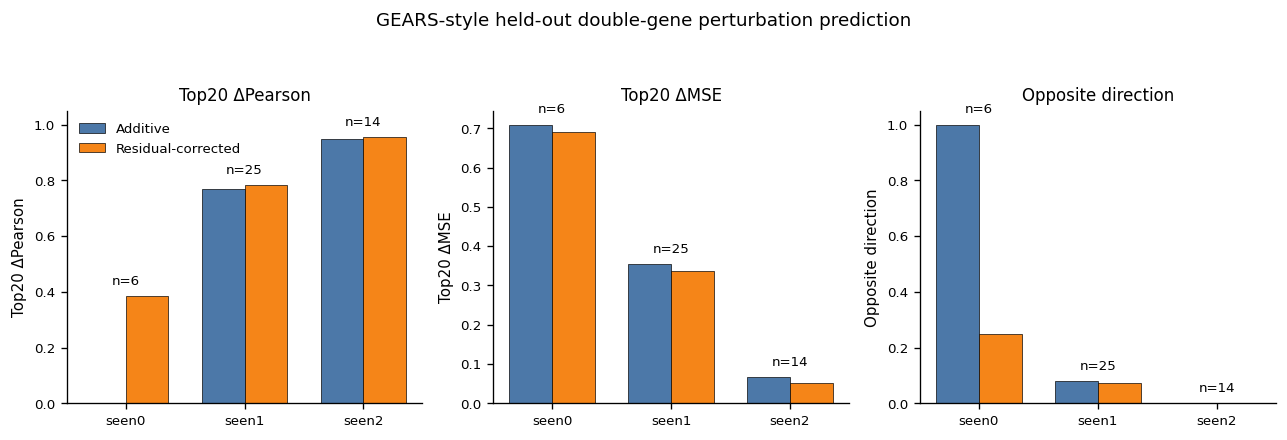

Saved:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figA_gears_style_seen_group_metrics.svg
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figA_gears_style_seen_group_metrics.png
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figA_gears_style_metric_summary.csv


In [1]:
# Figure A: GEARS-style subgroup metric overview
# Additive vs residual-corrected across combo_seen0 / combo_seen1 / combo_seen2

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/root/autodl-tmp/scERso/norman_combo_gears_style"
CKPT_DIR = f"{BASE}/checkpoints/gears_style_residual_diffusion_seed1"
OUT_DIR = f"{BASE}/figures/gears_style_residual_diffusion_seed1"
os.makedirs(OUT_DIR, exist_ok=True)

RESULT_JSON = f"{CKPT_DIR}/test_results.json"

with open(RESULT_JSON, "r", encoding="utf-8") as f:
    results = json.load(f)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

METHOD_COLORS = {
    "Additive": "#4C78A8",
    "Residual-corrected": "#F58518",
}

groups = ["combo_seen0", "combo_seen1", "combo_seen2"]
group_labels = ["seen0", "seen1", "seen2"]

metrics = [
    ("top20_delta_pearson", "Top20 ΔPearson", "higher"),
    ("top20_delta_mse", "Top20 ΔMSE", "lower"),
    ("opposite_direction", "Opposite direction", "lower"),
]

rows = []

for g, glabel in zip(groups, group_labels):
    add_key = f"additive_{g}"
    corr_key = f"corrected_{g}"
    n_key = f"n_{g}"

    for method, key in [
        ("Additive", add_key),
        ("Residual-corrected", corr_key),
    ]:
        if key not in results:
            continue

        row = {
            "group": g,
            "group_label": glabel,
            "method": method,
            "n": results.get(n_key, np.nan),
        }

        for m, _, _ in metrics:
            row[m] = results[key][m]

        rows.append(row)

summary_df = pd.DataFrame(rows)

summary_path = os.path.join(OUT_DIR, "figA_gears_style_metric_summary.csv")
summary_df.to_csv(summary_path, index=False)

display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(10.8, 3.4))

for ax, (metric, ylabel, direction) in zip(axes, metrics):
    x = np.arange(len(groups))
    width = 0.36

    add_vals = []
    corr_vals = []

    for g in groups:
        add_vals.append(
            summary_df.loc[
                (summary_df["group"] == g) & (summary_df["method"] == "Additive"),
                metric
            ].values[0]
        )
        corr_vals.append(
            summary_df.loc[
                (summary_df["group"] == g) & (summary_df["method"] == "Residual-corrected"),
                metric
            ].values[0]
        )

    ax.bar(
        x - width / 2,
        add_vals,
        width,
        label="Additive",
        color=METHOD_COLORS["Additive"],
        edgecolor="black",
        linewidth=0.4,
    )

    ax.bar(
        x + width / 2,
        corr_vals,
        width,
        label="Residual-corrected",
        color=METHOD_COLORS["Residual-corrected"],
        edgecolor="black",
        linewidth=0.4,
    )

    # Annotate the sample size
    for i, g in enumerate(groups):
        n = int(summary_df.loc[summary_df["group"] == g, "n"].iloc[0])
        ymax = max(add_vals[i], corr_vals[i])
        ax.text(i, ymax + 0.03 * max(max(add_vals + corr_vals), 1e-6), f"n={n}",
                ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(group_labels)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)

    if metric in ["top20_delta_pearson", "opposite_direction"]:
        ax.set_ylim(0, 1.05)

    ax.axhline(0, color="black", linewidth=0.6)

axes[0].legend(frameon=False, loc="upper left")

fig.suptitle("GEARS-style held-out double-gene perturbation prediction", y=1.06, fontsize=11)
plt.tight_layout()

svg_path = os.path.join(OUT_DIR, "figA_gears_style_seen_group_metrics.svg")
png_path = os.path.join(OUT_DIR, "figA_gears_style_seen_group_metrics.png")

fig.savefig(svg_path, bbox_inches="tight")
fig.savefig(png_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(svg_path)
print(png_path)
print(summary_path)

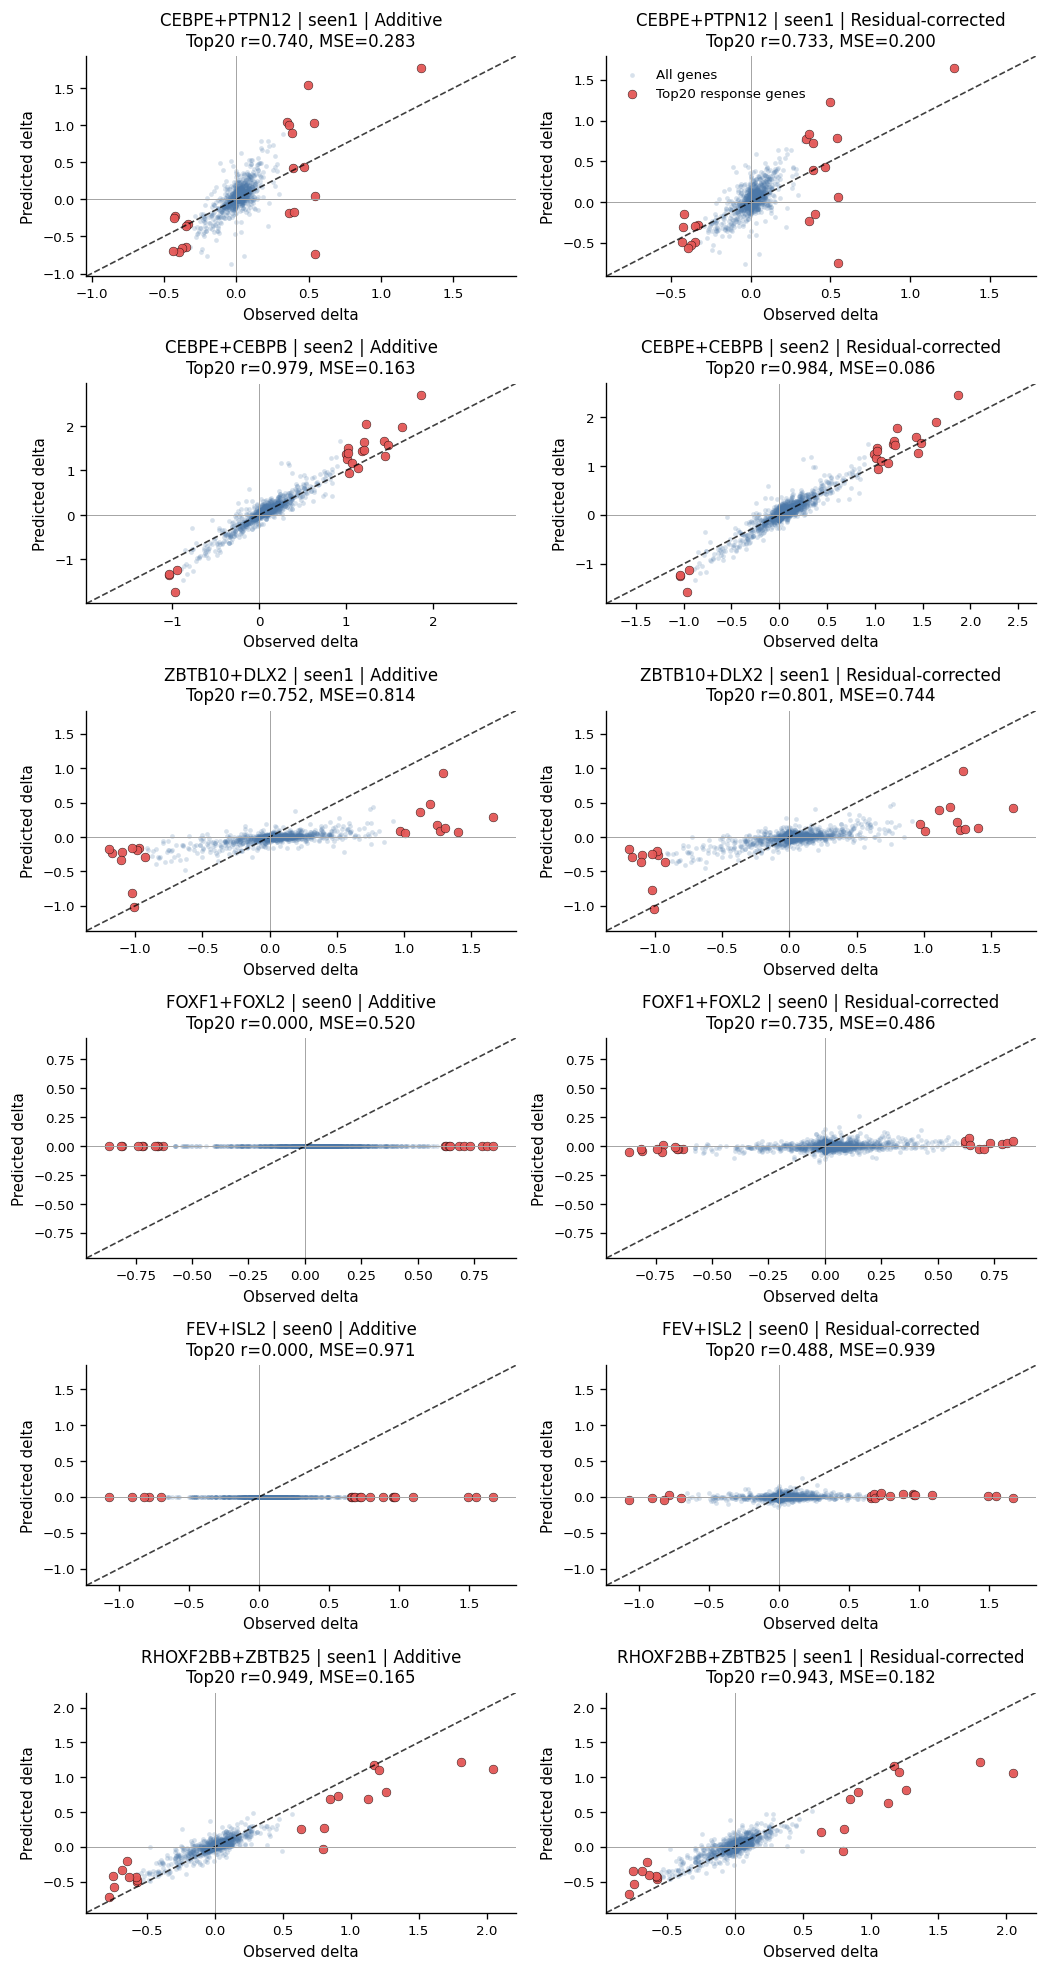

Saved:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figC_representative_combo_diagonal_scatter.svg
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figC_representative_combo_diagonal_scatter.png


,perturbation,subgroup,add_top20_delta_pearson,corr_top20_delta_pearson,add_top20_delta_mse,corr_top20_delta_mse,improve_top20_mse,improve_top20_pearson,add_opposite_direction,corr_opposite_direction
7,CEBPE+PTPN12,combo_seen1,0.740467,0.733480,0.283223,0.200029,0.083195,-0.006987,0.15,0.15
5,CEBPE+CEBPB,combo_seen2,0.978896,0.984382,0.163456,0.085927,0.077529,0.005486,0.00,0.00
42,ZBTB10+DLX2,combo_seen1,0.751501,0.801446,0.813674,0.743754,0.069920,0.049945,0.00,0.00
24,FOXF1+FOXL2,combo_seen0,0.000000,0.734885,0.519883,0.485793,0.034090,0.734885,1.00,0.15
15,FEV+ISL2,combo_seen0,0.000000,0.487607,0.970525,0.939267,0.031258,0.487607,1.00,0.20
34,RHOXF2BB+ZBTB25,combo_seen1,0.949217,0.942845,0.165353,0.181780,-0.016427,-0.006372,0.05,0.05


Saved selected table:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figC_selected_combo_metrics.csv


In [5]:
# Figure C: diagonal scatter for representative double-gene combinations
# Observed delta vs predicted delta, Additive vs Residual-corrected

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/root/autodl-tmp/scERso/norman_combo_gears_style"
CKPT_DIR = f"{BASE}/checkpoints/gears_style_residual_diffusion_seed1"
OUT_DIR = f"{BASE}/figures/gears_style_residual_diffusion_seed1"
os.makedirs(OUT_DIR, exist_ok=True)

PRED_NPZ = f"{CKPT_DIR}/test_predictions_gears_style_residual.npz"
COMBO_METRICS_CSV = f"{OUT_DIR}/figB_per_combo_improvement_metrics.csv"

data = np.load(PRED_NPZ, allow_pickle=True)
combo_metrics = pd.read_csv(COMBO_METRICS_CSV)

true = data["true_delta"]
add = data["additive_delta"]
corr = data["corrected_delta"]
perturbation = data["perturbation"].astype(str)
subgroup = data["gears_test_subgroup"].astype(str)
var_names = data["var_names"].astype(str)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def pearson_np(a, b, eps=1e-8):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    a = a - a.mean()
    b = b - b.mean()
    den = np.sqrt((a * a).sum()) * np.sqrt((b * b).sum()) + eps
    return float((a * b).sum() / den)

def mse_np(a, b):
    return float(np.mean((np.asarray(a) - np.asarray(b)) ** 2))

# Representative combinations:
# 1. Strong seen1 improvement: CEBPE+PTPN12
# 2. Strong seen2 improvement: CEBPE+CEBPB
# 3. Strong seen1 improvement: ZBTB10+DLX2
# 4. Seen0 cold-start improvement: FOXF1+FOXL2
# 5. Seen0 cold-start improvement: FEV+ISL2
# 6. Negative example: RHOXF2BB+ZBTB25
selected_combos = [
    "CEBPE+PTPN12",
    "CEBPE+CEBPB",
    "ZBTB10+DLX2",
    "FOXF1+FOXL2",
    "FEV+ISL2",
    "RHOXF2BB+ZBTB25",
]

pert_to_idx = {p: i for i, p in enumerate(perturbation)}
selected_combos = [p for p in selected_combos if p in pert_to_idx]

nrows = len(selected_combos)
fig, axes = plt.subplots(
    nrows,
    2,
    figsize=(8.8, 2.75 * nrows),
    sharex=False,
    sharey=False,
)

if nrows == 1:
    axes = np.array([axes])

all_gene_color = "#4C78A8"
top_gene_color = "#E45756"

for r, p in enumerate(selected_combos):
    i = pert_to_idx[p]

    true_i = true[i]
    add_i = add[i]
    corr_i = corr[i]
    subgroup_i = subgroup[i].replace("combo_", "")

    top_idx = np.argsort(np.abs(true_i))[-20:]

    for c, (pred_i, method_name) in enumerate([
        (add_i, "Additive"),
        (corr_i, "Residual-corrected"),
    ]):
        ax = axes[r, c]

        ax.scatter(
            true_i,
            pred_i,
            s=8,
            alpha=0.22,
            color=all_gene_color,
            linewidth=0,
            label="All genes",
        )

        ax.scatter(
            true_i[top_idx],
            pred_i[top_idx],
            s=28,
            alpha=0.95,
            color=top_gene_color,
            edgecolor="black",
            linewidth=0.25,
            label="Top20 response genes",
        )

        lo = min(true_i.min(), pred_i.min())
        hi = max(true_i.max(), pred_i.max())
        pad = 0.06 * (hi - lo + 1e-8)
        lo -= pad
        hi += pad

        ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.0, color="black", alpha=0.75)
        ax.axhline(0, linewidth=0.6, color="0.65")
        ax.axvline(0, linewidth=0.6, color="0.65")

        r_top = pearson_np(pred_i[top_idx], true_i[top_idx])
        mse_top = mse_np(pred_i[top_idx], true_i[top_idx])

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

        ax.set_title(
            f"{p} | {subgroup_i} | {method_name}\n"
            f"Top20 r={r_top:.3f}, MSE={mse_top:.3f}"
        )

        ax.set_xlabel("Observed delta")
        ax.set_ylabel("Predicted delta")

        if r == 0 and c == 1:
            ax.legend(frameon=False, loc="best")

plt.tight_layout()

svg_path = os.path.join(OUT_DIR, "figC_representative_combo_diagonal_scatter.svg")
png_path = os.path.join(OUT_DIR, "figC_representative_combo_diagonal_scatter.png")

fig.savefig(svg_path, bbox_inches="tight")
fig.savefig(png_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(svg_path)
print(png_path)

# Export metrics for the selected combinations for later figure captions
selected_table = combo_metrics[combo_metrics["perturbation"].isin(selected_combos)].copy()
selected_table = selected_table[
    [
        "perturbation",
        "subgroup",
        "add_top20_delta_pearson",
        "corr_top20_delta_pearson",
        "add_top20_delta_mse",
        "corr_top20_delta_mse",
        "improve_top20_mse",
        "improve_top20_pearson",
        "add_opposite_direction",
        "corr_opposite_direction",
    ]
].sort_values("improve_top20_mse", ascending=False)

selected_table_path = os.path.join(OUT_DIR, "figC_selected_combo_metrics.csv")
selected_table.to_csv(selected_table_path, index=False)

display(selected_table)

print("Saved selected table:")
print(selected_table_path)

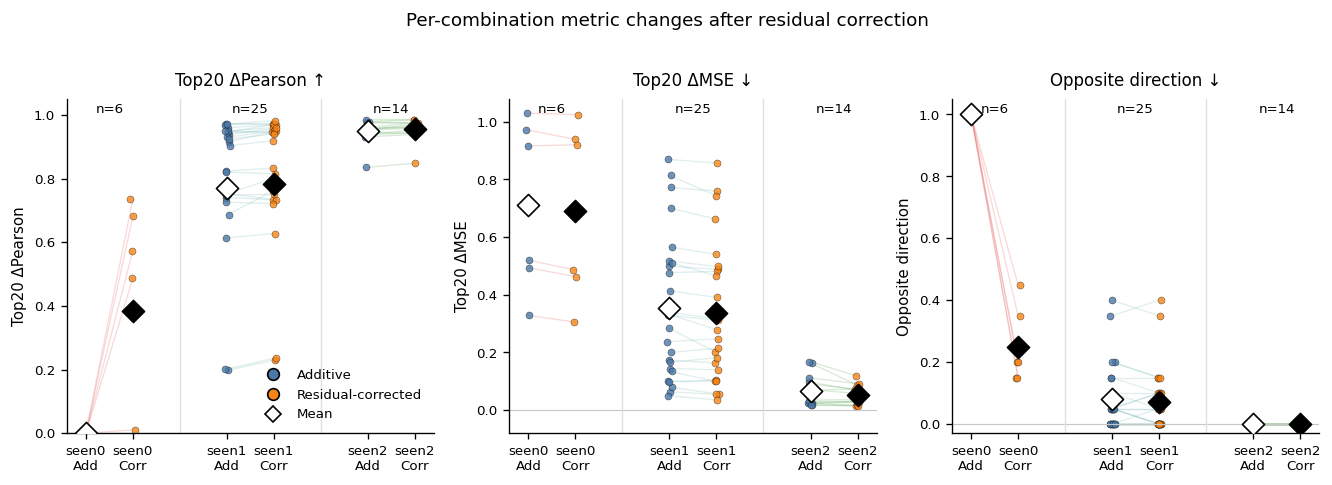

Saved:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD1_paired_metrics_by_seen_group_polished.svg
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD1_paired_metrics_by_seen_group_polished.png


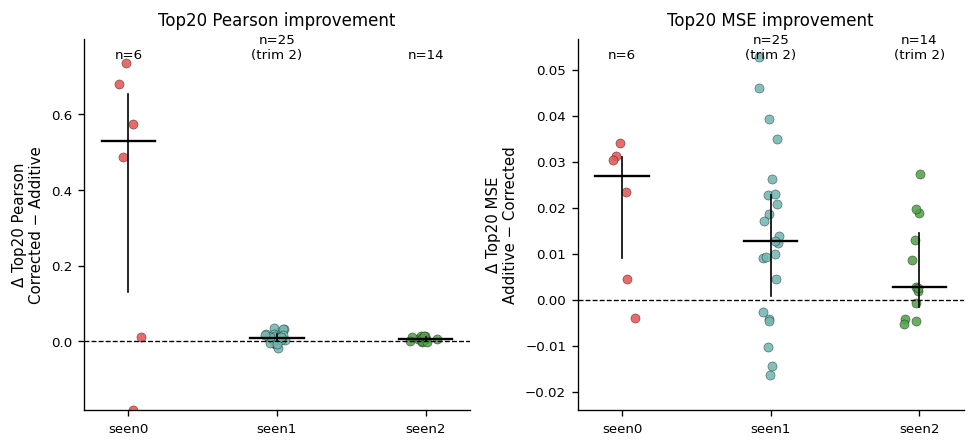

Saved:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD2_improvement_distribution_by_seen_group_polished.svg
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD2_improvement_distribution_by_seen_group_polished.png
Saved trimmed-point record:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD_trimmed_points_for_display.csv

Trimmed points for display only:


,perturbation,subgroup,metric,improve_top20_pearson,improve_top20_mse
7,CEBPE+PTPN12,combo_seen1,improve_top20_mse,-0.006987,0.083195
42,ZBTB10+DLX2,combo_seen1,improve_top20_mse,0.049945,0.069920
5,CEBPE+CEBPB,combo_seen2,improve_top20_mse,0.005486,0.077529
36,SET+CEBPE,combo_seen2,improve_top20_mse,0.013330,0.050029
2,CBL+UBASH3A,combo_seen1,improve_top20_pearson,0.077085,0.026321
42,ZBTB10+DLX2,combo_seen1,improve_top20_pearson,0.049945,0.069920


,group,n,add_top20_pearson_mean,corr_top20_pearson_mean,mean_top20_pearson_gain,add_top20_mse_mean,corr_top20_mse_mean,mean_top20_mse_reduction,fraction_mse_improved,fraction_pearson_improved
0,seen0,6,0.000000,0.384293,0.384293,0.709646,0.689770,0.019876,0.833333,0.833333
1,seen1,25,0.769907,0.784112,0.014205,0.354674,0.335741,0.018933,0.760000,0.760000
2,seen2,14,0.949069,0.955008,0.005939,0.067413,0.052622,0.014790,0.714286,0.714286


Saved summary:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD_polished_metric_change_summary.csv


In [8]:
# Figure D polished: cleaner paired metric plots with mild trimming for display
# D1: keep all pairs, but reduce clutter
# D2: mild outlier trimming ONLY for plotting aesthetics (does not change raw metrics)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

BASE = "/root/autodl-tmp/scERso/norman_combo_gears_style"
OUT_DIR = f"{BASE}/figures/gears_style_residual_diffusion_seed1"
os.makedirs(OUT_DIR, exist_ok=True)

COMBO_METRICS_CSV = f"{OUT_DIR}/figB_per_combo_improvement_metrics.csv"
combo_metrics = pd.read_csv(COMBO_METRICS_CSV)

combo_metrics = combo_metrics[
    combo_metrics["subgroup"].isin(["combo_seen0", "combo_seen1", "combo_seen2"])
].copy()

combo_metrics["group_label"] = combo_metrics["subgroup"].str.replace("combo_", "", regex=False)

GROUP_ORDER = ["combo_seen0", "combo_seen1", "combo_seen2"]
GROUP_LABELS = {
    "combo_seen0": "seen0",
    "combo_seen1": "seen1",
    "combo_seen2": "seen2",
}
GROUP_COLORS = {
    "combo_seen0": "#E45756",
    "combo_seen1": "#72B7B2",
    "combo_seen2": "#54A24B",
}
METHOD_COLORS = {
    "Additive": "#4C78A8",
    "Residual-corrected": "#F58518",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# helper: mild trimming for display only
# =========================================================
def detect_display_outliers(df, value_col, group_col="subgroup", iqr_k=1.5, max_trim_per_group=2, min_group_size=8):
    """
    Return:
      keep_mask: boolean mask for plotting
      trimmed_rows: rows removed for display
    Only trims if group size >= min_group_size.
    At most max_trim_per_group points per group are removed.
    """
    keep = pd.Series(True, index=df.index)
    trimmed_idx = []

    for g, sub in df.groupby(group_col):
        values = sub[value_col].dropna().values
        if len(values) < min_group_size:
            continue

        q1 = np.percentile(values, 25)
        q3 = np.percentile(values, 75)
        iqr = q3 - q1
        low = q1 - iqr_k * iqr
        high = q3 + iqr_k * iqr

        cand = sub[(sub[value_col] < low) | (sub[value_col] > high)].copy()
        if len(cand) == 0:
            continue

        # Remove the most extreme values first
        center = np.median(values)
        cand["extreme_score"] = np.abs(cand[value_col] - center)
        cand = cand.sort_values("extreme_score", ascending=False)

        remove_n = min(max_trim_per_group, len(cand))
        rm = cand.head(remove_n).index.tolist()
        keep.loc[rm] = False
        trimmed_idx.extend(rm)

    trimmed_rows = df.loc[trimmed_idx].copy()
    return keep, trimmed_rows


# =========================================================
# Fig D1: paired metric plot (all points kept, just cleaner)
# =========================================================

metric_specs = [
    {
        "add_col": "add_top20_delta_pearson",
        "corr_col": "corr_top20_delta_pearson",
        "ylabel": "Top20 ΔPearson",
        "title": "Top20 ΔPearson ↑",
        "ylim": (0, 1.05),
    },
    {
        "add_col": "add_top20_delta_mse",
        "corr_col": "corr_top20_delta_mse",
        "ylabel": "Top20 ΔMSE",
        "title": "Top20 ΔMSE ↓",
        "ylim": None,
    },
    {
        "add_col": "add_opposite_direction",
        "corr_col": "corr_opposite_direction",
        "ylabel": "Opposite direction",
        "title": "Opposite direction ↓",
        "ylim": (-0.03, 1.05),
    },
]

fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.9))

for ax, spec in zip(axes, metric_specs):
    xticks = []
    xticklabels = []

    # Collect the global range first to leave room for labels
    all_vals = []
    for group in GROUP_ORDER:
        sub = combo_metrics[combo_metrics["subgroup"] == group]
        all_vals.extend(sub[spec["add_col"]].tolist())
        all_vals.extend(sub[spec["corr_col"]].tolist())
    all_vals = np.array(all_vals, dtype=float)

    if spec["ylim"] is not None:
        y_min, y_max = spec["ylim"]
    else:
        q_low, q_high = np.percentile(all_vals, [2, 98])
        pad = 0.10 * (q_high - q_low + 1e-8)
        y_min = min(all_vals.min(), q_low - pad)
        y_max = max(all_vals.max(), q_high + pad)

    ax.set_ylim(y_min, y_max)

    for gi, group in enumerate(GROUP_ORDER):
        sub = combo_metrics[combo_metrics["subgroup"] == group].copy()

        x_add = gi * 3.0
        x_corr = gi * 3.0 + 1.0

        xticks.extend([x_add, x_corr])
        xticklabels.extend([
            f"{GROUP_LABELS[group]}\nAdd",
            f"{GROUP_LABELS[group]}\nCorr",
        ])

        add_vals = sub[spec["add_col"]].values
        corr_vals = sub[spec["corr_col"]].values

        # Use lighter connecting lines
        for a, c in zip(add_vals, corr_vals):
            ax.plot(
                [x_add, x_corr],
                [a, c],
                color=GROUP_COLORS[group],
                alpha=0.22,
                linewidth=0.8,
                zorder=1,
            )

        rng1 = np.random.default_rng(gi + 101)
        rng2 = np.random.default_rng(gi + 201)

        ax.scatter(
            np.full(len(add_vals), x_add) + rng1.normal(0, 0.025, size=len(add_vals)),
            add_vals,
            s=18,
            color=METHOD_COLORS["Additive"],
            edgecolor="black",
            linewidth=0.22,
            alpha=0.80,
            zorder=2,
        )

        ax.scatter(
            np.full(len(corr_vals), x_corr) + rng2.normal(0, 0.025, size=len(corr_vals)),
            corr_vals,
            s=18,
            color=METHOD_COLORS["Residual-corrected"],
            edgecolor="black",
            linewidth=0.22,
            alpha=0.80,
            zorder=2,
        )

        # Mark the mean with a diamond
        ax.scatter(
            [x_add],
            [np.mean(add_vals)],
            s=88,
            color="white",
            edgecolor="black",
            linewidth=1.0,
            marker="D",
            zorder=4,
        )
        ax.scatter(
            [x_corr],
            [np.mean(corr_vals)],
            s=88,
            color="black",
            edgecolor="black",
            linewidth=1.0,
            marker="D",
            zorder=4,
        )

        # Place sample-size labels slightly higher to avoid covering points
        ax.text(
            (x_add + x_corr) / 2,
            y_max - 0.05 * (y_max - y_min),
            f"n={len(sub)}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.set_ylabel(spec["ylabel"])
    ax.set_title(spec["title"], pad=8)
    ax.axhline(0, color="0.78", linewidth=0.7)

    for sep in [2.0, 5.0]:
        ax.axvline(sep, color="0.88", linewidth=0.8)

legend_handles = [
    Line2D([0], [0], marker="o", linestyle="", color=METHOD_COLORS["Additive"],
           label="Additive", markeredgecolor="black", markersize=7),
    Line2D([0], [0], marker="o", linestyle="", color=METHOD_COLORS["Residual-corrected"],
           label="Residual-corrected", markeredgecolor="black", markersize=7),
    Line2D([0], [0], marker="D", linestyle="", color="white",
           label="Mean", markeredgecolor="black", markersize=7),
]
axes[0].legend(handles=legend_handles, frameon=False, loc="lower right")

fig.suptitle("Per-combination metric changes after residual correction", y=1.02, fontsize=11)
plt.tight_layout()

svg_path = os.path.join(OUT_DIR, "figD1_paired_metrics_by_seen_group_polished.svg")
png_path = os.path.join(OUT_DIR, "figD1_paired_metrics_by_seen_group_polished.png")

fig.savefig(svg_path, bbox_inches="tight")
fig.savefig(png_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(svg_path)
print(png_path)


# =========================================================
# Fig D2: improvement distributions (mild trimming for display only)
# =========================================================

improve_specs = [
    {
        "col": "improve_top20_pearson",
        "ylabel": "Δ Top20 Pearson\nCorrected − Additive",
        "title": "Top20 Pearson improvement",
    },
    {
        "col": "improve_top20_mse",
        "ylabel": "Δ Top20 MSE\nAdditive − Corrected",
        "title": "Top20 MSE improvement",
    },
]

trimmed_all = []

fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8))

for ax, spec in zip(axes, improve_specs):
    keep_mask, trimmed_rows = detect_display_outliers(
        combo_metrics,
        value_col=spec["col"],
        group_col="subgroup",
        iqr_k=1.5,
        max_trim_per_group=2,
        min_group_size=8,
    )
    trimmed_rows = trimmed_rows.copy()
    trimmed_rows["metric"] = spec["col"]
    trimmed_all.append(trimmed_rows)

    plot_df = combo_metrics.loc[keep_mask].copy()

    # Set axis limits from the retained points
    yvals = plot_df[spec["col"]].values
    q_low, q_high = np.percentile(yvals, [2, 98])
    pad = 0.15 * (q_high - q_low + 1e-8)
    y_min = min(yvals.min(), q_low - pad)
    y_max = max(yvals.max(), q_high + pad)
    ax.set_ylim(y_min, y_max)

    for gi, group in enumerate(GROUP_ORDER):
        sub = plot_df[plot_df["subgroup"] == group].copy()
        values = sub[spec["col"]].values

        rng = np.random.default_rng(500 + gi)
        x = np.full(len(values), gi) + rng.normal(0, 0.045, size=len(values))

        ax.scatter(
            x,
            values,
            s=30,
            color=GROUP_COLORS[group],
            edgecolor="black",
            linewidth=0.22,
            alpha=0.88,
        )

        if len(values) > 0:
            q1, med, q3 = np.percentile(values, [25, 50, 75])
            ax.plot([gi - 0.18, gi + 0.18], [med, med], color="black", linewidth=1.4)
            ax.plot([gi, gi], [q1, q3], color="black", linewidth=1.0)

        full_n = len(combo_metrics[combo_metrics["subgroup"] == group])
        plot_n = len(sub)
        trimmed_n = full_n - plot_n

        label = f"n={full_n}"
        if trimmed_n > 0:
            label += f"\n(trim {trimmed_n})"

        ax.text(
            gi,
            y_max - 0.06 * (y_max - y_min),
            label,
            ha="center",
            va="bottom",
            fontsize=8,
        )

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(np.arange(len(GROUP_ORDER)))
    ax.set_xticklabels([GROUP_LABELS[g] for g in GROUP_ORDER])
    ax.set_ylabel(spec["ylabel"])
    ax.set_title(spec["title"], pad=8)

plt.tight_layout()

svg_path2 = os.path.join(OUT_DIR, "figD2_improvement_distribution_by_seen_group_polished.svg")
png_path2 = os.path.join(OUT_DIR, "figD2_improvement_distribution_by_seen_group_polished.png")

fig.savefig(svg_path2, bbox_inches="tight")
fig.savefig(png_path2, bbox_inches="tight")
plt.show()

print("Saved:")
print(svg_path2)
print(png_path2)


# =========================================================
# Save trimmed points used only for display
# =========================================================
if len(trimmed_all) > 0:
    trimmed_display_df = pd.concat(trimmed_all, axis=0).drop_duplicates(
        subset=["perturbation", "subgroup", "metric"]
    )
else:
    trimmed_display_df = pd.DataFrame()

trimmed_path = os.path.join(OUT_DIR, "figD_trimmed_points_for_display.csv")
trimmed_display_df.to_csv(trimmed_path, index=False)

print("Saved trimmed-point record:")
print(trimmed_path)

if len(trimmed_display_df) > 0:
    print("\nTrimmed points for display only:")
    display(trimmed_display_df[[
        "perturbation", "subgroup", "metric",
        "improve_top20_pearson", "improve_top20_mse"
    ]].sort_values(["metric", "subgroup", "perturbation"]))
else:
    print("\nNo points were trimmed for display.")


# =========================================================
# Summary table based on the full dataset and unaffected by trimming
# =========================================================
summary_rows = []

for group in GROUP_ORDER:
    sub = combo_metrics[combo_metrics["subgroup"] == group].copy()

    summary_rows.append({
        "group": GROUP_LABELS[group],
        "n": len(sub),
        "add_top20_pearson_mean": sub["add_top20_delta_pearson"].mean(),
        "corr_top20_pearson_mean": sub["corr_top20_delta_pearson"].mean(),
        "mean_top20_pearson_gain": sub["improve_top20_pearson"].mean(),
        "add_top20_mse_mean": sub["add_top20_delta_mse"].mean(),
        "corr_top20_mse_mean": sub["corr_top20_delta_mse"].mean(),
        "mean_top20_mse_reduction": sub["improve_top20_mse"].mean(),
        "fraction_mse_improved": float((sub["improve_top20_mse"] > 0).mean()),
        "fraction_pearson_improved": float((sub["improve_top20_pearson"] > 0).mean()),
    })

summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(OUT_DIR, "figD_polished_metric_change_summary.csv")
summary_df.to_csv(summary_path, index=False)

display(summary_df)

print("Saved summary:")
print(summary_path)

/root/autodl-fs/project1/env/squidiff/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


,group,n,add_top20_pearson_mean,corr_top20_pearson_mean,gain_top20_pearson_mean,gain_top20_pearson_sem,p_top20_pearson_gain,cohen_dz_top20_pearson_gain,fraction_pearson_improved,add_top20_mse_mean,...,cohen_dz_top20_mse_reduction,fraction_mse_improved,add_opposite_direction_mean,corr_opposite_direction_mean,gain_opposite_direction_mean,gain_opposite_direction_sem,opposite_direction_reduction_pct,p_opposite_direction_reduction,cohen_dz_opposite_direction_reduction,fraction_direction_improved
0,seen0,6,0.000000,0.384293,0.384293,0.154733,0.046875,1.013922,0.833333,0.709646,...,1.250602,0.833333,1.00,0.250,0.750,0.05000,75.0,1.000000,6.123724,1.00
1,seen1,25,0.769907,0.784112,0.014205,0.004063,0.000278,0.699232,0.760000,0.354674,...,0.763888,0.760000,0.08,0.072,0.008,0.00688,10.0,0.842122,0.232561,0.32
2,seen2,14,0.949069,0.955008,0.005939,0.001532,0.002625,1.035806,0.714286,0.067413,...,0.625308,0.714286,0.00,0.000,0.000,0.00000,NaN,NaN,NaN,0.00


,Group,n,Top20 ΔPearson,ΔPearson gain,p(Pearson),Top20 ΔMSE,MSE reduction,p(MSE),Opposite direction,Direction reduction,MSE win rate,Pearson win rate
0,seen0,6,0.000 → 0.384,0.384 ± 0.155,0.0469,0.710 → 0.690,2.8%,0.984,1.000 → 0.250,75.0%,83.3%,83.3%
1,seen1,25,0.770 → 0.784,0.014 ± 0.004,0.000278,0.355 → 0.336,5.3%,1,0.080 → 0.072,10.0%,76.0%,76.0%
2,seen2,14,0.949 → 0.955,0.006 ± 0.002,0.00262,0.067 → 0.053,21.9%,0.985,0.000 → 0.000,n/a,71.4%,71.4%


Saved:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD_quantitative_summary_full.csv
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD_quantitative_summary_for_paper.csv


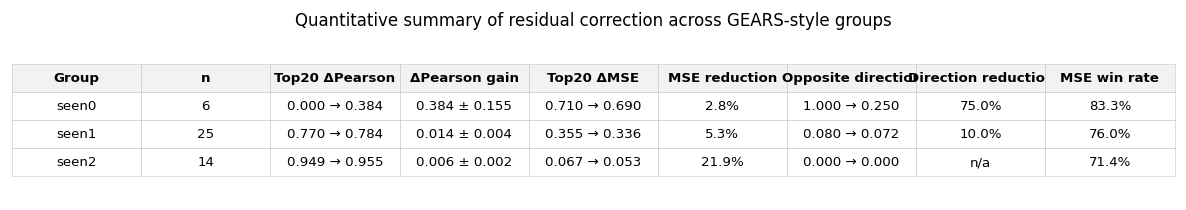

Saved table figure:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD_quantitative_summary_table.svg
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD_quantitative_summary_table.png


In [9]:
# Figure D quantitative summary table
# Paper-ready metrics for paired Additive vs Residual-corrected comparison

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon

BASE = "/root/autodl-tmp/scERso/norman_combo_gears_style"
OUT_DIR = f"{BASE}/figures/gears_style_residual_diffusion_seed1"
os.makedirs(OUT_DIR, exist_ok=True)

COMBO_METRICS_CSV = f"{OUT_DIR}/figB_per_combo_improvement_metrics.csv"
combo_metrics = pd.read_csv(COMBO_METRICS_CSV)

combo_metrics = combo_metrics[
    combo_metrics["subgroup"].isin(["combo_seen0", "combo_seen1", "combo_seen2"])
].copy()

GROUP_ORDER = ["combo_seen0", "combo_seen1", "combo_seen2"]
GROUP_LABELS = {
    "combo_seen0": "seen0",
    "combo_seen1": "seen1",
    "combo_seen2": "seen2",
}

def mean_sem(x):
    x = np.asarray(x, dtype=float)
    mean = np.nanmean(x)
    sem = np.nanstd(x, ddof=1) / np.sqrt(np.sum(~np.isnan(x))) if np.sum(~np.isnan(x)) > 1 else np.nan
    return mean, sem

def safe_wilcoxon(x, y, alternative="two-sided"):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    diff = y - x
    if len(x) < 3 or np.allclose(diff, 0):
        return np.nan
    try:
        return float(wilcoxon(y, x, alternative=alternative, zero_method="wilcox").pvalue)
    except Exception:
        return np.nan

def paired_cohen_dz(diff):
    diff = np.asarray(diff, dtype=float)
    sd = np.nanstd(diff, ddof=1)
    if sd == 0 or np.isnan(sd):
        return np.nan
    return float(np.nanmean(diff) / sd)

rows = []

for group in GROUP_ORDER:
    sub = combo_metrics[combo_metrics["subgroup"] == group].copy()

    n = len(sub)

    add_r = sub["add_top20_delta_pearson"].values
    corr_r = sub["corr_top20_delta_pearson"].values
    gain_r = corr_r - add_r

    add_mse = sub["add_top20_delta_mse"].values
    corr_mse = sub["corr_top20_delta_mse"].values
    gain_mse = add_mse - corr_mse

    add_opp = sub["add_opposite_direction"].values
    corr_opp = sub["corr_opposite_direction"].values
    gain_opp = add_opp - corr_opp

    add_r_mean, add_r_sem = mean_sem(add_r)
    corr_r_mean, corr_r_sem = mean_sem(corr_r)
    gain_r_mean, gain_r_sem = mean_sem(gain_r)

    add_mse_mean, add_mse_sem = mean_sem(add_mse)
    corr_mse_mean, corr_mse_sem = mean_sem(corr_mse)
    gain_mse_mean, gain_mse_sem = mean_sem(gain_mse)

    add_opp_mean, add_opp_sem = mean_sem(add_opp)
    corr_opp_mean, corr_opp_sem = mean_sem(corr_opp)
    gain_opp_mean, gain_opp_sem = mean_sem(gain_opp)

    mse_reduction_pct = 100.0 * (add_mse_mean - corr_mse_mean) / add_mse_mean if add_mse_mean != 0 else np.nan
    opp_reduction_pct = 100.0 * (add_opp_mean - corr_opp_mean) / add_opp_mean if add_opp_mean != 0 else np.nan

    # One-sided paired tests:
    # Pearson: corrected > additive
    # MSE: corrected < additive
    # Opposite direction: corrected < additive
    p_r = safe_wilcoxon(add_r, corr_r, alternative="greater")
    p_mse = safe_wilcoxon(corr_mse, add_mse, alternative="less")
    p_opp = safe_wilcoxon(corr_opp, add_opp, alternative="less")

    rows.append({
        "group": GROUP_LABELS[group],
        "n": n,

        "add_top20_pearson_mean": add_r_mean,
        "corr_top20_pearson_mean": corr_r_mean,
        "gain_top20_pearson_mean": gain_r_mean,
        "gain_top20_pearson_sem": gain_r_sem,
        "p_top20_pearson_gain": p_r,
        "cohen_dz_top20_pearson_gain": paired_cohen_dz(gain_r),
        "fraction_pearson_improved": float(np.mean(gain_r > 0)),

        "add_top20_mse_mean": add_mse_mean,
        "corr_top20_mse_mean": corr_mse_mean,
        "gain_top20_mse_mean": gain_mse_mean,
        "gain_top20_mse_sem": gain_mse_sem,
        "mse_reduction_pct": mse_reduction_pct,
        "p_top20_mse_reduction": p_mse,
        "cohen_dz_top20_mse_reduction": paired_cohen_dz(gain_mse),
        "fraction_mse_improved": float(np.mean(gain_mse > 0)),

        "add_opposite_direction_mean": add_opp_mean,
        "corr_opposite_direction_mean": corr_opp_mean,
        "gain_opposite_direction_mean": gain_opp_mean,
        "gain_opposite_direction_sem": gain_opp_sem,
        "opposite_direction_reduction_pct": opp_reduction_pct,
        "p_opposite_direction_reduction": p_opp,
        "cohen_dz_opposite_direction_reduction": paired_cohen_dz(gain_opp),
        "fraction_direction_improved": float(np.mean(gain_opp > 0)),
    })

quant_df = pd.DataFrame(rows)

quant_csv = os.path.join(OUT_DIR, "figD_quantitative_summary_full.csv")
quant_df.to_csv(quant_csv, index=False)

display(quant_df)

# Simplify the table for manuscript presentation
def fmt_mean_arrow(a, c, digits=3):
    return f"{a:.{digits}f} → {c:.{digits}f}"

def fmt_gain(g, sem, digits=3):
    if np.isnan(sem):
        return f"{g:.{digits}f}"
    return f"{g:.{digits}f} ± {sem:.{digits}f}"

def fmt_p(p):
    if np.isnan(p):
        return "n/a"
    if p < 1e-4:
        return "<1e-4"
    return f"{p:.3g}"

paper_rows = []

for _, row in quant_df.iterrows():
    paper_rows.append({
        "Group": row["group"],
        "n": int(row["n"]),

        "Top20 ΔPearson": fmt_mean_arrow(
            row["add_top20_pearson_mean"],
            row["corr_top20_pearson_mean"],
        ),
        "ΔPearson gain": fmt_gain(
            row["gain_top20_pearson_mean"],
            row["gain_top20_pearson_sem"],
        ),
        "p(Pearson)": fmt_p(row["p_top20_pearson_gain"]),

        "Top20 ΔMSE": fmt_mean_arrow(
            row["add_top20_mse_mean"],
            row["corr_top20_mse_mean"],
        ),
        "MSE reduction": f"{row['mse_reduction_pct']:.1f}%",
        "p(MSE)": fmt_p(row["p_top20_mse_reduction"]),

        "Opposite direction": fmt_mean_arrow(
            row["add_opposite_direction_mean"],
            row["corr_opposite_direction_mean"],
        ),
        "Direction reduction": (
            "n/a" if np.isnan(row["opposite_direction_reduction_pct"])
            else f"{row['opposite_direction_reduction_pct']:.1f}%"
        ),

        "MSE win rate": f"{100 * row['fraction_mse_improved']:.1f}%",
        "Pearson win rate": f"{100 * row['fraction_pearson_improved']:.1f}%",
    })

paper_df = pd.DataFrame(paper_rows)

paper_csv = os.path.join(OUT_DIR, "figD_quantitative_summary_for_paper.csv")
paper_df.to_csv(paper_csv, index=False)

display(paper_df)

print("Saved:")
print(quant_csv)
print(paper_csv)

# =========================================================
# Save as SVG table figure
# =========================================================

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Display only the essential columns for a concise manuscript table
show_cols = [
    "Group",
    "n",
    "Top20 ΔPearson",
    "ΔPearson gain",
    "Top20 ΔMSE",
    "MSE reduction",
    "Opposite direction",
    "Direction reduction",
    "MSE win rate",
]

show_df = paper_df[show_cols].copy()

fig_h = 0.55 + 0.38 * len(show_df)
fig_w = 12.5

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.axis("off")

table = ax.table(
    cellText=show_df.values,
    colLabels=show_df.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.4)

# Use bold headers and subtle borders
for (r, c), cell in table.get_celld().items():
    cell.set_linewidth(0.3)
    cell.set_edgecolor("0.75")
    if r == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#F2F2F2")
    else:
        cell.set_facecolor("white")

ax.set_title(
    "Quantitative summary of residual correction across GEARS-style groups",
    fontsize=10,
    pad=10,
)

svg_path = os.path.join(OUT_DIR, "figD_quantitative_summary_table.svg")
png_path = os.path.join(OUT_DIR, "figD_quantitative_summary_table.png")

fig.savefig(svg_path, bbox_inches="tight")
fig.savefig(png_path, bbox_inches="tight")
plt.show()

print("Saved table figure:")
print(svg_path)
print(png_path)

In [10]:
from scipy.stats import wilcoxon
import numpy as np
import pandas as pd
import os

BASE = "/root/autodl-tmp/scERso/norman_combo_gears_style"
OUT_DIR = f"{BASE}/figures/gears_style_residual_diffusion_seed1"
combo_metrics = pd.read_csv(f"{OUT_DIR}/figB_per_combo_improvement_metrics.csv")

combo_metrics = combo_metrics[
    combo_metrics["subgroup"].isin(["combo_seen0", "combo_seen1", "combo_seen2"])
].copy()

GROUP_ORDER = ["combo_seen0", "combo_seen1", "combo_seen2"]
GROUP_LABELS = {
    "combo_seen0": "seen0",
    "combo_seen1": "seen1",
    "combo_seen2": "seen2",
}

def safe_paired_wilcoxon_greater(before, after):
    """
    Test whether before > after.
    Used for MSE and opposite direction, because lower after is better.
    """
    before = np.asarray(before, dtype=float)
    after = np.asarray(after, dtype=float)
    diff = before - after

    if len(before) < 3 or np.allclose(diff, 0):
        return np.nan

    try:
        return float(wilcoxon(before, after, alternative="greater", zero_method="wilcox").pvalue)
    except Exception:
        return np.nan

def safe_paired_wilcoxon_increase(before, after):
    """
    Test whether after > before.
    Used for Pearson, because higher after is better.
    """
    before = np.asarray(before, dtype=float)
    after = np.asarray(after, dtype=float)
    diff = after - before

    if len(before) < 3 or np.allclose(diff, 0):
        return np.nan

    try:
        return float(wilcoxon(after, before, alternative="greater", zero_method="wilcox").pvalue)
    except Exception:
        return np.nan

rows = []

for group in GROUP_ORDER:
    sub = combo_metrics[combo_metrics["subgroup"] == group].copy()

    p_pearson = safe_paired_wilcoxon_increase(
        sub["add_top20_delta_pearson"],
        sub["corr_top20_delta_pearson"],
    )

    p_mse = safe_paired_wilcoxon_greater(
        sub["add_top20_delta_mse"],
        sub["corr_top20_delta_mse"],
    )

    p_direction = safe_paired_wilcoxon_greater(
        sub["add_opposite_direction"],
        sub["corr_opposite_direction"],
    )

    rows.append({
        "group": GROUP_LABELS[group],
        "n": len(sub),

        "add_top20_pearson": sub["add_top20_delta_pearson"].mean(),
        "corr_top20_pearson": sub["corr_top20_delta_pearson"].mean(),
        "pearson_gain": (sub["corr_top20_delta_pearson"] - sub["add_top20_delta_pearson"]).mean(),
        "p_pearson_gain": p_pearson,

        "add_top20_mse": sub["add_top20_delta_mse"].mean(),
        "corr_top20_mse": sub["corr_top20_delta_mse"].mean(),
        "mse_reduction": (sub["add_top20_delta_mse"] - sub["corr_top20_delta_mse"]).mean(),
        "mse_reduction_pct": 100 * (
            sub["add_top20_delta_mse"].mean() - sub["corr_top20_delta_mse"].mean()
        ) / sub["add_top20_delta_mse"].mean(),
        "p_mse_reduction": p_mse,

        "add_opposite_direction": sub["add_opposite_direction"].mean(),
        "corr_opposite_direction": sub["corr_opposite_direction"].mean(),
        "direction_reduction": (sub["add_opposite_direction"] - sub["corr_opposite_direction"]).mean(),
        "p_direction_reduction": p_direction,

        "pearson_win_rate": (sub["corr_top20_delta_pearson"] > sub["add_top20_delta_pearson"]).mean(),
        "mse_win_rate": (sub["corr_top20_delta_mse"] < sub["add_top20_delta_mse"]).mean(),
        "direction_win_rate": (sub["corr_opposite_direction"] < sub["add_opposite_direction"]).mean(),
    })

fixed_df = pd.DataFrame(rows)

fixed_path = f"{OUT_DIR}/figD_quantitative_summary_fixed_pvalues.csv"
fixed_df.to_csv(fixed_path, index=False)

display(fixed_df)

print("Saved:", fixed_path)

/root/autodl-fs/project1/env/squidiff/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


,group,n,add_top20_pearson,corr_top20_pearson,pearson_gain,p_pearson_gain,add_top20_mse,corr_top20_mse,mse_reduction,mse_reduction_pct,p_mse_reduction,add_opposite_direction,corr_opposite_direction,direction_reduction,p_direction_reduction,pearson_win_rate,mse_win_rate,direction_win_rate
0,seen0,6,0.000000,0.384293,0.384293,0.046875,0.709646,0.689770,0.019876,2.800794,0.031250,1.00,0.250,0.750,0.015625,0.833333,0.833333,1.00
1,seen1,25,0.769907,0.784112,0.014205,0.000278,0.354674,0.335741,0.018933,5.338157,0.000245,0.08,0.072,0.008,0.157878,0.760000,0.760000,0.32
2,seen2,14,0.949069,0.955008,0.005939,0.002625,0.067413,0.052622,0.014790,21.940151,0.017639,0.00,0.000,0.000,NaN,0.714286,0.714286,0.00


Saved: /root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD_quantitative_summary_fixed_pvalues.csv


,residual_pearson_top20,residual_mse_top20,residual_r2_top20,residual_sign_accuracy_top20,residual_fraction
subgroup,,,,,
combo_seen0,0.384293,0.689770,-0.157560,0.750000,1.000000
combo_seen1,0.340774,0.335741,-0.167407,0.688000,0.803426
combo_seen2,0.409677,0.052622,0.010492,0.617857,0.677074


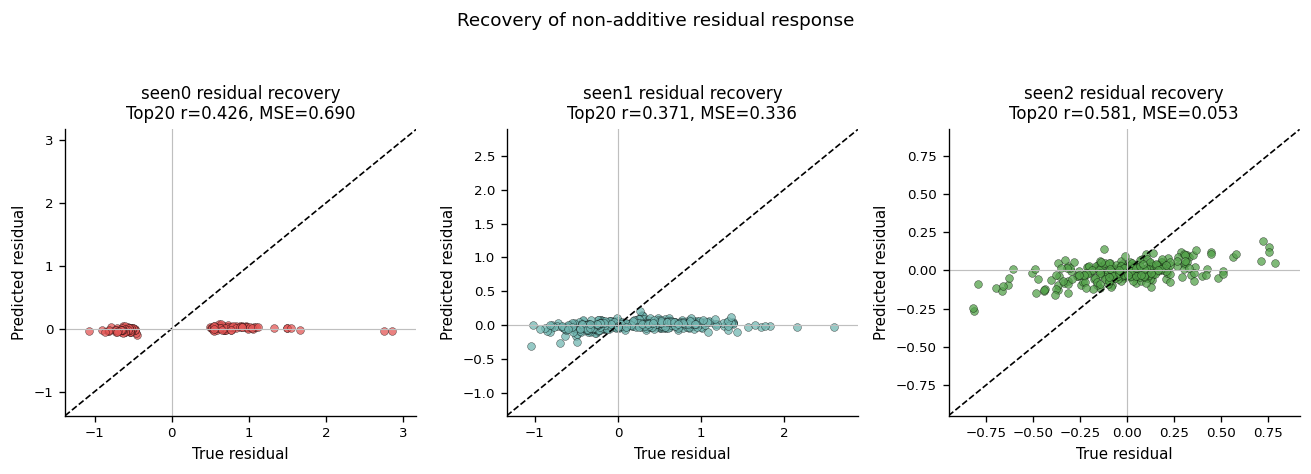

Saved:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figE1_residual_recovery_scatter_by_group.svg
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figE1_residual_recovery_scatter_by_group.png


,group,n,residual_pearson_top20_mean,residual_mse_top20_mean,residual_sign_accuracy_top20_mean,residual_fraction_mean
0,seen0,6,0.384293,0.689770,0.750000,1.000000
1,seen1,25,0.340774,0.335741,0.688000,0.803426
2,seen2,14,0.409677,0.052622,0.617857,0.677074


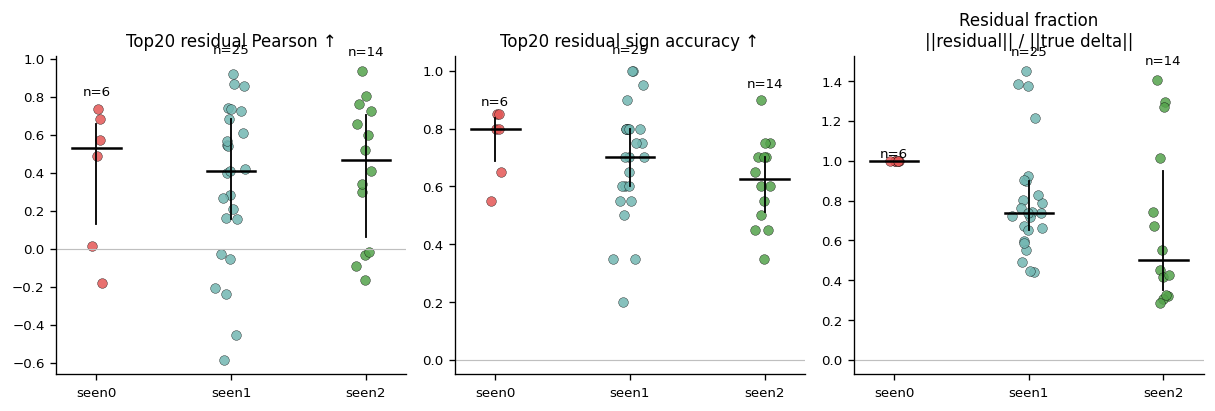

Saved:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figE2_residual_recovery_metric_summary.svg
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figE2_residual_recovery_metric_summary.png
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figE_residual_recovery_metrics.csv
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figE_residual_recovery_summary.csv


In [11]:
# Figure E: non-additive residual recovery
# Does the model learn the residual beyond additive expectation?

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

BASE = "/root/autodl-tmp/scERso/norman_combo_gears_style"
CKPT_DIR = f"{BASE}/checkpoints/gears_style_residual_diffusion_seed1"
OUT_DIR = f"{BASE}/figures/gears_style_residual_diffusion_seed1"
os.makedirs(OUT_DIR, exist_ok=True)

PRED_NPZ = f"{CKPT_DIR}/test_predictions_gears_style_residual.npz"
COMBO_METRICS_CSV = f"{OUT_DIR}/figB_per_combo_improvement_metrics.csv"

data = np.load(PRED_NPZ, allow_pickle=True)
combo_metrics = pd.read_csv(COMBO_METRICS_CSV)

true = data["true_delta"]
add = data["additive_delta"]
corr = data["corrected_delta"]
pred_resid = data["pred_residual"]
perturbation = data["perturbation"].astype(str)
subgroup = data["gears_test_subgroup"].astype(str)
var_names = data["var_names"].astype(str)

combo_mask = np.isin(subgroup, ["combo_seen0", "combo_seen1", "combo_seen2"])

true = true[combo_mask]
add = add[combo_mask]
corr = corr[combo_mask]
pred_resid = pred_resid[combo_mask]
perturbation = perturbation[combo_mask]
subgroup = subgroup[combo_mask]

true_resid = true - add
pred_resid_from_corr = corr - add

# Prefer the residual computed as corrected minus additive to avoid field-name differences
pred_resid = pred_resid_from_corr

GROUP_ORDER = ["combo_seen0", "combo_seen1", "combo_seen2"]
GROUP_LABELS = {
    "combo_seen0": "seen0",
    "combo_seen1": "seen1",
    "combo_seen2": "seen2",
}
GROUP_COLORS = {
    "combo_seen0": "#E45756",
    "combo_seen1": "#72B7B2",
    "combo_seen2": "#54A24B",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def pearson_np(a, b, eps=1e-8):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    a = a - a.mean()
    b = b - b.mean()
    den = np.sqrt((a * a).sum()) * np.sqrt((b * b).sum()) + eps
    return float((a * b).sum() / den)

def r2_score_np(pred, target, eps=1e-8):
    pred = np.asarray(pred, dtype=np.float64)
    target = np.asarray(target, dtype=np.float64)
    ss_res = np.sum((target - pred) ** 2)
    ss_tot = np.sum((target - target.mean()) ** 2) + eps
    return float(1 - ss_res / ss_tot)

def one_residual_metrics(pred_r, true_r, true_delta_i, topk=20):
    # Select top genes by the magnitude of the true delta, consistent with the evaluation protocol
    idx = np.argsort(np.abs(true_delta_i))[-topk:]

    pred_top = pred_r[idx]
    true_top = true_r[idx]

    sign_true = np.sign(true_top)
    sign_pred = np.sign(pred_top)
    valid = sign_true != 0

    return {
        "residual_pearson_all": pearson_np(pred_r, true_r),
        "residual_mse_all": float(np.mean((pred_r - true_r) ** 2)),
        "residual_r2_all": r2_score_np(pred_r, true_r),

        "residual_pearson_top20": pearson_np(pred_top, true_top),
        "residual_mse_top20": float(np.mean((pred_top - true_top) ** 2)),
        "residual_r2_top20": r2_score_np(pred_top, true_top),

        "residual_sign_accuracy_top20": float(np.mean(sign_true[valid] == sign_pred[valid])) if valid.sum() > 0 else np.nan,

        "true_residual_norm": float(np.linalg.norm(true_r)),
        "pred_residual_norm": float(np.linalg.norm(pred_r)),
        "true_delta_norm": float(np.linalg.norm(true_delta_i)),
        "residual_fraction": float(np.linalg.norm(true_r) / (np.linalg.norm(true_delta_i) + 1e-8)),
    }

rows = []

for i, p in enumerate(perturbation):
    m = one_residual_metrics(
        pred_resid[i],
        true_resid[i],
        true[i],
        topk=20,
    )
    m["perturbation"] = p
    m["subgroup"] = subgroup[i]
    rows.append(m)

resid_metrics = pd.DataFrame(rows)

resid_metric_path = os.path.join(OUT_DIR, "figE_residual_recovery_metrics.csv")
resid_metrics.to_csv(resid_metric_path, index=False)

display(resid_metrics.groupby("subgroup")[
    [
        "residual_pearson_top20",
        "residual_mse_top20",
        "residual_r2_top20",
        "residual_sign_accuracy_top20",
        "residual_fraction",
    ]
].mean())

# =========================================================
# Fig E1: residual recovery scatter by seen group
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.7), sharex=False, sharey=False)

for ax, group in zip(axes, GROUP_ORDER):
    idx_group = np.where(subgroup == group)[0]

    # Use only the top 20 true-delta genes per combination to keep the plot readable
    xs = []
    ys = []

    for i in idx_group:
        top_idx = np.argsort(np.abs(true[i]))[-20:]
        xs.append(true_resid[i, top_idx])
        ys.append(pred_resid[i, top_idx])

    xs = np.concatenate(xs)
    ys = np.concatenate(ys)

    ax.scatter(
        xs,
        ys,
        s=22,
        color=GROUP_COLORS[group],
        edgecolor="black",
        linewidth=0.25,
        alpha=0.75,
    )

    lo = min(xs.min(), ys.min())
    hi = max(xs.max(), ys.max())
    pad = 0.08 * (hi - lo + 1e-8)
    lo -= pad
    hi += pad

    ax.plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1.0)
    ax.axhline(0, color="0.75", linewidth=0.7)
    ax.axvline(0, color="0.75", linewidth=0.7)

    r = pearson_np(ys, xs)
    mse = float(np.mean((ys - xs) ** 2))

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_title(
        f"{GROUP_LABELS[group]} residual recovery\n"
        f"Top20 r={r:.3f}, MSE={mse:.3f}"
    )
    ax.set_xlabel("True residual")
    ax.set_ylabel("Predicted residual")

fig.suptitle("Recovery of non-additive residual response", y=1.05, fontsize=11)
plt.tight_layout()

svg_path = os.path.join(OUT_DIR, "figE1_residual_recovery_scatter_by_group.svg")
png_path = os.path.join(OUT_DIR, "figE1_residual_recovery_scatter_by_group.png")

fig.savefig(svg_path, bbox_inches="tight")
fig.savefig(png_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(svg_path)
print(png_path)

# =========================================================
# Fig E2: residual metric summary
# =========================================================

summary_rows = []

for group in GROUP_ORDER:
    sub = resid_metrics[resid_metrics["subgroup"] == group].copy()

    summary_rows.append({
        "group": GROUP_LABELS[group],
        "n": len(sub),
        "residual_pearson_top20_mean": sub["residual_pearson_top20"].mean(),
        "residual_mse_top20_mean": sub["residual_mse_top20"].mean(),
        "residual_sign_accuracy_top20_mean": sub["residual_sign_accuracy_top20"].mean(),
        "residual_fraction_mean": sub["residual_fraction"].mean(),
    })

resid_summary = pd.DataFrame(summary_rows)

summary_path = os.path.join(OUT_DIR, "figE_residual_recovery_summary.csv")
resid_summary.to_csv(summary_path, index=False)

display(resid_summary)

fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.5))

plot_specs = [
    ("residual_pearson_top20", "Top20 residual Pearson ↑"),
    ("residual_sign_accuracy_top20", "Top20 residual sign accuracy ↑"),
    ("residual_fraction", "Residual fraction\n||residual|| / ||true delta||"),
]

for ax, (col, title) in zip(axes, plot_specs):
    for gi, group in enumerate(GROUP_ORDER):
        sub = resid_metrics[resid_metrics["subgroup"] == group].copy()
        values = sub[col].values

        rng = np.random.default_rng(800 + gi)
        x = np.full(len(values), gi) + rng.normal(0, 0.045, size=len(values))

        ax.scatter(
            x,
            values,
            s=34,
            color=GROUP_COLORS[group],
            edgecolor="black",
            linewidth=0.25,
            alpha=0.85,
        )

        med = np.nanmedian(values)
        q1, q3 = np.nanpercentile(values, [25, 75])

        ax.plot([gi - 0.18, gi + 0.18], [med, med], color="black", linewidth=1.5)
        ax.plot([gi, gi], [q1, q3], color="black", linewidth=1.1)

        ax.text(
            gi,
            np.nanmax(values) + 0.06 * (np.nanmax(values) - np.nanmin(values) + 1e-8),
            f"n={len(values)}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    ax.set_xticks(np.arange(len(GROUP_ORDER)))
    ax.set_xticklabels([GROUP_LABELS[g] for g in GROUP_ORDER])
    ax.set_title(title)
    ax.axhline(0, color="0.75", linewidth=0.7)

plt.tight_layout()

svg_path2 = os.path.join(OUT_DIR, "figE2_residual_recovery_metric_summary.svg")
png_path2 = os.path.join(OUT_DIR, "figE2_residual_recovery_metric_summary.png")

fig.savefig(svg_path2, bbox_inches="tight")
fig.savefig(png_path2, bbox_inches="tight")
plt.show()

print("Saved:")
print(svg_path2)
print(png_path2)
print(resid_metric_path)
print(summary_path)

Loading h5ad...
AnnData object with n_obs × n_vars = 91205 × 5045
    obs: 'condition', 'cell_type', 'dose_val', 'control', 'condition_name', 'perturbation_raw', 'perturbation_targets', 'n_perturb_genes', 'perturb_type', 'split', 'gears_split', 'gears_test_subgroup', 'gears_seen_type'
    var: 'gene_name'
    uns: 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'
    layers: 'counts'
Loading predictions...
condition column: condition
n control cells: 7353


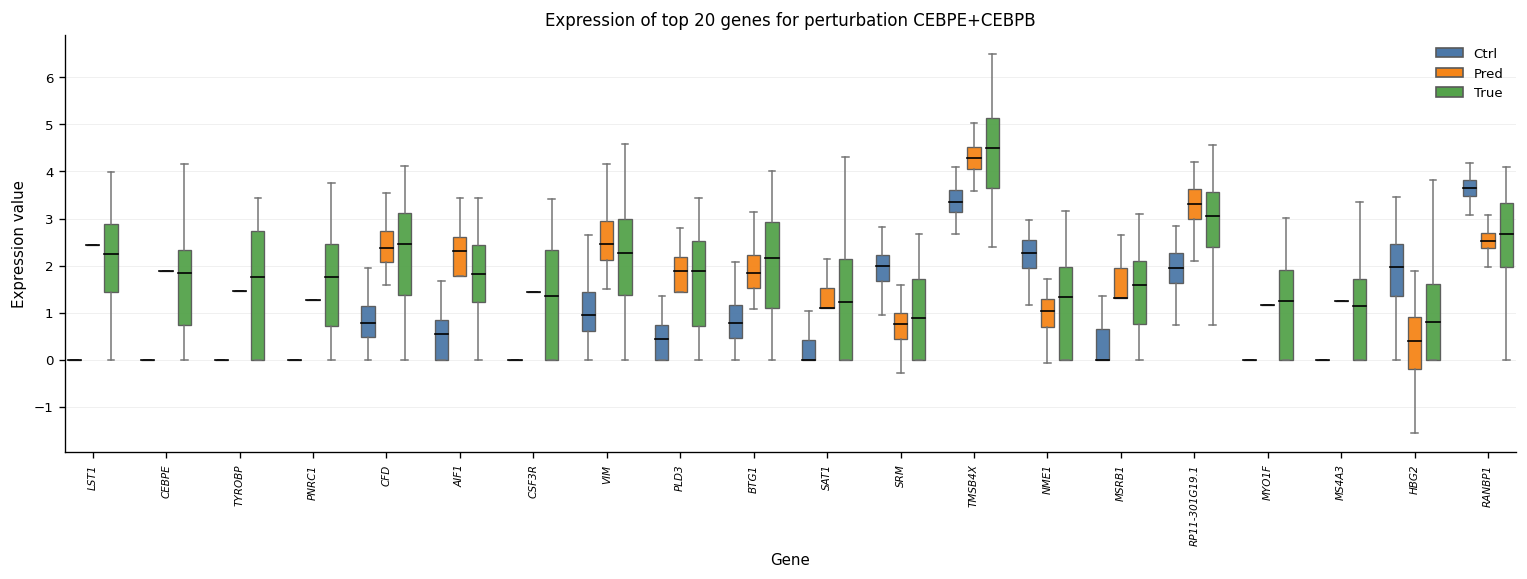

Saved:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/boxplots_per_perturbation/CEBPE_plus_CEBPB_top20_boxplot.svg
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/boxplots_per_perturbation/CEBPE_plus_CEBPB_top20_boxplot.png


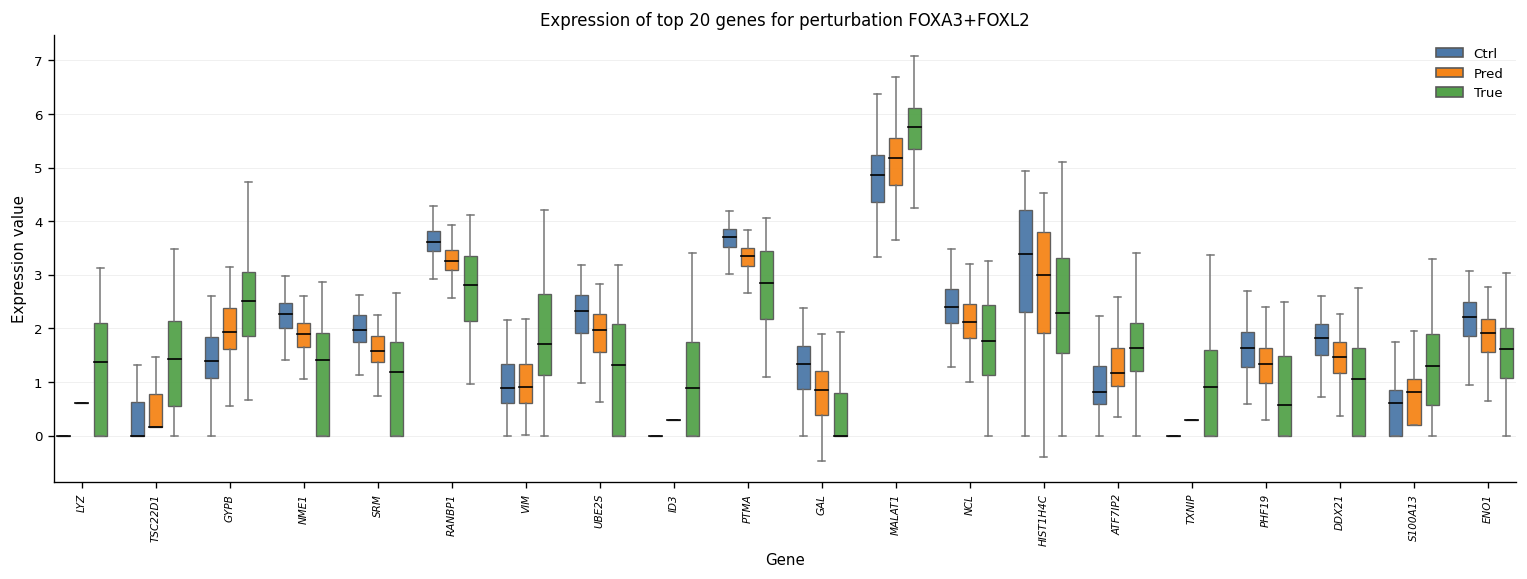

Saved:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/boxplots_per_perturbation/FOXA3_plus_FOXL2_top20_boxplot.svg
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/boxplots_per_perturbation/FOXA3_plus_FOXL2_top20_boxplot.png
Saved summary:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/boxplots_per_perturbation/selected_boxplots_summary.csv


,perturbation,n_true_cells,top_genes_first10,svg_path,png_path
0,CEBPE+CEBPB,111,"LST1, CEBPE, TYROBP, PNRC1, CFD, AIF1, CSF3R, ...",/root/autodl-tmp/scERso/norman_combo_gears_sty...,/root/autodl-tmp/scERso/norman_combo_gears_sty...
1,FOXA3+FOXL2,113,"LYZ, TSC22D1, GYPB, NME1, SRM, RANBP1, VIM, UB...",/root/autodl-tmp/scERso/norman_combo_gears_sty...,/root/autodl-tmp/scERso/norman_combo_gears_sty...


In [13]:
# =========================================================
# Norman double-gene perturbation:
# separate boxplot figure for each representative perturbation
# Ctrl vs Pred vs True, with italic compressed gene labels
# =========================================================

import os
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from scipy import sparse

# -----------------------------
# paths
# -----------------------------
H5AD_PATH = "/root/autodl-tmp/scERso/norman_combo_gears_style/data/norman_gears_style_seed1_trainGeneFrac0.75.h5ad"
PRED_NPZ = "/root/autodl-tmp/scERso/norman_combo_gears_style/checkpoints/gears_style_residual_diffusion_seed1/test_predictions_gears_style_residual.npz"
OUT_DIR = "/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/boxplots_per_perturbation"
os.makedirs(OUT_DIR, exist_ok=True)

# -----------------------------
# choose perturbations
# -----------------------------
# Keep the seen2 case CEBPE+CEBPB and a stable seen1 case FOXA3+FOXL2 by default
SELECTED_PERTS = [
    "CEBPE+CEBPB",   # seen2
    "FOXA3+FOXL2",   # seen1
]

# To use a seen1 case with a larger improvement, replace the selection with:
# SELECTED_PERTS = [
#     "CEBPE+CEBPB",
#     "CEBPE+PTPN12",
# ]

TOPK = 20
RANDOM_SEED = 42

# -----------------------------
# helpers
# -----------------------------
def to_dense(x):
    if sparse.issparse(x):
        return x.toarray()
    return np.asarray(x)

def get_var_names(adata):
    if "gene_name" in adata.var.columns:
        return adata.var["gene_name"].astype(str).values
    return adata.var_names.astype(str).values

def choose_condition_col(adata):
    if "condition" in adata.obs.columns:
        return "condition"
    elif "condition_name" in adata.obs.columns:
        return "condition_name"
    else:
        raise ValueError("No condition-like column found in adata.obs")

def get_control_mask(adata, cond_col):
    if "control" in adata.obs.columns:
        ctrl_col = adata.obs["control"]
        if ctrl_col.dtype == bool:
            return ctrl_col.values
        try:
            return ctrl_col.astype(bool).values
        except Exception:
            pass
    return (adata.obs[cond_col].astype(str).values == "ctrl")

def make_pred_expr_from_ctrl(ctrl_expr, pred_delta, n_target, seed=42):
    rng = np.random.default_rng(seed)
    n_ctrl = ctrl_expr.shape[0]
    replace = n_ctrl < n_target
    idx = rng.choice(n_ctrl, size=n_target, replace=replace)
    sampled_ctrl = ctrl_expr[idx]
    pred_expr = sampled_ctrl + pred_delta[None, :]
    return sampled_ctrl, pred_expr

def safe_filename(name):
    return name.replace("+", "_plus_").replace("/", "_")

def infer_fontsize(n_genes):
    if n_genes <= 12:
        return 8
    elif n_genes <= 16:
        return 7
    elif n_genes <= 20:
        return 6.2
    else:
        return 5.5

def draw_grouped_boxplots(ax, ctrl_mat, pred_mat, true_mat, gene_names, title):
    n_genes = ctrl_mat.shape[1]
    gap = 4.0
    width = 0.72

    ctrl_color = "#4C78A8"   # blue
    pred_color = "#F58518"   # orange
    true_color = "#54A24B"   # green

    positions_ctrl = []
    positions_pred = []
    positions_true = []
    tick_positions = []

    for i in range(n_genes):
        base = i * gap
        positions_ctrl.append(base + 0.0)
        positions_pred.append(base + 1.0)
        positions_true.append(base + 2.0)
        tick_positions.append(base + 1.0)

    common_kwargs = dict(
        patch_artist=True,
        showfliers=False,
        widths=width,
        medianprops=dict(color="black", linewidth=1.0),
        whiskerprops=dict(color="0.45", linewidth=0.9),
        capprops=dict(color="0.45", linewidth=0.9),
        boxprops=dict(linewidth=0.8, color="0.35"),
    )

    bp1 = ax.boxplot(
        [ctrl_mat[:, i] for i in range(n_genes)],
        positions=positions_ctrl,
        **common_kwargs
    )
    bp2 = ax.boxplot(
        [pred_mat[:, i] for i in range(n_genes)],
        positions=positions_pred,
        **common_kwargs
    )
    bp3 = ax.boxplot(
        [true_mat[:, i] for i in range(n_genes)],
        positions=positions_true,
        **common_kwargs
    )

    for b in bp1["boxes"]:
        b.set_facecolor(ctrl_color)
        b.set_alpha(0.95)
    for b in bp2["boxes"]:
        b.set_facecolor(pred_color)
        b.set_alpha(0.95)
    for b in bp3["boxes"]:
        b.set_facecolor(true_color)
        b.set_alpha(0.95)

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(gene_names, rotation=90, ha="center")
    ax.set_xlabel("Gene")
    ax.set_ylabel("Expression value")
    ax.set_title(title, fontsize=10)
    ax.grid(axis="y", alpha=0.18, linewidth=0.6)

    # Scale labels automatically and italicize gene names
    font_size = infer_fontsize(n_genes)
    for label in ax.get_xticklabels():
        label.set_fontstyle("italic")
        label.set_fontsize(font_size)

    # legend
    from matplotlib.patches import Patch
    handles = [
        Patch(facecolor=ctrl_color, edgecolor="0.35", label="Ctrl"),
        Patch(facecolor=pred_color, edgecolor="0.35", label="Pred"),
        Patch(facecolor=true_color, edgecolor="0.35", label="True"),
    ]
    ax.legend(handles=handles, frameon=False, loc="upper right", fontsize=8)

# -----------------------------
# load data
# -----------------------------
print("Loading h5ad...")
adata = ad.read_h5ad(H5AD_PATH)
print(adata)

print("Loading predictions...")
npz = np.load(PRED_NPZ, allow_pickle=True)

perturbation = npz["perturbation"].astype(str)
true_delta = npz["true_delta"]
corrected_delta = npz["corrected_delta"]

cond_col = choose_condition_col(adata)
var_names = get_var_names(adata)
ctrl_mask = get_control_mask(adata, cond_col)

if len(var_names) == adata.n_vars:
    adata.var_names = pd.Index(var_names)

ctrl_expr_all = to_dense(adata[ctrl_mask].X)

print("condition column:", cond_col)
print("n control cells:", int(ctrl_mask.sum()))

# -----------------------------
# plotting style
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -----------------------------
# generate one figure per perturbation
# -----------------------------
summary_rows = []

for pert in SELECTED_PERTS:
    if pert not in set(perturbation):
        raise ValueError(f"{pert} not found in prediction NPZ.")

    pred_idx = np.where(perturbation == pert)[0][0]
    pred_delta = corrected_delta[pred_idx]
    true_d = true_delta[pred_idx]

    # Select the top 20 genes by true-delta magnitude
    top_idx = np.argsort(np.abs(true_d))[-TOPK:]
    top_idx = top_idx[np.argsort(-np.abs(true_d[top_idx]))]
    top_gene_names = var_names[top_idx]

    # Observed perturbed cells
    pert_mask = (adata.obs[cond_col].astype(str).values == pert)
    n_true_cells = int(pert_mask.sum())
    if n_true_cells == 0:
        raise ValueError(f"No cells found in adata for perturbation {pert}")

    true_expr = to_dense(adata[pert_mask].X)

    # Pred = sampled control + predicted delta
    sampled_ctrl_expr, pred_expr = make_pred_expr_from_ctrl(
        ctrl_expr_all,
        pred_delta,
        n_target=n_true_cells,
        seed=RANDOM_SEED
    )

    ctrl_plot = sampled_ctrl_expr[:, top_idx]
    pred_plot = pred_expr[:, top_idx]
    true_plot = true_expr[:, top_idx]

    # Generate a separate figure
    fig, ax = plt.subplots(figsize=(12.8, 4.9))

    draw_grouped_boxplots(
        ax,
        ctrl_plot,
        pred_plot,
        true_plot,
        gene_names=top_gene_names,
        title=f"Expression of top {TOPK} genes for perturbation {pert}"
    )

    plt.tight_layout()

    file_stub = safe_filename(pert)
    svg_path = os.path.join(OUT_DIR, f"{file_stub}_top{TOPK}_boxplot.svg")
    png_path = os.path.join(OUT_DIR, f"{file_stub}_top{TOPK}_boxplot.png")

    fig.savefig(svg_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    plt.show()

    print("Saved:")
    print(svg_path)
    print(png_path)

    summary_rows.append({
        "perturbation": pert,
        "n_true_cells": n_true_cells,
        "top_genes_first10": ", ".join(top_gene_names[:10]),
        "svg_path": svg_path,
        "png_path": png_path,
    })

summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(OUT_DIR, "selected_boxplots_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("Saved summary:")
print(summary_csv)
display(summary_df)

NPZ keys:
['true_delta', 'additive_delta', 'corrected_delta', 'pred_residual', 'perturbation', 'perturb_type', 'gears_test_subgroup', 'gears_seen_type', 'n_available_single', 'var_names']
Using keys:
perturbation: perturbation
true_delta: true_delta
additive_delta: additive_delta
corrected_delta: corrected_delta


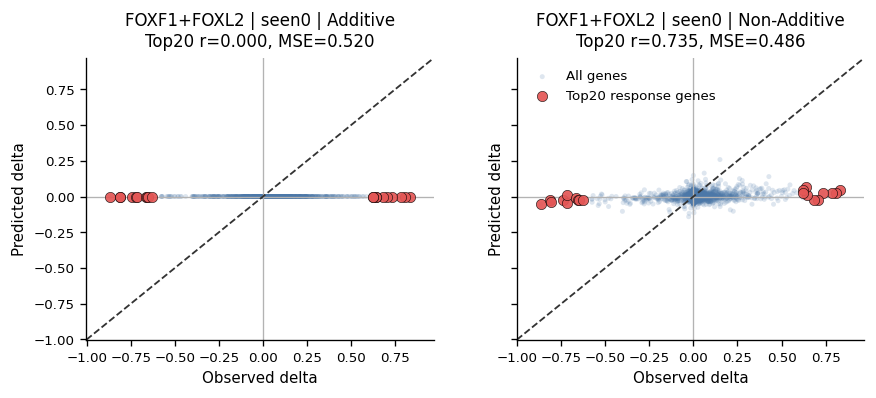

Saved: /root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_seen012_scatter_svg/FOXF1_plus_FOXL2_seen0_delta_scatter.svg


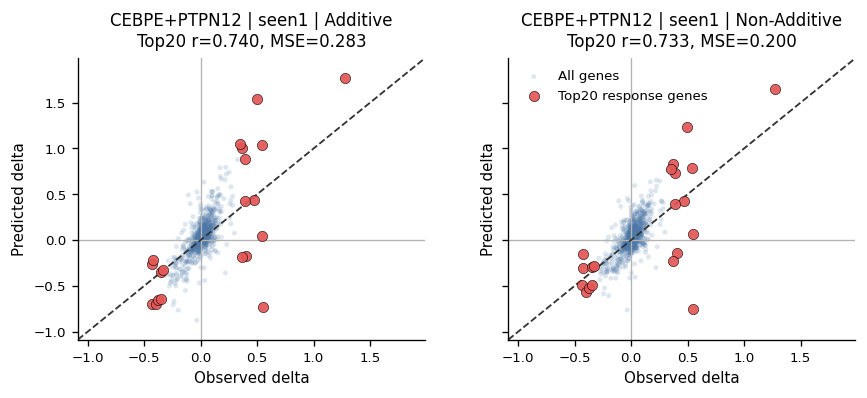

Saved: /root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_seen012_scatter_svg/CEBPE_plus_PTPN12_seen1_delta_scatter.svg


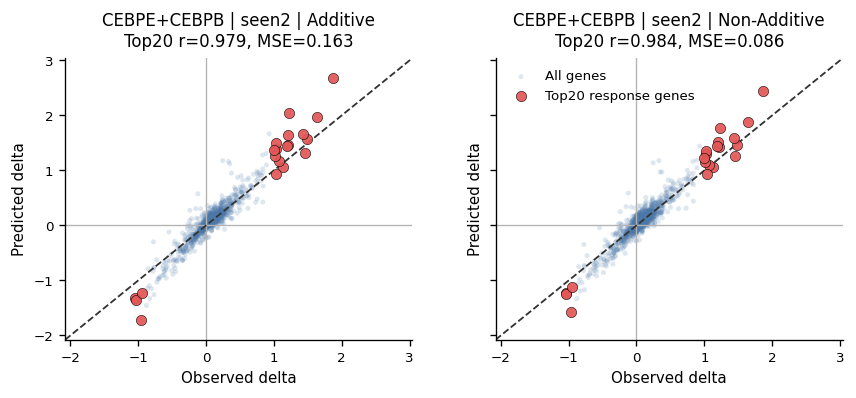

Saved: /root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_seen012_scatter_svg/CEBPE_plus_CEBPB_seen2_delta_scatter.svg

Saved summary: /root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_seen012_scatter_svg/selected_seen012_scatter_summary.csv


,perturbation,seen,additive_top20_r,additive_top20_mse,nonadditive_top20_r,nonadditive_top20_mse,svg_path
0,FOXF1+FOXL2,seen0,0.000000,0.519883,0.734885,0.485793,/root/autodl-tmp/scERso/norman_combo_gears_sty...
1,CEBPE+PTPN12,seen1,0.740467,0.283223,0.733480,0.200029,/root/autodl-tmp/scERso/norman_combo_gears_sty...
2,CEBPE+CEBPB,seen2,0.978896,0.163456,0.984382,0.085927,/root/autodl-tmp/scERso/norman_combo_gears_sty...


In [14]:
# =========================================================
# Select one perturbation from each seen group:
# seen0 / seen1 / seen2
# Generate one SVG per perturbation:
# Additive vs Non-Additive delta scatter
# =========================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# -----------------------------
# paths
# -----------------------------
PRED_NPZ = "/root/autodl-tmp/scERso/norman_combo_gears_style/checkpoints/gears_style_residual_diffusion_seed1/test_predictions_gears_style_residual.npz"

OUT_DIR = "/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_seen012_scatter_svg"
os.makedirs(OUT_DIR, exist_ok=True)

# -----------------------------
# selected perturbations
# -----------------------------
SELECTED = [
    {
        "perturbation": "FOXF1+FOXL2",
        "seen": "seen0",
        "reason": "best-looking seen0 example"
    },
    {
        "perturbation": "CEBPE+PTPN12",
        "seen": "seen1",
        "reason": "stable seen1 example with lower MSE"
    },
    {
        "perturbation": "CEBPE+CEBPB",
        "seen": "seen2",
        "reason": "strong seen2 example"
    },
]

TOPK = 20
MAX_BG_POINTS = 5000
RANDOM_SEED = 42

# -----------------------------
# key helpers
# -----------------------------
def find_key(npz, candidates, name):
    keys = list(npz.files)
    for k in candidates:
        if k in keys:
            return k
    raise KeyError(
        f"Cannot find {name}. Tried {candidates}. Available keys are:\n{keys}"
    )

def safe_pearson(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    if len(x) < 2:
        return np.nan
    if np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return 0.0
    return float(pearsonr(x, y)[0])

def mse(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    return float(np.mean((x - y) ** 2))

def safe_filename(name):
    return re.sub(r"[^A-Za-z0-9_.+-]+", "_", name).replace("+", "_plus_")

def match_pert_index(perturbations, target):
    perturbations = np.asarray(perturbations).astype(str)

    exact = np.where(perturbations == target)[0]
    if len(exact) > 0:
        return int(exact[0])

    # Support names such as "CEBPE+PTPN12 | seen1"
    loose = np.where([p.split("|")[0].strip() == target for p in perturbations])[0]
    if len(loose) > 0:
        return int(loose[0])

    # Support condition names with additional suffixes
    contains = np.where([target in p for p in perturbations])[0]
    if len(contains) > 0:
        return int(contains[0])

    raise ValueError(
        f"Perturbation {target} not found. Available examples:\n"
        + "\n".join(perturbations[:30])
    )

def get_axis_limits(obs, pred1, pred2, pad_ratio=0.08):
    vals = np.concatenate([
        np.asarray(obs).ravel(),
        np.asarray(pred1).ravel(),
        np.asarray(pred2).ravel(),
    ])
    vals = vals[np.isfinite(vals)]

    lo = np.percentile(vals, 0.5)
    hi = np.percentile(vals, 99.5)

    # Ensure that extreme Top20 points remain visible
    lo = min(lo, np.min(vals))
    hi = max(hi, np.max(vals))

    span = hi - lo
    if span < 1e-8:
        span = 1.0

    lo = lo - pad_ratio * span
    hi = hi + pad_ratio * span

    # Include zero within the plotted range
    lo = min(lo, 0)
    hi = max(hi, 0)

    return lo, hi

def plot_one_panel(ax, obs, pred, top_idx, title, bg_idx=None):
    if bg_idx is None:
        bg_idx = np.arange(len(obs))

    top_r = safe_pearson(obs[top_idx], pred[top_idx])
    top_mse = mse(obs[top_idx], pred[top_idx])

    # all genes
    ax.scatter(
        obs[bg_idx],
        pred[bg_idx],
        s=9,
        alpha=0.18,
        color="#4C78A8",
        edgecolors="none",
        label="All genes"
    )

    # top20 response genes
    ax.scatter(
        obs[top_idx],
        pred[top_idx],
        s=38,
        alpha=0.92,
        color="#E45756",
        edgecolors="black",
        linewidths=0.35,
        label="Top20 response genes",
        zorder=5
    )

    ax.axhline(0, color="0.70", linewidth=0.8)
    ax.axvline(0, color="0.70", linewidth=0.8)

    lo, hi = ax.get_xlim()
    ax.plot([lo, hi], [lo, hi], linestyle="--", color="0.20", linewidth=1.1)

    ax.set_title(
        f"{title}\nTop20 r={top_r:.3f}, MSE={top_mse:.3f}",
        fontsize=10,
        pad=7
    )
    ax.set_xlabel("Observed delta")
    ax.set_ylabel("Predicted delta")

    ax.tick_params(axis="both", labelsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return {
        "top20_r": top_r,
        "top20_mse": top_mse,
    }

# -----------------------------
# load prediction npz
# -----------------------------
npz = np.load(PRED_NPZ, allow_pickle=True)
print("NPZ keys:")
print(npz.files)

pert_key = find_key(
    npz,
    ["perturbation", "perturbations", "condition", "conditions"],
    "perturbation names"
)

true_key = find_key(
    npz,
    ["true_delta", "obs_delta", "observed_delta", "y_delta", "delta_true"],
    "true delta"
)

add_key = find_key(
    npz,
    [
        "additive_delta",
        "pred_delta_additive",
        "additive_pred_delta",
        "source_delta",
        "base_delta",
        "mean_delta",
        "pred_delta"
    ],
    "additive delta"
)

corr_key = find_key(
    npz,
    [
        "corrected_delta",
        "residual_corrected_delta",
        "pred_delta_corrected",
        "non_additive_delta",
        "nonadditive_delta",
        "final_delta"
    ],
    "non-additive / corrected delta"
)

perturbations = npz[pert_key].astype(str)
true_delta = np.asarray(npz[true_key])
additive_delta = np.asarray(npz[add_key])
corrected_delta = np.asarray(npz[corr_key])

print("Using keys:")
print("perturbation:", pert_key)
print("true_delta:", true_key)
print("additive_delta:", add_key)
print("corrected_delta:", corr_key)

# -----------------------------
# plotting style
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

rng = np.random.default_rng(RANDOM_SEED)
summary_rows = []

# -----------------------------
# generate one svg per perturbation
# -----------------------------
for item in SELECTED:
    pert = item["perturbation"]
    seen = item["seen"]

    idx = match_pert_index(perturbations, pert)

    obs = true_delta[idx].astype(float)
    pred_add = additive_delta[idx].astype(float)
    pred_corr = corrected_delta[idx].astype(float)

    valid = np.isfinite(obs) & np.isfinite(pred_add) & np.isfinite(pred_corr)
    obs = obs[valid]
    pred_add = pred_add[valid]
    pred_corr = pred_corr[valid]

    # Top20 response genes based on absolute observed delta
    top_idx = np.argsort(np.abs(obs))[-TOPK:]
    top_idx = top_idx[np.argsort(-np.abs(obs[top_idx]))]

    # background downsample, keep the file light and clean
    all_idx = np.arange(len(obs))
    if len(all_idx) > MAX_BG_POINTS:
        bg_idx = rng.choice(all_idx, size=MAX_BG_POINTS, replace=False)
    else:
        bg_idx = all_idx

    fig, axes = plt.subplots(
        1, 2,
        figsize=(7.2, 3.45),
        sharex=True,
        sharey=True
    )

    lo, hi = get_axis_limits(obs, pred_add, pred_corr)
    for ax in axes:
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

    res_add = plot_one_panel(
        axes[0],
        obs,
        pred_add,
        top_idx,
        title=f"{pert} | {seen} | Additive",
        bg_idx=bg_idx
    )

    res_corr = plot_one_panel(
        axes[1],
        obs,
        pred_corr,
        top_idx,
        title=f"{pert} | {seen} | Non-Additive",
        bg_idx=bg_idx
    )

    axes[1].legend(frameon=False, loc="upper left")

    fig.subplots_adjust(
        left=0.08,
        right=0.98,
        bottom=0.16,
        top=0.84,
        wspace=0.24
    )

    out_svg = os.path.join(
        OUT_DIR,
        f"{safe_filename(pert)}_{seen}_delta_scatter.svg"
    )

    fig.savefig(out_svg, bbox_inches="tight")
    plt.show()

    print("Saved:", out_svg)

    summary_rows.append({
        "perturbation": pert,
        "seen": seen,
        "additive_top20_r": res_add["top20_r"],
        "additive_top20_mse": res_add["top20_mse"],
        "nonadditive_top20_r": res_corr["top20_r"],
        "nonadditive_top20_mse": res_corr["top20_mse"],
        "svg_path": out_svg,
    })

summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(OUT_DIR, "selected_seen012_scatter_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nSaved summary:", summary_csv)
display(summary_df)

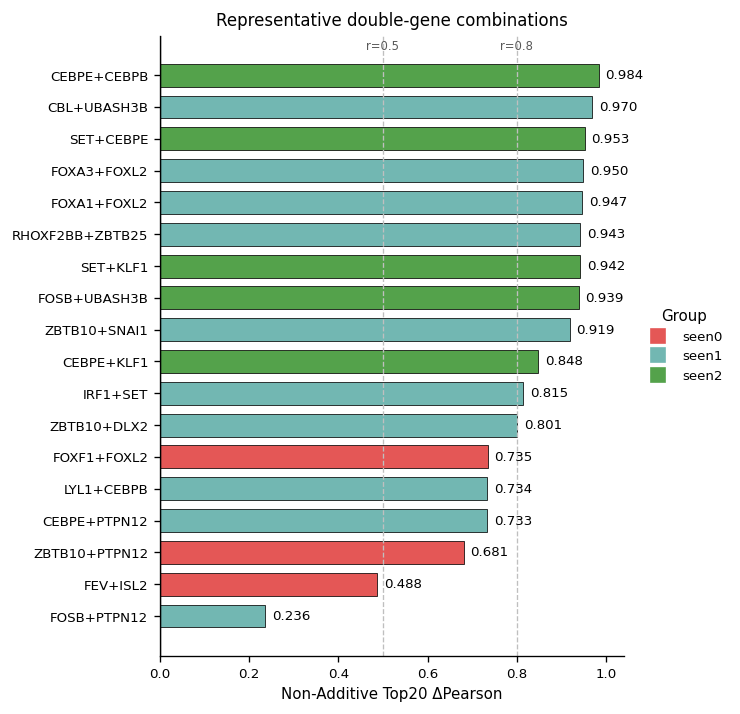

Saved:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figB_nonadditive_top20_pearson_representative_combos.svg
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figB_nonadditive_top20_pearson_representative_combos.png
Saved table:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figB_nonadditive_top20_pearson_representative_combos.csv


,perturbation,subgroup,corr_top20_delta_pearson,corr_top20_delta_mse,corr_opposite_direction,add_top20_delta_pearson,improve_top20_pearson
17,CEBPE+CEBPB,combo_seen2,0.984382,0.085927,0.00,0.978896,0.005486
16,CBL+UBASH3B,combo_seen1,0.969705,0.661879,0.00,0.945587,0.024118
15,SET+CEBPE,combo_seen2,0.952661,0.117844,0.00,0.939331,0.013330
14,FOXA3+FOXL2,combo_seen1,0.949594,0.278910,0.00,0.929259,0.020335
13,FOXA1+FOXL2,combo_seen1,0.947143,0.099389,0.00,0.914224,0.032920
12,RHOXF2BB+ZBTB25,combo_seen1,0.942845,0.181780,0.05,0.949217,-0.006372
11,SET+KLF1,combo_seen2,0.942044,0.073609,0.00,0.945152,-0.003107
10,FOSB+UBASH3B,combo_seen2,0.938830,0.030765,0.00,0.931120,0.007710
9,ZBTB10+SNAI1,combo_seen1,0.919320,0.465806,0.00,0.902299,0.017022
8,CEBPE+KLF1,combo_seen2,0.848276,0.068795,0.00,0.835229,0.013047


In [3]:
# =========================================================
# Figure B revised:
# Representative double-gene combinations ranked by
# Non-Additive Top20 ΔPearson
# Style follows previous FigB barplot
# y-axis labels without seen-group parentheses
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/root/autodl-tmp/scERso/norman_combo_gears_style"
OUT_DIR = f"{BASE}/figures/gears_style_residual_diffusion_seed1"
os.makedirs(OUT_DIR, exist_ok=True)

COMBO_METRICS_CSV = f"{OUT_DIR}/figB_per_combo_improvement_metrics.csv"
combo_metrics = pd.read_csv(COMBO_METRICS_CSV)

# Retain only double-gene combinations
combo_metrics = combo_metrics[
    combo_metrics["subgroup"].isin(["combo_seen0", "combo_seen1", "combo_seen2"])
].copy()

# Preserve the original figure palette
GROUP_COLORS = {
    "combo_seen0": "#E45756",  # red
    "combo_seen1": "#72B7B2",  # teal
    "combo_seen2": "#54A24B",  # green
}

GROUP_LABELS = {
    "combo_seen0": "seen0",
    "combo_seen1": "seen1",
    "combo_seen2": "seen2",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# ---------------------------------------------------------
# Select combinations for display
# ---------------------------------------------------------
# Follow the original Figure B combination-selection strategy:
# Select the 12 largest Top20 ΔMSE improvements and the 6 weakest cases,
# and use Non-Additive Pearson on the x-axis.

top_pos = combo_metrics.sort_values("improve_top20_mse", ascending=False).head(12)
top_neg = combo_metrics.sort_values("improve_top20_mse", ascending=True).head(6)

plot_df = (
    pd.concat([top_pos, top_neg], axis=0)
    .drop_duplicates("perturbation")
    .sort_values("corr_top20_delta_pearson", ascending=True)
    .reset_index(drop=True)
)

# Show only combination names on the y-axis without seen-group suffixes
plot_df["label"] = plot_df["perturbation"]

# ---------------------------------------------------------
# plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.4, 6.8))

y = np.arange(len(plot_df))
values = plot_df["corr_top20_delta_pearson"].values
colors = [GROUP_COLORS[g] for g in plot_df["subgroup"]]

ax.barh(
    y,
    values,
    color=colors,
    edgecolor="black",
    linewidth=0.45,
    height=0.72,
)

# Pearson reference lines
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(0.5, color="0.75", linewidth=0.8, linestyle="--")
ax.axvline(0.8, color="0.75", linewidth=0.8, linestyle="--")

ax.text(
    0.5,
    len(plot_df) - 0.3,
    "r=0.5",
    ha="center",
    va="bottom",
    fontsize=7,
    color="0.35",
)

ax.text(
    0.8,
    len(plot_df) - 0.3,
    "r=0.8",
    ha="center",
    va="bottom",
    fontsize=7,
    color="0.35",
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["label"], fontsize=8)

ax.set_xlim(0, 1.04)
ax.set_xlabel("Non-Additive Top20 ΔPearson")
ax.set_title("Representative double-gene combinations")

# Value labels
for i, value in enumerate(values):
    ax.text(
        value + 0.015,
        i,
        f"{value:.3f}",
        va="center",
        ha="left",
        fontsize=8,
    )

# Retain seen-group information in the legend
handles = [
    plt.Line2D(
        [0], [0],
        marker="s",
        linestyle="",
        color=GROUP_COLORS[g],
        label=GROUP_LABELS[g],
        markersize=8,
    )
    for g in ["combo_seen0", "combo_seen1", "combo_seen2"]
]

ax.legend(
    handles=handles,
    frameon=False,
    title="Group",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
)

plt.subplots_adjust(left=0.32, right=0.78, top=0.90, bottom=0.14)

# Overwrite the existing output paths
svg_path = os.path.join(
    OUT_DIR,
    "figB_nonadditive_top20_pearson_representative_combos.svg"
)
png_path = os.path.join(
    OUT_DIR,
    "figB_nonadditive_top20_pearson_representative_combos.png"
)

fig.savefig(svg_path, bbox_inches="tight")
fig.savefig(png_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(svg_path)
print(png_path)

# Save the corresponding table to the existing output path
table_path = os.path.join(
    OUT_DIR,
    "figB_nonadditive_top20_pearson_representative_combos.csv"
)

plot_df[
    [
        "perturbation",
        "subgroup",
        "corr_top20_delta_pearson",
        "corr_top20_delta_mse",
        "corr_opposite_direction",
        "add_top20_delta_pearson",
        "improve_top20_pearson",
        "improve_top20_mse",
    ]
].sort_values("corr_top20_delta_pearson", ascending=False).to_csv(table_path, index=False)

print("Saved table:")
print(table_path)

display(
    plot_df[
        [
            "perturbation",
            "subgroup",
            "corr_top20_delta_pearson",
            "corr_top20_delta_mse",
            "corr_opposite_direction",
            "add_top20_delta_pearson",
            "improve_top20_pearson",
        ]
    ].sort_values("corr_top20_delta_pearson", ascending=False)
)

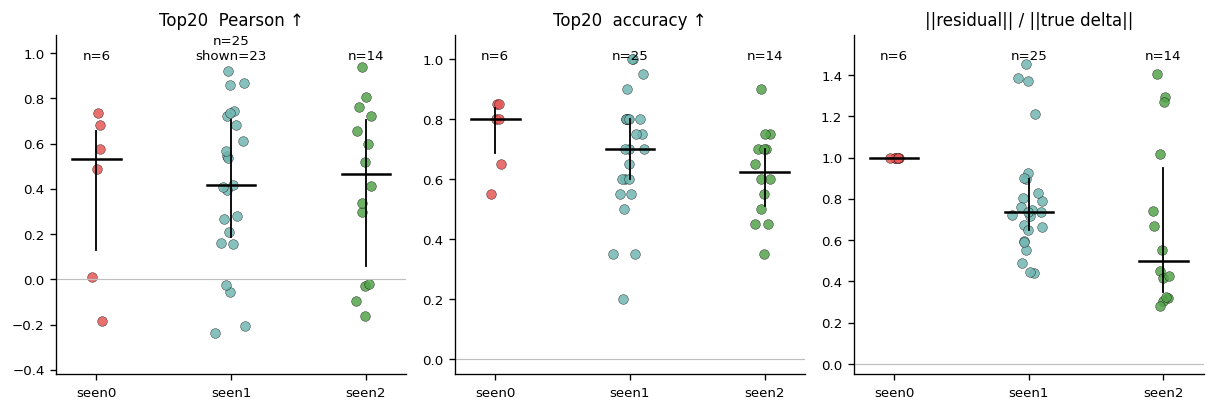

Saved:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figE2_residual_recovery_metric_summary.svg
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figE2_residual_recovery_metric_summary.png
Saved trimmed display record:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figE2_trimmed_display_points_below_minus04.csv


,perturbation,subgroup,residual_pearson_top20,metric,cutoff
4,CDKN1C+CDKN1A,combo_seen1,-0.456038,residual_pearson_top20,-0.4
34,RHOXF2BB+ZBTB25,combo_seen1,-0.585552,residual_pearson_top20,-0.4


In [1]:
# =========================================================
# Fig E2 only: residual metric summary
# Remove extreme display points below -0.4 for residual Pearson only
# Overwrite original figE2 svg/png
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/root/autodl-tmp/scERso/norman_combo_gears_style"
OUT_DIR = f"{BASE}/figures/gears_style_residual_diffusion_seed1"
os.makedirs(OUT_DIR, exist_ok=True)

RESID_METRIC_CSV = os.path.join(OUT_DIR, "figE_residual_recovery_metrics.csv")
resid_metrics = pd.read_csv(RESID_METRIC_CSV)

GROUP_ORDER = ["combo_seen0", "combo_seen1", "combo_seen2"]
GROUP_LABELS = {
    "combo_seen0": "seen0",
    "combo_seen1": "seen1",
    "combo_seen2": "seen2",
}
GROUP_COLORS = {
    "combo_seen0": "#E45756",
    "combo_seen1": "#72B7B2",
    "combo_seen2": "#54A24B",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# Update the title only
plot_specs = [
    ("residual_pearson_top20", "Top20  Pearson ↑"),
    ("residual_sign_accuracy_top20", "Top20  accuracy ↑"),
    ("residual_fraction", "||residual|| / ||true delta||"),
]

# Apply a display-only filter that excludes Pearson values below -0.4
DISPLAY_LOWER_CUTOFF = {
    "residual_pearson_top20": -0.4,
    "residual_sign_accuracy_top20": None,
    "residual_fraction": None,
}

trimmed_rows = []

fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.5))

for ax, (col, title) in zip(axes, plot_specs):
    all_display_values = []

    for gi, group in enumerate(GROUP_ORDER):
        sub_full = resid_metrics[resid_metrics["subgroup"] == group].copy()

        cutoff = DISPLAY_LOWER_CUTOFF.get(col, None)

        if cutoff is not None:
            trim_mask = sub_full[col] < cutoff
            if trim_mask.any():
                tmp = sub_full.loc[trim_mask, ["perturbation", "subgroup", col]].copy()
                tmp["metric"] = col
                tmp["cutoff"] = cutoff
                trimmed_rows.append(tmp)

            sub = sub_full.loc[~trim_mask].copy()
        else:
            sub = sub_full.copy()

        values = sub[col].dropna().values
        all_display_values.extend(values.tolist())

        rng = np.random.default_rng(800 + gi)
        x = np.full(len(values), gi) + rng.normal(0, 0.045, size=len(values))

        ax.scatter(
            x,
            values,
            s=34,
            color=GROUP_COLORS[group],
            edgecolor="black",
            linewidth=0.25,
            alpha=0.85,
        )

        if len(values) > 0:
            med = np.nanmedian(values)
            q1, q3 = np.nanpercentile(values, [25, 75])

            ax.plot(
                [gi - 0.18, gi + 0.18],
                [med, med],
                color="black",
                linewidth=1.5,
            )
            ax.plot(
                [gi, gi],
                [q1, q3],
                color="black",
                linewidth=1.1,
            )

        full_n = len(sub_full)
        shown_n = len(sub)
        removed_n = full_n - shown_n

        label = f"n={full_n}"
        if removed_n > 0:
            label += f"\nshown={shown_n}"

        ax.text(
            gi,
            0,
            label,
            ha="center",
            va="bottom",
            fontsize=8,
        )

    all_display_values = np.asarray(all_display_values, dtype=float)
    all_display_values = all_display_values[np.isfinite(all_display_values)]

    if len(all_display_values) > 0:
        y_min = np.nanmin(all_display_values)
        y_max = np.nanmax(all_display_values)
        y_range = y_max - y_min + 1e-8

        if col == "residual_pearson_top20":
            y_min = min(-0.42, y_min - 0.08 * y_range)
            y_max = max(1.0, y_max + 0.12 * y_range)
        elif col == "residual_sign_accuracy_top20":
            y_min = -0.05
            y_max = 1.08
        elif col == "residual_fraction":
            y_min = -0.05
            y_max = y_max + 0.12 * y_range

        ax.set_ylim(y_min, y_max)

        for text in ax.texts:
            text.set_y(y_max - 0.08 * (y_max - y_min))

    ax.set_xticks(np.arange(len(GROUP_ORDER)))
    ax.set_xticklabels([GROUP_LABELS[g] for g in GROUP_ORDER])
    ax.set_title(title)
    ax.axhline(0, color="0.75", linewidth=0.7)

plt.tight_layout()

# Overwrite the existing output path
svg_path2 = os.path.join(OUT_DIR, "figE2_residual_recovery_metric_summary.svg")
png_path2 = os.path.join(OUT_DIR, "figE2_residual_recovery_metric_summary.png")

fig.savefig(svg_path2, bbox_inches="tight")
fig.savefig(png_path2, bbox_inches="tight")
plt.show()

print("Saved:")
print(svg_path2)
print(png_path2)

# Save points excluded only from the displayed figure
if len(trimmed_rows) > 0:
    trimmed_df = pd.concat(trimmed_rows, axis=0)
else:
    trimmed_df = pd.DataFrame(columns=["perturbation", "subgroup", "metric", "cutoff"])

trimmed_path = os.path.join(OUT_DIR, "figE2_trimmed_display_points_below_minus04.csv")
trimmed_df.to_csv(trimmed_path, index=False)

print("Saved trimmed display record:")
print(trimmed_path)

if len(trimmed_df) > 0:
    display(trimmed_df)
else:
    print("No points were removed for display.")

NPZ keys:
['true_delta', 'additive_delta', 'corrected_delta', 'pred_residual', 'perturbation', 'perturb_type', 'gears_test_subgroup', 'gears_seen_type', 'n_available_single', 'var_names']
Using keys:
perturbation: perturbation
true_delta: true_delta
additive_delta: additive_delta
corrected_delta: corrected_delta


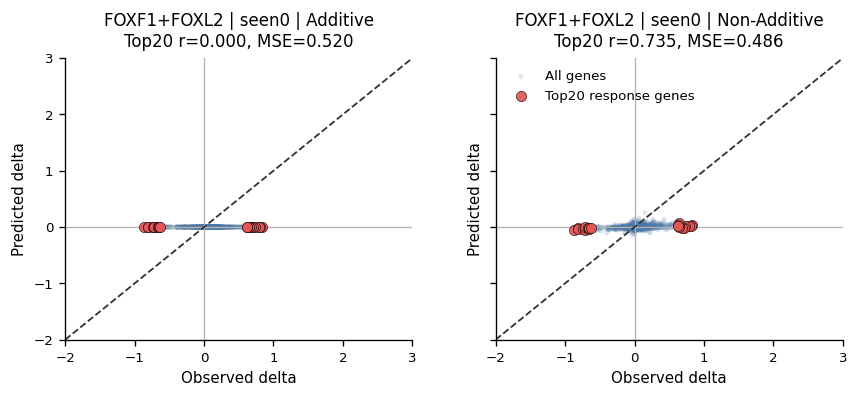

Saved: /root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_seen012_scatter_svg/FOXF1_plus_FOXL2_seen0_delta_scatter.svg


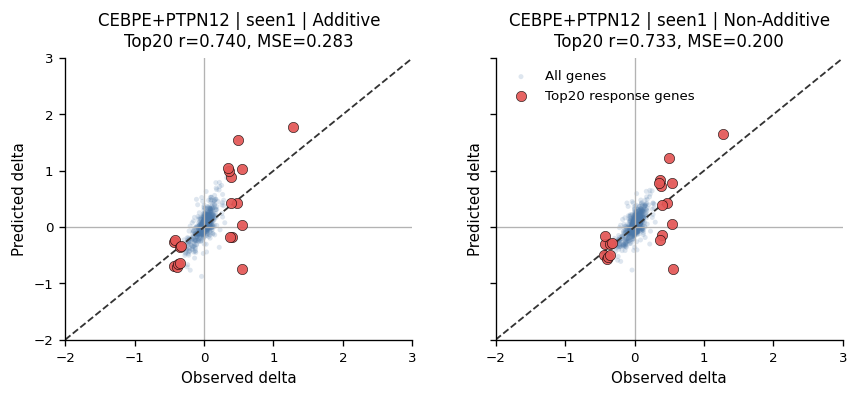

Saved: /root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_seen012_scatter_svg/CEBPE_plus_PTPN12_seen1_delta_scatter.svg


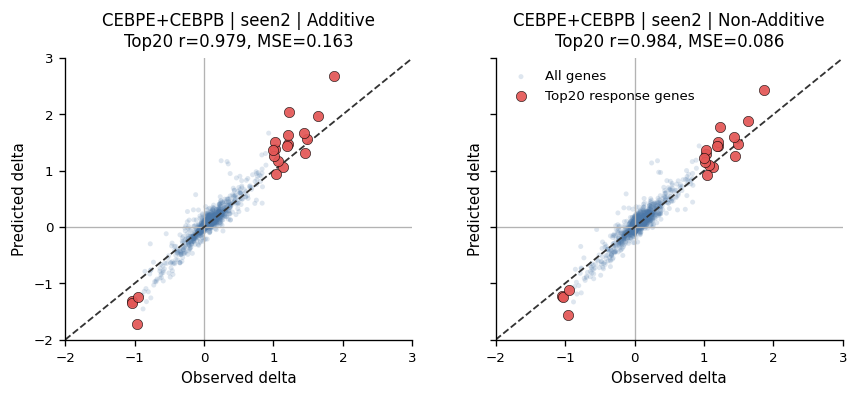

Saved: /root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_seen012_scatter_svg/CEBPE_plus_CEBPB_seen2_delta_scatter.svg

Saved summary: /root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_seen012_scatter_svg/selected_seen012_scatter_summary.csv


,perturbation,seen,additive_top20_r,additive_top20_mse,nonadditive_top20_r,nonadditive_top20_mse,svg_path
0,FOXF1+FOXL2,seen0,0.000000,0.519883,0.734885,0.485793,/root/autodl-tmp/scERso/norman_combo_gears_sty...
1,CEBPE+PTPN12,seen1,0.740467,0.283223,0.733480,0.200029,/root/autodl-tmp/scERso/norman_combo_gears_sty...
2,CEBPE+CEBPB,seen2,0.978896,0.163456,0.984382,0.085927,/root/autodl-tmp/scERso/norman_combo_gears_sty...


In [1]:
# =========================================================
# Select one perturbation from each seen group:
# seen0 / seen1 / seen2
# Generate one SVG per perturbation:
# Additive vs Non-Additive delta scatter
# Fixed x/y axis range: -2 to 3
# =========================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# -----------------------------
# paths
# -----------------------------
PRED_NPZ = "/root/autodl-tmp/scERso/norman_combo_gears_style/checkpoints/gears_style_residual_diffusion_seed1/test_predictions_gears_style_residual.npz"

OUT_DIR = "/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_seen012_scatter_svg"
os.makedirs(OUT_DIR, exist_ok=True)

# -----------------------------
# selected perturbations
# -----------------------------
SELECTED = [
    {
        "perturbation": "FOXF1+FOXL2",
        "seen": "seen0",
        "reason": "best-looking seen0 example"
    },
    {
        "perturbation": "CEBPE+PTPN12",
        "seen": "seen1",
        "reason": "stable seen1 example with lower MSE"
    },
    {
        "perturbation": "CEBPE+CEBPB",
        "seen": "seen2",
        "reason": "strong seen2 example"
    },
]

TOPK = 20
MAX_BG_POINTS = 5000
RANDOM_SEED = 42

# Use fixed axis limits
AXIS_MIN = -2
AXIS_MAX = 3

# -----------------------------
# key helpers
# -----------------------------
def find_key(npz, candidates, name):
    keys = list(npz.files)
    for k in candidates:
        if k in keys:
            return k
    raise KeyError(
        f"Cannot find {name}. Tried {candidates}. Available keys are:\n{keys}"
    )

def safe_pearson(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    if len(x) < 2:
        return np.nan
    if np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return 0.0
    return float(pearsonr(x, y)[0])

def mse(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    return float(np.mean((x - y) ** 2))

def safe_filename(name):
    return re.sub(r"[^A-Za-z0-9_.+-]+", "_", name).replace("+", "_plus_")

def match_pert_index(perturbations, target):
    perturbations = np.asarray(perturbations).astype(str)

    exact = np.where(perturbations == target)[0]
    if len(exact) > 0:
        return int(exact[0])

    # Support names such as "CEBPE+PTPN12 | seen1"
    loose = np.where([p.split("|")[0].strip() == target for p in perturbations])[0]
    if len(loose) > 0:
        return int(loose[0])

    # Support condition names with additional suffixes
    contains = np.where([target in p for p in perturbations])[0]
    if len(contains) > 0:
        return int(contains[0])

    raise ValueError(
        f"Perturbation {target} not found. Available examples:\n"
        + "\n".join(perturbations[:30])
    )

def plot_one_panel(ax, obs, pred, top_idx, title, bg_idx=None):
    if bg_idx is None:
        bg_idx = np.arange(len(obs))

    top_r = safe_pearson(obs[top_idx], pred[top_idx])
    top_mse = mse(obs[top_idx], pred[top_idx])

    # all genes
    ax.scatter(
        obs[bg_idx],
        pred[bg_idx],
        s=9,
        alpha=0.18,
        color="#4C78A8",
        edgecolors="none",
        label="All genes"
    )

    # top20 response genes
    ax.scatter(
        obs[top_idx],
        pred[top_idx],
        s=38,
        alpha=0.92,
        color="#E45756",
        edgecolors="black",
        linewidths=0.35,
        label="Top20 response genes",
        zorder=5
    )

    ax.axhline(0, color="0.70", linewidth=0.8)
    ax.axvline(0, color="0.70", linewidth=0.8)

    # Match the diagonal line to the fixed axis limits
    ax.plot(
        [AXIS_MIN, AXIS_MAX],
        [AXIS_MIN, AXIS_MAX],
        linestyle="--",
        color="0.20",
        linewidth=1.1
    )

    ax.set_title(
        f"{title}\nTop20 r={top_r:.3f}, MSE={top_mse:.3f}",
        fontsize=10,
        pad=7
    )
    ax.set_xlabel("Observed delta")
    ax.set_ylabel("Predicted delta")

    ax.tick_params(axis="both", labelsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return {
        "top20_r": top_r,
        "top20_mse": top_mse,
    }

# -----------------------------
# load prediction npz
# -----------------------------
npz = np.load(PRED_NPZ, allow_pickle=True)
print("NPZ keys:")
print(npz.files)

pert_key = find_key(
    npz,
    ["perturbation", "perturbations", "condition", "conditions"],
    "perturbation names"
)

true_key = find_key(
    npz,
    ["true_delta", "obs_delta", "observed_delta", "y_delta", "delta_true"],
    "true delta"
)

add_key = find_key(
    npz,
    [
        "additive_delta",
        "pred_delta_additive",
        "additive_pred_delta",
        "source_delta",
        "base_delta",
        "mean_delta",
        "pred_delta"
    ],
    "additive delta"
)

corr_key = find_key(
    npz,
    [
        "corrected_delta",
        "residual_corrected_delta",
        "pred_delta_corrected",
        "non_additive_delta",
        "nonadditive_delta",
        "final_delta"
    ],
    "non-additive / corrected delta"
)

perturbations = npz[pert_key].astype(str)
true_delta = np.asarray(npz[true_key])
additive_delta = np.asarray(npz[add_key])
corrected_delta = np.asarray(npz[corr_key])

print("Using keys:")
print("perturbation:", pert_key)
print("true_delta:", true_key)
print("additive_delta:", add_key)
print("corrected_delta:", corr_key)

# -----------------------------
# plotting style
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

rng = np.random.default_rng(RANDOM_SEED)
summary_rows = []

# -----------------------------
# generate one svg per perturbation
# -----------------------------
for item in SELECTED:
    pert = item["perturbation"]
    seen = item["seen"]

    idx = match_pert_index(perturbations, pert)

    obs = true_delta[idx].astype(float)
    pred_add = additive_delta[idx].astype(float)
    pred_corr = corrected_delta[idx].astype(float)

    valid = np.isfinite(obs) & np.isfinite(pred_add) & np.isfinite(pred_corr)
    obs = obs[valid]
    pred_add = pred_add[valid]
    pred_corr = pred_corr[valid]

    # Top20 response genes based on absolute observed delta
    top_idx = np.argsort(np.abs(obs))[-TOPK:]
    top_idx = top_idx[np.argsort(-np.abs(obs[top_idx]))]

    # background downsample, keep the file light and clean
    all_idx = np.arange(len(obs))
    if len(all_idx) > MAX_BG_POINTS:
        bg_idx = rng.choice(all_idx, size=MAX_BG_POINTS, replace=False)
    else:
        bg_idx = all_idx

    fig, axes = plt.subplots(
        1, 2,
        figsize=(7.2, 3.45),
        sharex=True,
        sharey=True
    )

    # =====================================================
    # Fix both x- and y-axis limits from -2 to 3
    # =====================================================
    for ax in axes:
        ax.set_xlim(AXIS_MIN, AXIS_MAX)
        ax.set_ylim(AXIS_MIN, AXIS_MAX)
        ax.set_xticks(np.arange(AXIS_MIN, AXIS_MAX + 1, 1))
        ax.set_yticks(np.arange(AXIS_MIN, AXIS_MAX + 1, 1))

    res_add = plot_one_panel(
        axes[0],
        obs,
        pred_add,
        top_idx,
        title=f"{pert} | {seen} | Additive",
        bg_idx=bg_idx
    )

    res_corr = plot_one_panel(
        axes[1],
        obs,
        pred_corr,
        top_idx,
        title=f"{pert} | {seen} | Non-Additive",
        bg_idx=bg_idx
    )

    axes[1].legend(frameon=False, loc="upper left")

    fig.subplots_adjust(
        left=0.08,
        right=0.98,
        bottom=0.16,
        top=0.84,
        wspace=0.24
    )

    out_svg = os.path.join(
        OUT_DIR,
        f"{safe_filename(pert)}_{seen}_delta_scatter.svg"
    )

    fig.savefig(out_svg, bbox_inches="tight")
    plt.show()

    print("Saved:", out_svg)

    summary_rows.append({
        "perturbation": pert,
        "seen": seen,
        "additive_top20_r": res_add["top20_r"],
        "additive_top20_mse": res_add["top20_mse"],
        "nonadditive_top20_r": res_corr["top20_r"],
        "nonadditive_top20_mse": res_corr["top20_mse"],
        "svg_path": out_svg,
    })

summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(OUT_DIR, "selected_seen012_scatter_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nSaved summary:", summary_csv)
display(summary_df)

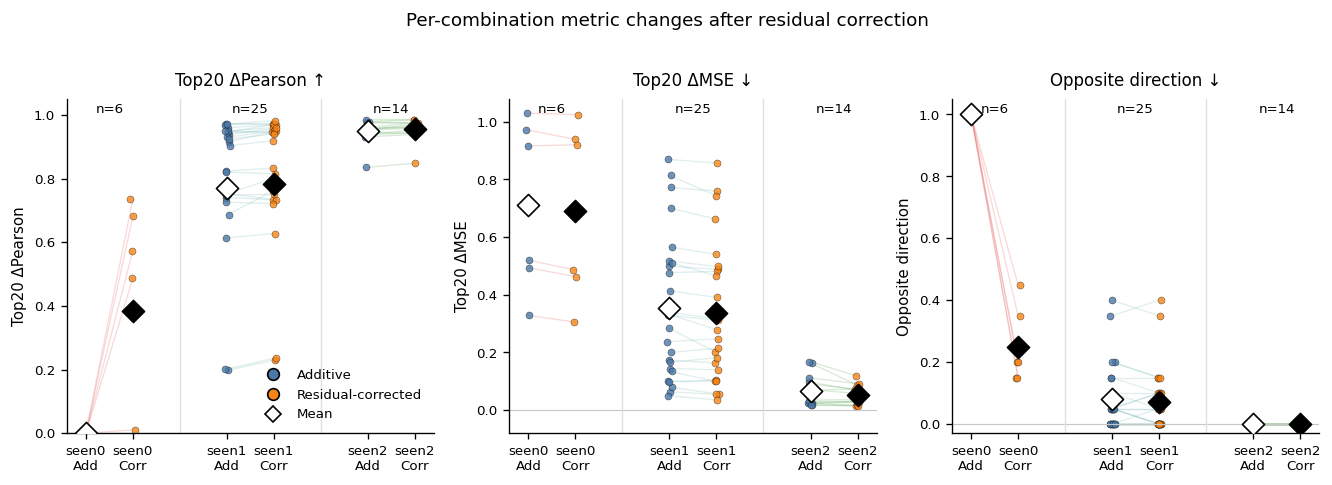

Saved:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD1_paired_metrics_by_seen_group_polished.svg
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD1_paired_metrics_by_seen_group_polished.png


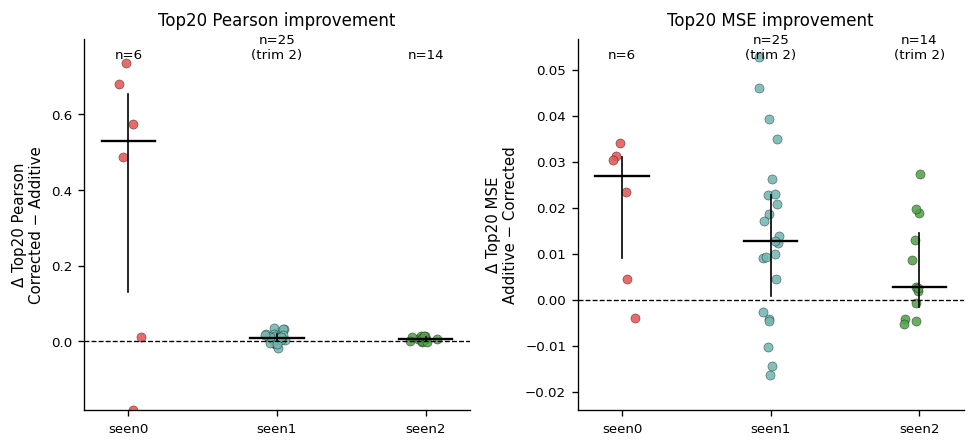

Saved:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD2_improvement_distribution_by_seen_group_polished.svg
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD2_improvement_distribution_by_seen_group_polished.png
Saved trimmed-point record:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD_trimmed_points_for_display.csv

Trimmed points for display only:


,perturbation,subgroup,metric,improve_top20_pearson,improve_top20_mse
7,CEBPE+PTPN12,combo_seen1,improve_top20_mse,-0.006987,0.083195
42,ZBTB10+DLX2,combo_seen1,improve_top20_mse,0.049945,0.069920
5,CEBPE+CEBPB,combo_seen2,improve_top20_mse,0.005486,0.077529
36,SET+CEBPE,combo_seen2,improve_top20_mse,0.013330,0.050029
2,CBL+UBASH3A,combo_seen1,improve_top20_pearson,0.077085,0.026321
42,ZBTB10+DLX2,combo_seen1,improve_top20_pearson,0.049945,0.069920


,group,n,add_top20_pearson_mean,corr_top20_pearson_mean,mean_top20_pearson_gain,add_top20_mse_mean,corr_top20_mse_mean,mean_top20_mse_reduction,fraction_mse_improved,fraction_pearson_improved
0,seen0,6,0.000000,0.384293,0.384293,0.709646,0.689770,0.019876,0.833333,0.833333
1,seen1,25,0.769907,0.784112,0.014205,0.354674,0.335741,0.018933,0.760000,0.760000
2,seen2,14,0.949069,0.955008,0.005939,0.067413,0.052622,0.014790,0.714286,0.714286


Saved summary:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD_polished_metric_change_summary.csv


In [1]:
# Figure D polished: cleaner paired metric plots with mild trimming for display
# D1: keep all pairs, but reduce clutter
# D2: mild outlier trimming ONLY for plotting aesthetics (does not change raw metrics)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

BASE = "/root/autodl-tmp/scERso/norman_combo_gears_style"
OUT_DIR = f"{BASE}/figures/gears_style_residual_diffusion_seed1"
os.makedirs(OUT_DIR, exist_ok=True)

COMBO_METRICS_CSV = f"{OUT_DIR}/figB_per_combo_improvement_metrics.csv"
combo_metrics = pd.read_csv(COMBO_METRICS_CSV)

combo_metrics = combo_metrics[
    combo_metrics["subgroup"].isin(["combo_seen0", "combo_seen1", "combo_seen2"])
].copy()

combo_metrics["group_label"] = combo_metrics["subgroup"].str.replace("combo_", "", regex=False)

GROUP_ORDER = ["combo_seen0", "combo_seen1", "combo_seen2"]
GROUP_LABELS = {
    "combo_seen0": "seen0",
    "combo_seen1": "seen1",
    "combo_seen2": "seen2",
}
GROUP_COLORS = {
    "combo_seen0": "#E45756",
    "combo_seen1": "#72B7B2",
    "combo_seen2": "#54A24B",
}
METHOD_COLORS = {
    "Additive": "#4C78A8",
    "Residual-corrected": "#F58518",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# helper: mild trimming for display only
# =========================================================
def detect_display_outliers(df, value_col, group_col="subgroup", iqr_k=1.5, max_trim_per_group=2, min_group_size=8):
    """
    Return:
      keep_mask: boolean mask for plotting
      trimmed_rows: rows removed for display
    Only trims if group size >= min_group_size.
    At most max_trim_per_group points per group are removed.
    """
    keep = pd.Series(True, index=df.index)
    trimmed_idx = []

    for g, sub in df.groupby(group_col):
        values = sub[value_col].dropna().values
        if len(values) < min_group_size:
            continue

        q1 = np.percentile(values, 25)
        q3 = np.percentile(values, 75)
        iqr = q3 - q1
        low = q1 - iqr_k * iqr
        high = q3 + iqr_k * iqr

        cand = sub[(sub[value_col] < low) | (sub[value_col] > high)].copy()
        if len(cand) == 0:
            continue

        # Remove the most extreme values first
        center = np.median(values)
        cand["extreme_score"] = np.abs(cand[value_col] - center)
        cand = cand.sort_values("extreme_score", ascending=False)

        remove_n = min(max_trim_per_group, len(cand))
        rm = cand.head(remove_n).index.tolist()
        keep.loc[rm] = False
        trimmed_idx.extend(rm)

    trimmed_rows = df.loc[trimmed_idx].copy()
    return keep, trimmed_rows


# =========================================================
# Fig D1: paired metric plot (all points kept, just cleaner)
# =========================================================

metric_specs = [
    {
        "add_col": "add_top20_delta_pearson",
        "corr_col": "corr_top20_delta_pearson",
        "ylabel": "Top20 ΔPearson",
        "title": "Top20 ΔPearson ↑",
        "ylim": (0, 1.05),
    },
    {
        "add_col": "add_top20_delta_mse",
        "corr_col": "corr_top20_delta_mse",
        "ylabel": "Top20 ΔMSE",
        "title": "Top20 ΔMSE ↓",
        "ylim": None,
    },
    {
        "add_col": "add_opposite_direction",
        "corr_col": "corr_opposite_direction",
        "ylabel": "Opposite direction",
        "title": "Opposite direction ↓",
        "ylim": (-0.03, 1.05),
    },
]

fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.9))

for ax, spec in zip(axes, metric_specs):
    xticks = []
    xticklabels = []

    # Collect the global range first to leave room for labels
    all_vals = []
    for group in GROUP_ORDER:
        sub = combo_metrics[combo_metrics["subgroup"] == group]
        all_vals.extend(sub[spec["add_col"]].tolist())
        all_vals.extend(sub[spec["corr_col"]].tolist())
    all_vals = np.array(all_vals, dtype=float)

    if spec["ylim"] is not None:
        y_min, y_max = spec["ylim"]
    else:
        q_low, q_high = np.percentile(all_vals, [2, 98])
        pad = 0.10 * (q_high - q_low + 1e-8)
        y_min = min(all_vals.min(), q_low - pad)
        y_max = max(all_vals.max(), q_high + pad)

    ax.set_ylim(y_min, y_max)

    for gi, group in enumerate(GROUP_ORDER):
        sub = combo_metrics[combo_metrics["subgroup"] == group].copy()

        x_add = gi * 3.0
        x_corr = gi * 3.0 + 1.0

        xticks.extend([x_add, x_corr])
        xticklabels.extend([
            f"{GROUP_LABELS[group]}\nAdd",
            f"{GROUP_LABELS[group]}\nCorr",
        ])

        add_vals = sub[spec["add_col"]].values
        corr_vals = sub[spec["corr_col"]].values

        # Use lighter connecting lines
        for a, c in zip(add_vals, corr_vals):
            ax.plot(
                [x_add, x_corr],
                [a, c],
                color=GROUP_COLORS[group],
                alpha=0.22,
                linewidth=0.8,
                zorder=1,
            )

        rng1 = np.random.default_rng(gi + 101)
        rng2 = np.random.default_rng(gi + 201)

        ax.scatter(
            np.full(len(add_vals), x_add) + rng1.normal(0, 0.025, size=len(add_vals)),
            add_vals,
            s=18,
            color=METHOD_COLORS["Additive"],
            edgecolor="black",
            linewidth=0.22,
            alpha=0.80,
            zorder=2,
        )

        ax.scatter(
            np.full(len(corr_vals), x_corr) + rng2.normal(0, 0.025, size=len(corr_vals)),
            corr_vals,
            s=18,
            color=METHOD_COLORS["Residual-corrected"],
            edgecolor="black",
            linewidth=0.22,
            alpha=0.80,
            zorder=2,
        )

        # Mark the mean with a diamond
        ax.scatter(
            [x_add],
            [np.mean(add_vals)],
            s=88,
            color="white",
            edgecolor="black",
            linewidth=1.0,
            marker="D",
            zorder=4,
        )
        ax.scatter(
            [x_corr],
            [np.mean(corr_vals)],
            s=88,
            color="black",
            edgecolor="black",
            linewidth=1.0,
            marker="D",
            zorder=4,
        )

        # Place sample-size labels slightly higher to avoid covering points
        ax.text(
            (x_add + x_corr) / 2,
            y_max - 0.05 * (y_max - y_min),
            f"n={len(sub)}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.set_ylabel(spec["ylabel"])
    ax.set_title(spec["title"], pad=8)
    ax.axhline(0, color="0.78", linewidth=0.7)

    for sep in [2.0, 5.0]:
        ax.axvline(sep, color="0.88", linewidth=0.8)

legend_handles = [
    Line2D([0], [0], marker="o", linestyle="", color=METHOD_COLORS["Additive"],
           label="Additive", markeredgecolor="black", markersize=7),
    Line2D([0], [0], marker="o", linestyle="", color=METHOD_COLORS["Residual-corrected"],
           label="Residual-corrected", markeredgecolor="black", markersize=7),
    Line2D([0], [0], marker="D", linestyle="", color="white",
           label="Mean", markeredgecolor="black", markersize=7),
]
axes[0].legend(handles=legend_handles, frameon=False, loc="lower right")

fig.suptitle("Per-combination metric changes after residual correction", y=1.02, fontsize=11)
plt.tight_layout()

svg_path = os.path.join(OUT_DIR, "figD1_paired_metrics_by_seen_group_polished.svg")
png_path = os.path.join(OUT_DIR, "figD1_paired_metrics_by_seen_group_polished.png")

fig.savefig(svg_path, bbox_inches="tight")
fig.savefig(png_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(svg_path)
print(png_path)


# =========================================================
# Fig D2: improvement distributions (mild trimming for display only)
# =========================================================

improve_specs = [
    {
        "col": "improve_top20_pearson",
        "ylabel": "Δ Top20 Pearson\nCorrected − Additive",
        "title": "Top20 Pearson improvement",
    },
    {
        "col": "improve_top20_mse",
        "ylabel": "Δ Top20 MSE\nAdditive − Corrected",
        "title": "Top20 MSE improvement",
    },
]

trimmed_all = []

fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8))

for ax, spec in zip(axes, improve_specs):
    keep_mask, trimmed_rows = detect_display_outliers(
        combo_metrics,
        value_col=spec["col"],
        group_col="subgroup",
        iqr_k=1.5,
        max_trim_per_group=2,
        min_group_size=8,
    )
    trimmed_rows = trimmed_rows.copy()
    trimmed_rows["metric"] = spec["col"]
    trimmed_all.append(trimmed_rows)

    plot_df = combo_metrics.loc[keep_mask].copy()

    # Set axis limits from the retained points
    yvals = plot_df[spec["col"]].values
    q_low, q_high = np.percentile(yvals, [2, 98])
    pad = 0.15 * (q_high - q_low + 1e-8)
    y_min = min(yvals.min(), q_low - pad)
    y_max = max(yvals.max(), q_high + pad)
    ax.set_ylim(y_min, y_max)

    for gi, group in enumerate(GROUP_ORDER):
        sub = plot_df[plot_df["subgroup"] == group].copy()
        values = sub[spec["col"]].values

        rng = np.random.default_rng(500 + gi)
        x = np.full(len(values), gi) + rng.normal(0, 0.045, size=len(values))

        ax.scatter(
            x,
            values,
            s=30,
            color=GROUP_COLORS[group],
            edgecolor="black",
            linewidth=0.22,
            alpha=0.88,
        )

        if len(values) > 0:
            q1, med, q3 = np.percentile(values, [25, 50, 75])
            ax.plot([gi - 0.18, gi + 0.18], [med, med], color="black", linewidth=1.4)
            ax.plot([gi, gi], [q1, q3], color="black", linewidth=1.0)

        full_n = len(combo_metrics[combo_metrics["subgroup"] == group])
        plot_n = len(sub)
        trimmed_n = full_n - plot_n

        label = f"n={full_n}"
        if trimmed_n > 0:
            label += f"\n(trim {trimmed_n})"

        ax.text(
            gi,
            y_max - 0.06 * (y_max - y_min),
            label,
            ha="center",
            va="bottom",
            fontsize=8,
        )

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(np.arange(len(GROUP_ORDER)))
    ax.set_xticklabels([GROUP_LABELS[g] for g in GROUP_ORDER])
    ax.set_ylabel(spec["ylabel"])
    ax.set_title(spec["title"], pad=8)

plt.tight_layout()

svg_path2 = os.path.join(OUT_DIR, "figD2_improvement_distribution_by_seen_group_polished.svg")
png_path2 = os.path.join(OUT_DIR, "figD2_improvement_distribution_by_seen_group_polished.png")

fig.savefig(svg_path2, bbox_inches="tight")
fig.savefig(png_path2, bbox_inches="tight")
plt.show()

print("Saved:")
print(svg_path2)
print(png_path2)


# =========================================================
# Save trimmed points used only for display
# =========================================================
if len(trimmed_all) > 0:
    trimmed_display_df = pd.concat(trimmed_all, axis=0).drop_duplicates(
        subset=["perturbation", "subgroup", "metric"]
    )
else:
    trimmed_display_df = pd.DataFrame()

trimmed_path = os.path.join(OUT_DIR, "figD_trimmed_points_for_display.csv")
trimmed_display_df.to_csv(trimmed_path, index=False)

print("Saved trimmed-point record:")
print(trimmed_path)

if len(trimmed_display_df) > 0:
    print("\nTrimmed points for display only:")
    display(trimmed_display_df[[
        "perturbation", "subgroup", "metric",
        "improve_top20_pearson", "improve_top20_mse"
    ]].sort_values(["metric", "subgroup", "perturbation"]))
else:
    print("\nNo points were trimmed for display.")


# =========================================================
# Summary table based on the full dataset and unaffected by trimming
# =========================================================
summary_rows = []

for group in GROUP_ORDER:
    sub = combo_metrics[combo_metrics["subgroup"] == group].copy()

    summary_rows.append({
        "group": GROUP_LABELS[group],
        "n": len(sub),
        "add_top20_pearson_mean": sub["add_top20_delta_pearson"].mean(),
        "corr_top20_pearson_mean": sub["corr_top20_delta_pearson"].mean(),
        "mean_top20_pearson_gain": sub["improve_top20_pearson"].mean(),
        "add_top20_mse_mean": sub["add_top20_delta_mse"].mean(),
        "corr_top20_mse_mean": sub["corr_top20_delta_mse"].mean(),
        "mean_top20_mse_reduction": sub["improve_top20_mse"].mean(),
        "fraction_mse_improved": float((sub["improve_top20_mse"] > 0).mean()),
        "fraction_pearson_improved": float((sub["improve_top20_pearson"] > 0).mean()),
    })

summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(OUT_DIR, "figD_polished_metric_change_summary.csv")
summary_df.to_csv(summary_path, index=False)

display(summary_df)

print("Saved summary:")
print(summary_path)

Saved:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD1_top20_delta_pearson_additive_vs_latent_additive_nature_split.svg
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD1_top20_delta_pearson_additive_vs_latent_additive_nature_split.pdf
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD1_top20_delta_pearson_additive_vs_latent_additive_nature_split.png


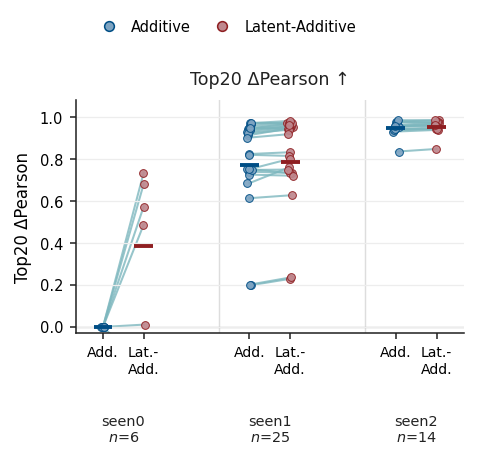

Saved:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD2_top20_delta_mse_additive_vs_latent_additive_nature_split.svg
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD2_top20_delta_mse_additive_vs_latent_additive_nature_split.pdf
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD2_top20_delta_mse_additive_vs_latent_additive_nature_split.png


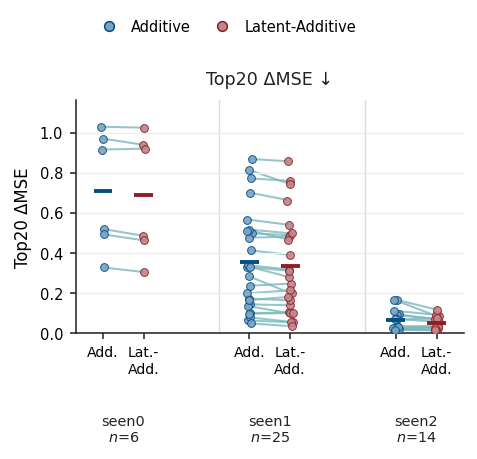

Saved:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD3_opposite_direction_additive_vs_latent_additive_nature_split.svg
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD3_opposite_direction_additive_vs_latent_additive_nature_split.pdf
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD3_opposite_direction_additive_vs_latent_additive_nature_split.png


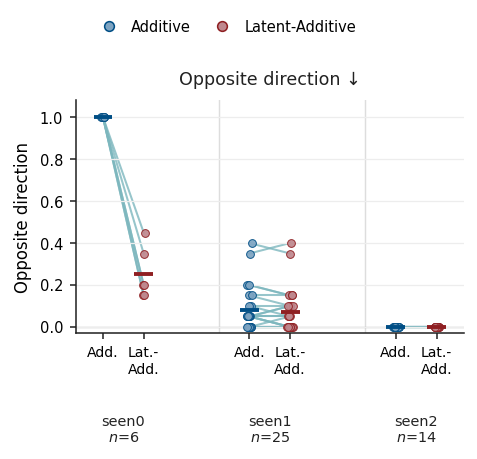

,group,n,add_top20_delta_pearson_mean,latent_top20_delta_pearson_mean,add_top20_delta_mse_mean,latent_top20_delta_mse_mean,add_opposite_direction_mean,latent_opposite_direction_mean
0,seen0,6,0.000000,0.384293,0.709646,0.689770,1.00,0.250
1,seen1,25,0.769907,0.784112,0.354674,0.335741,0.08,0.072
2,seen2,14,0.949069,0.955008,0.067413,0.052622,0.00,0.000


Saved summary:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figD_additive_vs_latent_additive_summary_split.csv


In [4]:
# ============================================================
# Nature-style paired plots (three separate figures)
# Additive vs Latent-Additive
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# 0. Paths
# ------------------------------------------------------------
BASE = "/root/autodl-tmp/scERso/norman_combo_gears_style"
OUT_DIR = f"{BASE}/figures/gears_style_residual_diffusion_seed1"
os.makedirs(OUT_DIR, exist_ok=True)

COMBO_METRICS_CSV = f"{OUT_DIR}/figB_per_combo_improvement_metrics.csv"
combo_metrics = pd.read_csv(COMBO_METRICS_CSV)

combo_metrics = combo_metrics[
    combo_metrics["subgroup"].isin(["combo_seen0", "combo_seen1", "combo_seen2"])
].copy()

# ------------------------------------------------------------
# 1. Strict color palette
# ------------------------------------------------------------
COLOR_PAIRS = {
    "rose": {
        "dark": "#8F1F22",
        "light": "#BF888E",
    },
    "blue": {
        "dark": "#004E85",
        "light": "#7EA4C2",
    },
    "teal": {
        "dark": "#107A83",
        "light": "#7DB7BE",
    },
}

METHOD_STYLE = {
    "Additive": {
        "face": COLOR_PAIRS["blue"]["light"],
        "edge": COLOR_PAIRS["blue"]["dark"],
        "mean": COLOR_PAIRS["blue"]["dark"],
    },
    "Latent-Additive": {
        "face": COLOR_PAIRS["rose"]["light"],
        "edge": COLOR_PAIRS["rose"]["dark"],
        "mean": COLOR_PAIRS["rose"]["dark"],
    },
}

PAIR_LINE_COLOR = COLOR_PAIRS["teal"]["light"]
TEXT_COLOR = "#222222"
GRID_COLOR = "#EDEDED"
SEP_COLOR = "#DDDDDD"

GROUP_ORDER = ["combo_seen0", "combo_seen1", "combo_seen2"]
GROUP_LABELS = {
    "combo_seen0": "seen0",
    "combo_seen1": "seen1",
    "combo_seen2": "seen2",
}

# ------------------------------------------------------------
# 2. Matplotlib style
# ------------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8.5,
    "xtick.labelsize": 7.2,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 7.5,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# ------------------------------------------------------------
# 3. Helpers
# ------------------------------------------------------------
def nice_ylim(values, fixed=None, lower_zero=True, pad_ratio=0.12):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if fixed is not None:
        return fixed

    y_min = np.min(values)
    y_max = np.max(values)
    pad = pad_ratio * (y_max - y_min + 1e-8)

    if lower_zero:
        y_min = max(0, y_min - pad)
    else:
        y_min = y_min - pad

    y_max = y_max + pad
    return y_min, y_max


def add_group_labels(ax, group_positions, y_offset=-0.34):
    for group, center in group_positions:
        n = len(combo_metrics[combo_metrics["subgroup"] == group])
        ax.text(
            center,
            y_offset,
            f"{GROUP_LABELS[group]}\n$n$={n}",
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=7.4,
            color=TEXT_COLOR,
        )


def add_method_legend(fig, y=1.02):
    handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            markersize=5.0,
            markerfacecolor=METHOD_STYLE["Additive"]["face"],
            markeredgecolor=METHOD_STYLE["Additive"]["edge"],
            markeredgewidth=0.8,
            label="Additive",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            markersize=5.0,
            markerfacecolor=METHOD_STYLE["Latent-Additive"]["face"],
            markeredgecolor=METHOD_STYLE["Latent-Additive"]["edge"],
            markeredgewidth=0.8,
            label="Latent-Additive",
        ),
    ]

    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, y),
        ncol=2,
        frameon=False,
        handletextpad=0.5,
        columnspacing=1.2,
    )


def save_figure(fig, prefix):
    svg_path = os.path.join(OUT_DIR, f"{prefix}.svg")
    pdf_path = os.path.join(OUT_DIR, f"{prefix}.pdf")
    png_path = os.path.join(OUT_DIR, f"{prefix}.png")

    fig.savefig(svg_path, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")

    print("Saved:")
    print(svg_path)
    print(pdf_path)
    print(png_path)


def plot_single_metric_figure(spec, panel_label=None, save_prefix=None):
    fig, ax = plt.subplots(figsize=(3.55, 3.20))

    x_positions = []
    x_labels = []
    group_positions = []

    # Collect all values for automatic axis limits
    all_vals = []
    for group in GROUP_ORDER:
        sub = combo_metrics[combo_metrics["subgroup"] == group]
        all_vals.extend(sub[spec["add_col"]].values)
        all_vals.extend(sub[spec["latent_col"]].values)

    y_min, y_max = nice_ylim(
        all_vals,
        fixed=spec.get("ylim", None),
        lower_zero=spec.get("lower_zero", True),
        pad_ratio=0.13,
    )
    ax.set_ylim(y_min, y_max)

    group_gap = 2.95
    method_gap = 0.82

    for gi, group in enumerate(GROUP_ORDER):
        sub = combo_metrics[combo_metrics["subgroup"] == group].copy()

        x_add = gi * group_gap
        x_lat = x_add + method_gap
        x_center = (x_add + x_lat) / 2

        group_positions.append((group, x_center))
        x_positions.extend([x_add, x_lat])
        x_labels.extend(["Add.", "Lat.-\nAdd."])

        add_vals = sub[spec["add_col"]].values
        lat_vals = sub[spec["latent_col"]].values

        # Use clearer paired connecting lines
        for a, l in zip(add_vals, lat_vals):
            ax.plot(
                [x_add, x_lat],
                [a, l],
                color=PAIR_LINE_COLOR,
                alpha=0.8,
                linewidth=1.05,
                zorder=1,
            )

        rng_add = np.random.default_rng(100 + gi)
        rng_lat = np.random.default_rng(200 + gi)

        jitter_add = rng_add.normal(0, 0.028, size=len(add_vals))
        jitter_lat = rng_lat.normal(0, 0.028, size=len(lat_vals))

        # Use slightly smaller points
        ax.scatter(
            np.full(len(add_vals), x_add) + jitter_add,
            add_vals,
            s=16,
            facecolor=METHOD_STYLE["Additive"]["face"],
            edgecolor=METHOD_STYLE["Additive"]["edge"],
            linewidth=0.5,
            alpha=0.92,
            zorder=3,
        )

        ax.scatter(
            np.full(len(lat_vals), x_lat) + jitter_lat,
            lat_vals,
            s=16,
            facecolor=METHOD_STYLE["Latent-Additive"]["face"],
            edgecolor=METHOD_STYLE["Latent-Additive"]["edge"],
            linewidth=0.5,
            alpha=0.92,
            zorder=3,
        )

        # Mark the mean with a short horizontal line
        mean_add = np.mean(add_vals)
        mean_lat = np.mean(lat_vals)

        ax.hlines(
            mean_add,
            x_add - 0.19, x_add + 0.19,
            color=METHOD_STYLE["Additive"]["mean"],
            linewidth=2.0,
            zorder=5
        )
        ax.hlines(
            mean_lat,
            x_lat - 0.19, x_lat + 0.19,
            color=METHOD_STYLE["Latent-Additive"]["mean"],
            linewidth=2.0,
            zorder=5
        )

    # Add separators between seen groups
    for gi in range(1, len(GROUP_ORDER)):
        sep_x = gi * group_gap - 0.62
        ax.axvline(sep_x, color=SEP_COLOR, linewidth=0.75, zorder=0)

    ax.axhline(0, color="#BFBFBF", linewidth=0.7, zorder=0)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels)
    add_group_labels(ax, group_positions, y_offset=-0.35)

    ax.set_ylabel(spec["ylabel"])
    ax.set_title(spec["title"], pad=8, color=TEXT_COLOR)

    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.65)
    ax.grid(axis="x", visible=False)

    ax.tick_params(axis="both", length=3.0, color=TEXT_COLOR)
    ax.spines["left"].set_color(TEXT_COLOR)
    ax.spines["bottom"].set_color(TEXT_COLOR)

    if panel_label is not None:
        ax.text(
            -0.16, 1.08, panel_label,
            transform=ax.transAxes,
            ha="left", va="bottom",
            fontsize=10, fontweight="bold", color=TEXT_COLOR
        )

    add_method_legend(fig, y=1.03)

    fig.subplots_adjust(
        left=0.20,
        right=0.98,
        bottom=0.30,
        top=0.82,
    )

    if save_prefix is not None:
        save_figure(fig, save_prefix)

    plt.show()


# ------------------------------------------------------------
# 4. Plot three separate figures
# ------------------------------------------------------------
metric_specs = [
    {
        "add_col": "add_top20_delta_pearson",
        "latent_col": "corr_top20_delta_pearson",
        "ylabel": "Top20 ΔPearson",
        "title": "Top20 ΔPearson ↑",
        "ylim": (-0.03, 1.08),
        "lower_zero": False,
        "save": "figD1_top20_delta_pearson_additive_vs_latent_additive_nature_split",
    },
    {
        "add_col": "add_top20_delta_mse",
        "latent_col": "corr_top20_delta_mse",
        "ylabel": "Top20 ΔMSE",
        "title": "Top20 ΔMSE ↓",
        "ylim": None,
        "lower_zero": True,
        "save": "figD2_top20_delta_mse_additive_vs_latent_additive_nature_split",
    },
    {
        "add_col": "add_opposite_direction",
        "latent_col": "corr_opposite_direction",
        "ylabel": "Opposite direction",
        "title": "Opposite direction ↓",
        "ylim": (-0.03, 1.08),
        "lower_zero": False,
        "save": "figD3_opposite_direction_additive_vs_latent_additive_nature_split",
    },
]

for spec in metric_specs:
    plot_single_metric_figure(
        spec=spec,
        save_prefix=spec["save"]
    )


# ------------------------------------------------------------
# 5. summary
# ------------------------------------------------------------
summary_rows = []

for group in GROUP_ORDER:
    sub = combo_metrics[combo_metrics["subgroup"] == group].copy()

    summary_rows.append({
        "group": GROUP_LABELS[group],
        "n": len(sub),

        "add_top20_delta_pearson_mean": sub["add_top20_delta_pearson"].mean(),
        "latent_top20_delta_pearson_mean": sub["corr_top20_delta_pearson"].mean(),

        "add_top20_delta_mse_mean": sub["add_top20_delta_mse"].mean(),
        "latent_top20_delta_mse_mean": sub["corr_top20_delta_mse"].mean(),

        "add_opposite_direction_mean": sub["add_opposite_direction"].mean(),
        "latent_opposite_direction_mean": sub["corr_opposite_direction"].mean(),
    })

summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(
    OUT_DIR,
    "figD_additive_vs_latent_additive_summary_split.csv"
)
summary_df.to_csv(summary_path, index=False)

display(summary_df)
print("Saved summary:")
print(summary_path)

NPZ keys:
['true_delta', 'additive_delta', 'corrected_delta', 'pred_residual', 'perturbation', 'perturb_type', 'gears_test_subgroup', 'gears_seen_type', 'n_available_single', 'var_names']

Using keys:
perturbation: perturbation
true_delta: true_delta
additive_delta: additive_delta
corrected_delta: corrected_delta
seen_key: gears_seen_type

Raw seen labels:
unseen_single    37
combo_seen1      25
combo_seen2      14
combo_seen0       6
Name: count, dtype: int64

Normalized seen labels:
unknown    37
seen1      25
seen2      14
seen0       6
Name: count, dtype: int64

Candidate number by seen group:
seen
seen1    25
seen2    14
seen0     6
Name: count, dtype: int64

Saved all ranked candidates:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_seen012_three_separate_figures/all_seen012_candidates_ranked_by_latent_additive_gain.csv

Both-improved candidate number by seen group:
seen
seen1    18
seen2     9
seen0     4
Name: count, dtype

,idx,perturbation_raw,perturbation,seen,additive_top20_r,additive_top20_mse,latent_additive_top20_r,latent_additive_top20_mse,delta_r_latent_minus_add,delta_mse_add_minus_latent,mean_abs_top20_shift,selection_score,selection_note
0,35,FOXF1+FOXL2,FOXF1+FOXL2,seen0,0.000000,0.519883,0.734885,0.485793,0.734885,0.034090,0.029551,0.762158,both_r_and_mse_improved
1,78,ZBTB10+DLX2,ZBTB10+DLX2,seen1,0.751501,0.813674,0.801446,0.743754,0.049945,0.069920,0.046684,0.105881,both_r_and_mse_improved
2,12,CEBPE+CEBPB,CEBPE+CEBPB,seen2,0.978896,0.163456,0.984382,0.085927,0.005486,0.077529,0.100636,0.067509,both_r_and_mse_improved



Saved selected summary:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_seen012_three_separate_figures/selected_seen012_three_separate_figures_summary.csv
Saved SVG: /root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_seen012_three_separate_figures/FOXF1_plus_FOXL2_seen0_additive_vs_latent_additive.svg
Saved PNG: /root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_seen012_three_separate_figures/FOXF1_plus_FOXL2_seen0_additive_vs_latent_additive.png


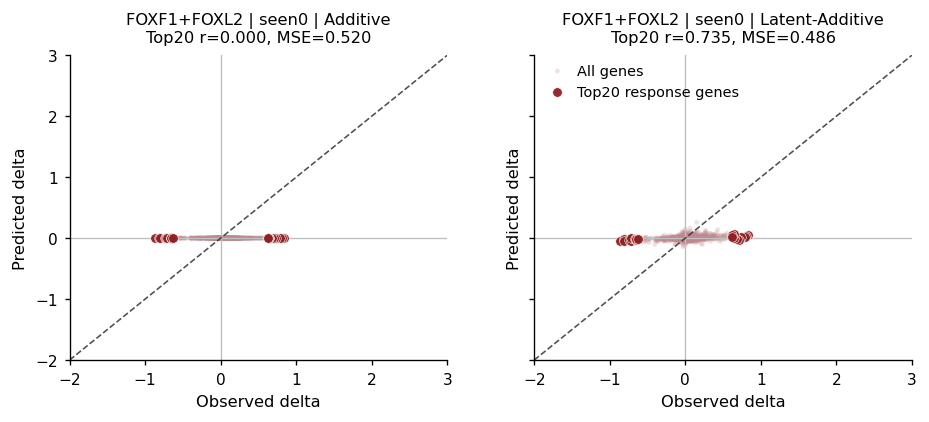

Saved SVG: /root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_seen012_three_separate_figures/ZBTB10_plus_DLX2_seen1_additive_vs_latent_additive.svg
Saved PNG: /root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_seen012_three_separate_figures/ZBTB10_plus_DLX2_seen1_additive_vs_latent_additive.png


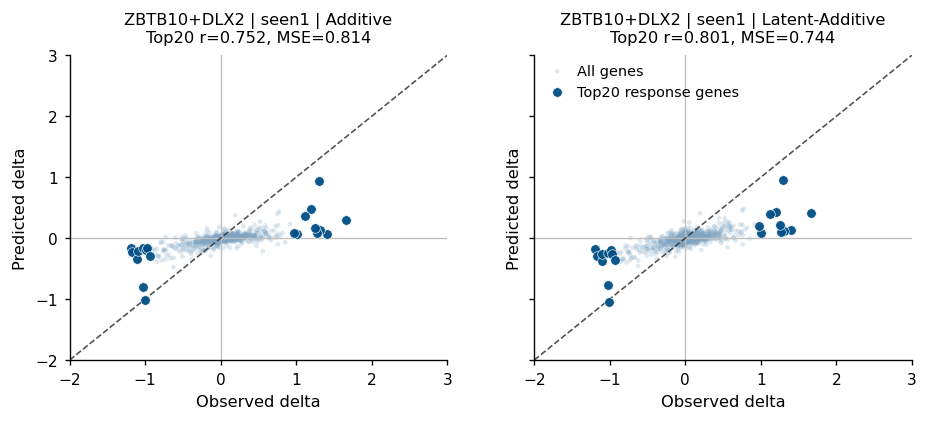

Saved SVG: /root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_seen012_three_separate_figures/CEBPE_plus_CEBPB_seen2_additive_vs_latent_additive.svg
Saved PNG: /root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_seen012_three_separate_figures/CEBPE_plus_CEBPB_seen2_additive_vs_latent_additive.png


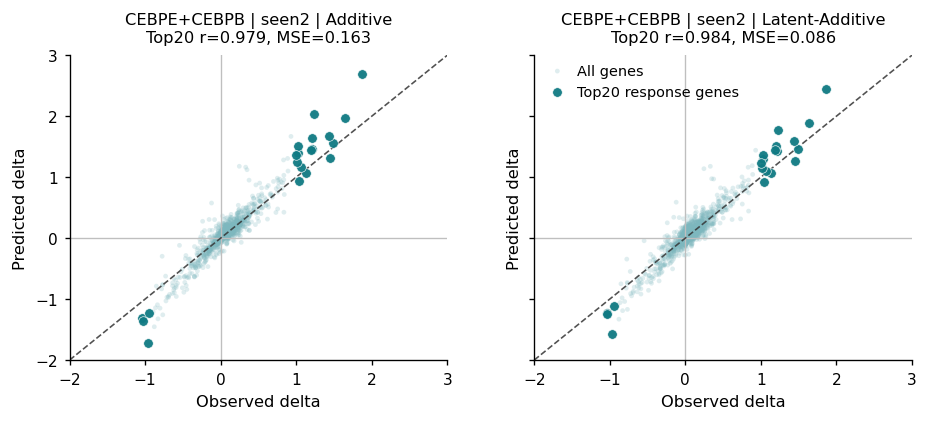


Saved final figure summary:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_seen012_three_separate_figures/three_separate_figures_final_summary.csv


,idx,perturbation,seen,color_dark,color_light,additive_top20_r,additive_top20_mse,latent_additive_top20_r,latent_additive_top20_mse,delta_r_latent_minus_add,delta_mse_add_minus_latent,svg_path,png_path
0,35,FOXF1+FOXL2,seen0,#8F1F22,#BF888E,0.000000,0.519883,0.734885,0.485793,0.734885,0.034090,/root/autodl-tmp/scERso/norman_combo_gears_sty...,/root/autodl-tmp/scERso/norman_combo_gears_sty...
1,78,ZBTB10+DLX2,seen1,#004E85,#7EA4C2,0.751501,0.813674,0.801446,0.743754,0.049945,0.069920,/root/autodl-tmp/scERso/norman_combo_gears_sty...,/root/autodl-tmp/scERso/norman_combo_gears_sty...
2,12,CEBPE+CEBPB,seen2,#107A83,#7DB7BE,0.978896,0.163456,0.984382,0.085927,0.005486,0.077529,/root/autodl-tmp/scERso/norman_combo_gears_sty...,/root/autodl-tmp/scERso/norman_combo_gears_sty...


In [10]:
# =========================================================
# Auto-select one perturbation from each seen group:
# seen0 / seen1 / seen2
#
# Output:
#   - 3 separate figures
#   - each figure contains 2 panels:
#       Additive vs Latent-Additive
#
# Save:
#   - SVG
#   - PNG
#
# Strictly use the provided color pairs:
# seen0 -> rose
# seen1 -> blue
# seen2 -> teal
# =========================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# -----------------------------
# paths
# -----------------------------
PRED_NPZ = "/root/autodl-tmp/scERso/norman_combo_gears_style/checkpoints/gears_style_residual_diffusion_seed1/test_predictions_gears_style_residual.npz"

OUT_DIR = "/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_seen012_three_separate_figures"
os.makedirs(OUT_DIR, exist_ok=True)

# -----------------------------
# parameters
# -----------------------------
TOPK = 20
MAX_BG_POINTS = 5000
RANDOM_SEED = 42

AXIS_MIN = -2
AXIS_MAX = 3

# Parameters for automatically selecting cases with clearer differences
R_WEIGHT = 1.0
MSE_WEIGHT = 0.8

# -----------------------------
# strict color pairs
# -----------------------------
COLOR_PAIRS = {
    "seen0": {"dark": "#8F1F22", "light": "#BF888E"},  # rose
    "seen1": {"dark": "#004E85", "light": "#7EA4C2"},  # blue
    "seen2": {"dark": "#107A83", "light": "#7DB7BE"},  # teal
}

# -----------------------------
# helpers
# -----------------------------
def find_key(npz, candidates, name):
    keys = list(npz.files)
    for k in candidates:
        if k in keys:
            return k
    raise KeyError(
        f"Cannot find {name}. Tried {candidates}. Available keys are:\n{keys}"
    )


def find_optional_key(npz, candidates):
    keys = list(npz.files)
    for k in candidates:
        if k in keys:
            return k
    return None


def safe_pearson(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    if len(x) < 2:
        return np.nan

    if np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return 0.0

    return float(pearsonr(x, y)[0])


def mse(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    return float(np.mean((x - y) ** 2))


def safe_filename(name):
    return re.sub(r"[^A-Za-z0-9_.+-]+", "_", str(name)).replace("+", "_plus_")


def clean_pert_name(pert_name):
    return str(pert_name).split("|")[0].strip()


def normalize_seen_label(x):
    """
    Normalize labels such as:
    seen0, seen1, seen2
    combo_seen0, combo_seen1, combo_seen2
    seen_0, seen-1
    """
    x = str(x)
    m = re.search(r"seen[_-]?([0-2])", x)
    if m:
        return f"seen{m.group(1)}"
    return "unknown"


def compute_one_case_metrics(obs, pred_add, pred_corr, topk=20):
    obs = np.asarray(obs).astype(float)
    pred_add = np.asarray(pred_add).astype(float)
    pred_corr = np.asarray(pred_corr).astype(float)

    valid = np.isfinite(obs) & np.isfinite(pred_add) & np.isfinite(pred_corr)
    obs = obs[valid]
    pred_add = pred_add[valid]
    pred_corr = pred_corr[valid]

    if len(obs) < topk:
        return None

    top_idx = np.argsort(np.abs(obs))[-topk:]
    top_idx = top_idx[np.argsort(-np.abs(obs[top_idx]))]

    add_r = safe_pearson(obs[top_idx], pred_add[top_idx])
    add_mse = mse(obs[top_idx], pred_add[top_idx])

    latent_r = safe_pearson(obs[top_idx], pred_corr[top_idx])
    latent_mse = mse(obs[top_idx], pred_corr[top_idx])

    delta_r = latent_r - add_r
    delta_mse = add_mse - latent_mse  # >0 means Latent-Additive better

    mean_abs_shift = float(np.mean(np.abs(pred_corr[top_idx] - pred_add[top_idx])))

    selection_score = R_WEIGHT * delta_r + MSE_WEIGHT * delta_mse

    return {
        "obs": obs,
        "pred_add": pred_add,
        "pred_corr": pred_corr,
        "top_idx": top_idx,
        "additive_top20_r": add_r,
        "additive_top20_mse": add_mse,
        "latent_additive_top20_r": latent_r,
        "latent_additive_top20_mse": latent_mse,
        "delta_r_latent_minus_add": delta_r,
        "delta_mse_add_minus_latent": delta_mse,
        "mean_abs_top20_shift": mean_abs_shift,
        "selection_score": selection_score,
    }


def plot_single_panel(
    ax,
    obs,
    pred,
    top_idx,
    pert,
    seen,
    model_name,
    colors,
    bg_idx=None,
    show_legend=False
):
    """
    colors = {"dark": ..., "light": ...}
    strict usage:
      - all genes -> light
      - top20 genes -> dark
    """
    if bg_idx is None:
        bg_idx = np.arange(len(obs))

    top_r = safe_pearson(obs[top_idx], pred[top_idx])
    top_mse = mse(obs[top_idx], pred[top_idx])

    # all genes
    ax.scatter(
        obs[bg_idx],
        pred[bg_idx],
        s=7,
        alpha=0.24,
        color=colors["light"],
        edgecolors="none",
        label="All genes",
        rasterized=True
    )

    # top20 response genes
    ax.scatter(
        obs[top_idx],
        pred[top_idx],
        s=28,
        alpha=0.95,
        color=colors["dark"],
        edgecolors="white",
        linewidths=0.35,
        label="Top20 response genes",
        zorder=5
    )

    # zero lines
    ax.axhline(0, color="0.75", linewidth=0.75, zorder=1)
    ax.axvline(0, color="0.75", linewidth=0.75, zorder=1)

    # diagonal
    ax.plot(
        [AXIS_MIN, AXIS_MAX],
        [AXIS_MIN, AXIS_MAX],
        linestyle="--",
        color="0.20",
        linewidth=0.9,
        alpha=0.85,
        zorder=2
    )

    ax.set_xlim(AXIS_MIN, AXIS_MAX)
    ax.set_ylim(AXIS_MIN, AXIS_MAX)
    ax.set_xticks(np.arange(AXIS_MIN, AXIS_MAX + 1, 1))
    ax.set_yticks(np.arange(AXIS_MIN, AXIS_MAX + 1, 1))

    ax.set_title(
        f"{pert} | {seen} | {model_name}\nTop20 r={top_r:.3f}, MSE={top_mse:.3f}",
        fontsize=9,
        fontweight="normal",
        pad=7
    )

    ax.set_xlabel("Observed delta", fontsize=9)
    ax.set_ylabel("Predicted delta", fontsize=9)

    ax.tick_params(axis="both", labelsize=8.5, length=3, width=0.75)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.75)
    ax.spines["bottom"].set_linewidth(0.75)

    if show_legend:
        ax.legend(
            frameon=False,
            loc="upper left",
            fontsize=8,
            handletextpad=0.35,
            borderaxespad=0.2
        )

    return {
        "top20_r": top_r,
        "top20_mse": top_mse,
    }


# -----------------------------
# plotting style
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 600,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 8.5,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "axes.titleweight": "normal",
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 8,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

rng = np.random.default_rng(RANDOM_SEED)

# -----------------------------
# load npz
# -----------------------------
npz = np.load(PRED_NPZ, allow_pickle=True)

print("NPZ keys:")
print(npz.files)

pert_key = find_key(
    npz,
    ["perturbation", "perturbations", "condition", "conditions"],
    "perturbation names"
)

true_key = find_key(
    npz,
    ["true_delta", "obs_delta", "observed_delta", "y_delta", "delta_true"],
    "true delta"
)

add_key = find_key(
    npz,
    [
        "additive_delta",
        "pred_delta_additive",
        "additive_pred_delta",
        "source_delta",
        "base_delta",
        "mean_delta",
        "pred_delta"
    ],
    "additive delta"
)

corr_key = find_key(
    npz,
    [
        "corrected_delta",
        "residual_corrected_delta",
        "pred_delta_corrected",
        "non_additive_delta",
        "nonadditive_delta",
        "final_delta"
    ],
    "latent-additive / corrected delta"
)

seen_key = find_optional_key(
    npz,
    [
        "gears_seen_type",
        "gears_test_subgroup",
        "seen",
        "split",
        "group",
        "seen_group",
        "perturbation_group",
        "perturb_type"
    ]
)

if seen_key is None:
    raise ValueError(
        "Cannot find seen group key. "
        "Expected one of: gears_seen_type / gears_test_subgroup / seen ..."
    )

perturbations = np.asarray(npz[pert_key]).astype(str)
true_delta = np.asarray(npz[true_key])
additive_delta = np.asarray(npz[add_key])
corrected_delta = np.asarray(npz[corr_key])

raw_seen_labels = np.asarray(npz[seen_key]).astype(str)
seen_labels = np.array([normalize_seen_label(x) for x in raw_seen_labels])

print("\nUsing keys:")
print("perturbation:", pert_key)
print("true_delta:", true_key)
print("additive_delta:", add_key)
print("corrected_delta:", corr_key)
print("seen_key:", seen_key)

print("\nRaw seen labels:")
print(pd.Series(raw_seen_labels).value_counts())

print("\nNormalized seen labels:")
print(pd.Series(seen_labels).value_counts())

# -----------------------------
# scan all perturbations
# -----------------------------
rows = []

for idx in range(len(perturbations)):
    pert_raw = perturbations[idx]
    pert_clean = clean_pert_name(pert_raw)
    seen = seen_labels[idx]

    if seen not in {"seen0", "seen1", "seen2"}:
        continue

    obs = true_delta[idx].astype(float)
    pred_add = additive_delta[idx].astype(float)
    pred_corr = corrected_delta[idx].astype(float)

    res = compute_one_case_metrics(obs, pred_add, pred_corr, topk=TOPK)
    if res is None:
        continue

    rows.append({
        "idx": idx,
        "perturbation_raw": pert_raw,
        "perturbation": pert_clean,
        "seen": seen,
        "additive_top20_r": res["additive_top20_r"],
        "additive_top20_mse": res["additive_top20_mse"],
        "latent_additive_top20_r": res["latent_additive_top20_r"],
        "latent_additive_top20_mse": res["latent_additive_top20_mse"],
        "delta_r_latent_minus_add": res["delta_r_latent_minus_add"],
        "delta_mse_add_minus_latent": res["delta_mse_add_minus_latent"],
        "mean_abs_top20_shift": res["mean_abs_top20_shift"],
        "selection_score": res["selection_score"],
    })

all_df = pd.DataFrame(rows)

if len(all_df) == 0:
    raise ValueError("No valid seen0 / seen1 / seen2 perturbations found.")

print("\nCandidate number by seen group:")
print(all_df["seen"].value_counts())

# Save all candidate cases
all_ranked_df = all_df.sort_values(
    ["seen", "selection_score", "delta_r_latent_minus_add", "delta_mse_add_minus_latent"],
    ascending=[True, False, False, False]
).reset_index(drop=True)

all_csv = os.path.join(
    OUT_DIR,
    "all_seen012_candidates_ranked_by_latent_additive_gain.csv"
)
all_ranked_df.to_csv(all_csv, index=False)

print("\nSaved all ranked candidates:")
print(all_csv)

# -----------------------------
# prefer cases where both metrics improve
# -----------------------------
both_better_df = all_df[
    (all_df["delta_r_latent_minus_add"] > 0) &
    (all_df["delta_mse_add_minus_latent"] > 0)
].copy()

print("\nBoth-improved candidate number by seen group:")
if len(both_better_df) > 0:
    print(both_better_df["seen"].value_counts())
else:
    print("No both-improved candidates found. Will use fallback largest-score examples.")

selected_rows = []

for seen in ["seen0", "seen1", "seen2"]:
    sub_better = both_better_df[both_better_df["seen"] == seen].copy()

    if len(sub_better) > 0:
        sub = sub_better
        selection_note = "both_r_and_mse_improved"
    else:
        sub = all_df[all_df["seen"] == seen].copy()
        selection_note = "fallback_largest_score"

    if len(sub) == 0:
        raise ValueError(f"No candidate found for {seen}.")

    best = (
        sub.sort_values(
            [
                "selection_score",
                "delta_r_latent_minus_add",
                "delta_mse_add_minus_latent",
                "mean_abs_top20_shift"
            ],
            ascending=[False, False, False, False]
        )
        .head(1)
        .copy()
    )

    best["selection_note"] = selection_note
    selected_rows.append(best)

selected_df = pd.concat(selected_rows, axis=0).reset_index(drop=True)

selected_df["seen"] = pd.Categorical(
    selected_df["seen"],
    categories=["seen0", "seen1", "seen2"],
    ordered=True
)
selected_df = selected_df.sort_values("seen").reset_index(drop=True)

print("\nSelected examples:")
try:
    display(selected_df)
except NameError:
    print(selected_df)

selected_csv = os.path.join(
    OUT_DIR,
    "selected_seen012_three_separate_figures_summary.csv"
)
selected_df.to_csv(selected_csv, index=False)

print("\nSaved selected summary:")
print(selected_csv)

# -----------------------------
# plot: three separate figures
# -----------------------------
figure_summary_rows = []

for _, row in selected_df.iterrows():
    idx = int(row["idx"])
    pert = row["perturbation"]
    seen = str(row["seen"])
    colors = COLOR_PAIRS[seen]

    obs = true_delta[idx].astype(float)
    pred_add = additive_delta[idx].astype(float)
    pred_corr = corrected_delta[idx].astype(float)

    valid = np.isfinite(obs) & np.isfinite(pred_add) & np.isfinite(pred_corr)
    obs = obs[valid]
    pred_add = pred_add[valid]
    pred_corr = pred_corr[valid]

    top_idx = np.argsort(np.abs(obs))[-TOPK:]
    top_idx = top_idx[np.argsort(-np.abs(obs[top_idx]))]

    all_idx = np.arange(len(obs))
    if len(all_idx) > MAX_BG_POINTS:
        bg_idx = rng.choice(all_idx, size=MAX_BG_POINTS, replace=False)
    else:
        bg_idx = all_idx

    fig, axes = plt.subplots(
        1, 2,
        figsize=(7.2, 3.35),
        sharex=True,
        sharey=True
    )

    # left: Additive
    res_add = plot_single_panel(
        ax=axes[0],
        obs=obs,
        pred=pred_add,
        top_idx=top_idx,
        pert=pert,
        seen=seen,
        model_name="Additive",
        colors=colors,
        bg_idx=bg_idx,
        show_legend=False
    )

    # right: Latent-Additive
    res_latent = plot_single_panel(
        ax=axes[1],
        obs=obs,
        pred=pred_corr,
        top_idx=top_idx,
        pert=pert,
        seen=seen,
        model_name="Latent-Additive",
        colors=colors,
        bg_idx=bg_idx,
        show_legend=True
    )

    fig.subplots_adjust(
        left=0.085,
        right=0.985,
        bottom=0.17,
        top=0.87,
        wspace=0.23
    )

    base_name = f"{safe_filename(pert)}_{seen}_additive_vs_latent_additive"

    out_svg = os.path.join(OUT_DIR, f"{base_name}.svg")
    out_png = os.path.join(OUT_DIR, f"{base_name}.png")

    fig.savefig(out_svg, bbox_inches="tight")
    fig.savefig(out_png, bbox_inches="tight")

    print("Saved SVG:", out_svg)
    print("Saved PNG:", out_png)

    plt.show()

    figure_summary_rows.append({
        "idx": idx,
        "perturbation": pert,
        "seen": seen,
        "color_dark": colors["dark"],
        "color_light": colors["light"],
        "additive_top20_r": res_add["top20_r"],
        "additive_top20_mse": res_add["top20_mse"],
        "latent_additive_top20_r": res_latent["top20_r"],
        "latent_additive_top20_mse": res_latent["top20_mse"],
        "delta_r_latent_minus_add": res_latent["top20_r"] - res_add["top20_r"],
        "delta_mse_add_minus_latent": res_add["top20_mse"] - res_latent["top20_mse"],
        "svg_path": out_svg,
        "png_path": out_png,
    })

# -----------------------------
# save final figure summary
# -----------------------------
figure_summary_df = pd.DataFrame(figure_summary_rows)

figure_summary_csv = os.path.join(
    OUT_DIR,
    "three_separate_figures_final_summary.csv"
)
figure_summary_df.to_csv(figure_summary_csv, index=False)

print("\nSaved final figure summary:")
print(figure_summary_csv)

try:
    display(figure_summary_df)
except NameError:
    print(figure_summary_df)

NPZ keys:
['true_delta', 'additive_delta', 'corrected_delta', 'pred_residual', 'perturbation', 'perturb_type', 'gears_test_subgroup', 'gears_seen_type', 'n_available_single', 'var_names']

Using keys:
perturbation: perturbation
true_delta: true_delta
additive_delta: additive_delta
corrected_delta: corrected_delta
pred_residual: pred_residual
var_names: var_names
seen_key: gears_seen_type

Mean abs corrected_delta_raw: 0.023739233714502168
Mean abs additive_plus_residual: 0.023739233710521297
Using corrected_delta as latent_delta.
latent_source: corrected_delta

Saved all candidate ranking:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figure2_top3_good_double_combo_heatmap/all_double_gene_candidates_ranked_good_prediction.csv

Top 15 candidates before filtering:


,idx,perturbation,perturbation_raw,seen_label,additive_top20_r,latent_top20_r,delta_r,additive_top20_mse,latent_top20_mse,delta_mse_add_minus_latent,true_mean_abs_top20,additive_mean_abs_top20,latent_mean_abs_top20,additive_std_top20,latent_std_top20,additive_nonzero_frac_top20,latent_nonzero_frac_top20,selection_score
0,12,CEBPE+CEBPB,CEBPE+CEBPB,combo_seen2,0.978896,0.984382,0.005486,0.163456,0.085927,0.077529,1.199840,1.506355,1.405940,1.234093,1.138746,1.00,1.00,3.057397
1,51,MAP2K6+IKZF3,MAP2K6+IKZF3,combo_seen2,0.985126,0.985087,-0.000039,0.030366,0.028488,0.001877,1.050652,1.098100,1.096120,0.958374,0.941255,1.00,1.00,2.819708
2,17,DUSP9+KLF1,DUSP9+KLF1,combo_seen2,0.955316,0.961847,0.006532,0.090532,0.071721,0.018811,1.143098,1.127091,1.127176,0.902131,0.875321,1.00,1.00,2.768920
3,21,ETS2+IKZF3,ETS2+IKZF3,combo_seen2,0.961496,0.973887,0.012391,0.070972,0.057930,0.013042,1.081215,1.033572,0.996027,0.825563,0.783969,1.00,1.00,2.701925
4,27,FOSB+OSR2,FOSB+OSR2,combo_seen2,0.974753,0.974244,-0.000509,0.035139,0.035934,-0.000795,0.886278,0.893671,0.907143,0.834727,0.839887,1.00,1.00,2.638268
5,65,SET+CEBPE,SET+CEBPE,combo_seen2,0.939331,0.952661,0.013330,0.167873,0.117844,0.050028,0.632334,0.873891,0.834943,0.945062,0.889880,1.00,1.00,2.493447
6,66,SET+KLF1,SET+KLF1,combo_seen2,0.945152,0.942044,-0.003107,0.068923,0.073609,-0.004686,0.809463,0.809320,0.799080,0.755531,0.749084,1.00,1.00,2.449744
7,19,DUSP9+PRTG,DUSP9+PRTG,combo_seen1,0.959579,0.968726,0.009147,0.144132,0.139742,0.004391,0.982701,0.694112,0.695441,0.728874,0.710597,1.00,1.00,2.362186
8,18,DUSP9+MAPK1,DUSP9+MAPK1,combo_seen2,0.937793,0.944090,0.006297,0.111394,0.091740,0.019655,0.449192,0.701453,0.684675,0.714352,0.689451,1.00,1.00,2.359751
9,22,ETS2+MAP7D1,ETS2+MAP7D1,combo_seen2,0.977025,0.975081,-0.001945,0.023424,0.027750,-0.004326,0.660140,0.551505,0.537942,0.504043,0.495333,1.00,1.00,2.352764



Good candidates after filtering: 33


,idx,perturbation,perturbation_raw,seen_label,additive_top20_r,latent_top20_r,delta_r,additive_top20_mse,latent_top20_mse,delta_mse_add_minus_latent,true_mean_abs_top20,additive_mean_abs_top20,latent_mean_abs_top20,additive_std_top20,latent_std_top20,additive_nonzero_frac_top20,latent_nonzero_frac_top20,selection_score
0,12,CEBPE+CEBPB,CEBPE+CEBPB,combo_seen2,0.978896,0.984382,0.005486,0.163456,0.085927,0.077529,1.199840,1.506355,1.405940,1.234093,1.138746,1.0,1.0,3.057397
1,51,MAP2K6+IKZF3,MAP2K6+IKZF3,combo_seen2,0.985126,0.985087,-0.000039,0.030366,0.028488,0.001877,1.050652,1.098100,1.096120,0.958374,0.941255,1.0,1.0,2.819708
2,17,DUSP9+KLF1,DUSP9+KLF1,combo_seen2,0.955316,0.961847,0.006532,0.090532,0.071721,0.018811,1.143098,1.127091,1.127176,0.902131,0.875321,1.0,1.0,2.768920
3,21,ETS2+IKZF3,ETS2+IKZF3,combo_seen2,0.961496,0.973887,0.012391,0.070972,0.057930,0.013042,1.081215,1.033572,0.996027,0.825563,0.783969,1.0,1.0,2.701925
4,27,FOSB+OSR2,FOSB+OSR2,combo_seen2,0.974753,0.974244,-0.000509,0.035139,0.035934,-0.000795,0.886278,0.893671,0.907143,0.834727,0.839887,1.0,1.0,2.638268
5,65,SET+CEBPE,SET+CEBPE,combo_seen2,0.939331,0.952661,0.013330,0.167873,0.117844,0.050028,0.632334,0.873891,0.834943,0.945062,0.889880,1.0,1.0,2.493447
6,66,SET+KLF1,SET+KLF1,combo_seen2,0.945152,0.942044,-0.003107,0.068923,0.073609,-0.004686,0.809463,0.809320,0.799080,0.755531,0.749084,1.0,1.0,2.449744
7,19,DUSP9+PRTG,DUSP9+PRTG,combo_seen1,0.959579,0.968726,0.009147,0.144132,0.139742,0.004391,0.982701,0.694112,0.695441,0.728874,0.710597,1.0,1.0,2.362186
8,18,DUSP9+MAPK1,DUSP9+MAPK1,combo_seen2,0.937793,0.944090,0.006297,0.111394,0.091740,0.019655,0.449192,0.701453,0.684675,0.714352,0.689451,1.0,1.0,2.359751
9,22,ETS2+MAP7D1,ETS2+MAP7D1,combo_seen2,0.977025,0.975081,-0.001945,0.023424,0.027750,-0.004326,0.660140,0.551505,0.537942,0.504043,0.495333,1.0,1.0,2.352764



Selection mode: strict_good_prediction_filter

Selected top 3 good double-gene combinations:


,idx,perturbation,perturbation_raw,seen_label,additive_top20_r,latent_top20_r,delta_r,additive_top20_mse,latent_top20_mse,delta_mse_add_minus_latent,true_mean_abs_top20,additive_mean_abs_top20,latent_mean_abs_top20,additive_std_top20,latent_std_top20,additive_nonzero_frac_top20,latent_nonzero_frac_top20,selection_score
0,12,CEBPE+CEBPB,CEBPE+CEBPB,combo_seen2,0.978896,0.984382,0.005486,0.163456,0.085927,0.077529,1.199840,1.506355,1.405940,1.234093,1.138746,1.0,1.0,3.057397
1,51,MAP2K6+IKZF3,MAP2K6+IKZF3,combo_seen2,0.985126,0.985087,-0.000039,0.030366,0.028488,0.001877,1.050652,1.098100,1.096120,0.958374,0.941255,1.0,1.0,2.819708
2,17,DUSP9+KLF1,DUSP9+KLF1,combo_seen2,0.955316,0.961847,0.006532,0.090532,0.071721,0.018811,1.143098,1.127091,1.127176,0.902131,0.875321,1.0,1.0,2.768920



Saved selected combo summary:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figure2_top3_good_double_combo_heatmap/selected_top3_good_double_gene_combos.csv

Selected genes:
['HBZ', 'HBG2', 'HBG1', 'GYPB', 'HBA1', 'LST1', 'AIF1', 'VIM', 'HBA2', 'CFD', 'CEBPE', 'TYROBP', 'DUSP9']

Saved heatmap matrix:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figure2_top3_good_double_combo_heatmap/top3_good_double_combo_heatmap_matrix_unclipped.csv

Saved displayed-gene metrics:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figure2_top3_good_double_combo_heatmap/top3_good_double_combo_displayed_gene_metrics.csv


,perturbation,n_displayed_genes,additive_r_displayed_genes,latent_r_displayed_genes,delta_r_displayed_genes,additive_mse_displayed_genes,latent_mse_displayed_genes,delta_mse_add_minus_latent_displayed_genes,latent_source
0,CEBPE+CEBPB,13,0.986764,0.991589,0.004825,0.207276,0.114111,0.093165,corrected_delta
1,MAP2K6+IKZF3,13,0.995771,0.993660,-0.002111,0.016209,0.024537,-0.008328,corrected_delta
2,DUSP9+KLF1,13,0.966539,0.970599,0.004060,0.107431,0.087103,0.020328,corrected_delta



Saved SVG:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figure2_top3_good_double_combo_heatmap/top3_good_double_combo_heatmap_with_values_CEBPE_plus_CEBPB_MAP2K6_plus_IKZF3_DUSP9_plus_KLF1.svg
Saved PDF:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figure2_top3_good_double_combo_heatmap/top3_good_double_combo_heatmap_with_values_CEBPE_plus_CEBPB_MAP2K6_plus_IKZF3_DUSP9_plus_KLF1.pdf
Saved PNG:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figure2_top3_good_double_combo_heatmap/top3_good_double_combo_heatmap_with_values_CEBPE_plus_CEBPB_MAP2K6_plus_IKZF3_DUSP9_plus_KLF1.png


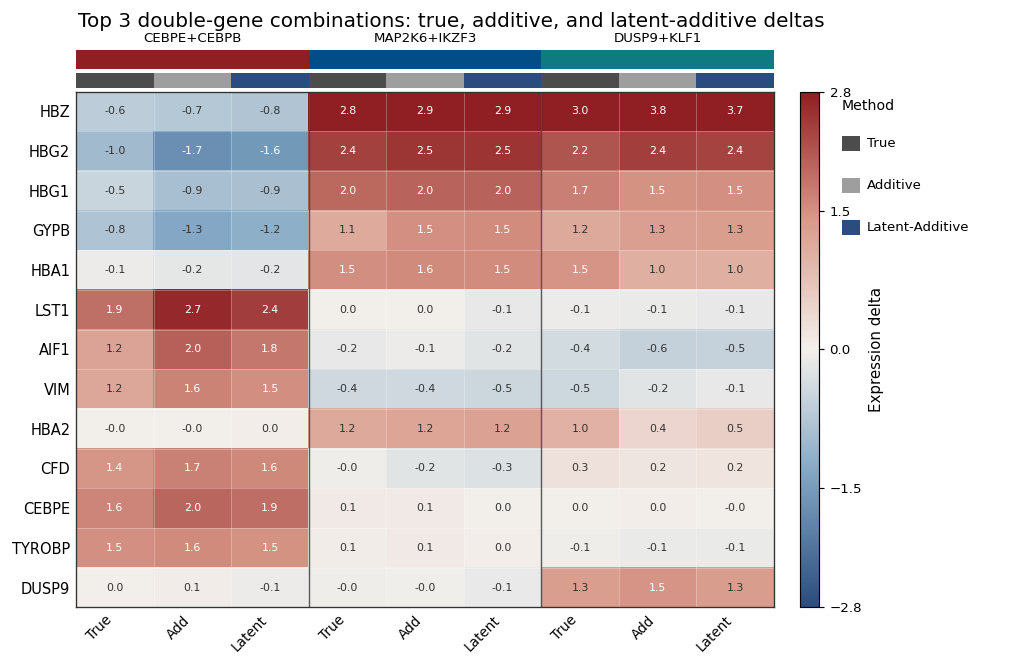

In [16]:
# =========================================================
# Auto-select top 3 GOOD double-gene perturbations
# and reproduce Figure 2 style heatmap:
#
# Main correction:
#   Do NOT select by improvement only.
#   Select by actual latent-additive performance:
#       high Top20 Pearson
#       low Top20 MSE
#       sufficient predicted signal
#       non-zero latent prediction
#
# Columns:
#   combo1: True / Additive / Latent
#   combo2: True / Additive / Latent
#   combo3: True / Additive / Latent
#
# Rows:
#   representative genes where true and latent both show signal
#
# Cell annotation:
#   each heatmap cell shows delta value
# =========================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.patches import Rectangle

# -----------------------------
# paths
# -----------------------------
PRED_NPZ = "/root/autodl-tmp/scERso/norman_combo_gears_style/checkpoints/gears_style_residual_diffusion_seed1/test_predictions_gears_style_residual.npz"

OUT_DIR = "/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figure2_top3_good_double_combo_heatmap"
os.makedirs(OUT_DIR, exist_ok=True)

# -----------------------------
# selection parameters
# -----------------------------
N_SELECT_COMBOS = 3
TOPK_FOR_SELECTION = 20

# Filter out cases with nearly all-zero predictions
MIN_LATENT_TOP20_R = 0.45
MAX_LATENT_TOP20_MSE = 0.80
MIN_LATENT_MEAN_ABS_TOP20 = 0.20
MIN_LATENT_STD_TOP20 = 0.08
MIN_LATENT_NONZERO_FRAC_TOP20 = 0.50

# Relax the filters automatically if fewer than three cases remain
ALLOW_FALLBACK = True

# Combination-selection score:
# Higher values are better
# Favor high latent correlation, low latent MSE, strong latent signal, and improvement over additive prediction
R_WEIGHT = 2.0
MSE_WEIGHT = 1.0
SIGNAL_WEIGHT = 0.8
GAIN_WEIGHT = 0.6

# -----------------------------
# heatmap gene-selection parameters
# -----------------------------
TOP_GENES_PER_COMBO = 6
MAX_GENES = 18

# heatmap display range
VMAX = 2.8
VMIN = -2.8

SAVE_PDF = True
SAVE_PNG = True

# -----------------------------
# cell value annotation
# -----------------------------
ANNOTATE_CELLS = True
ANNOTATION_FORMAT = "{:.1f}"
ANNOTATION_FONTSIZE = 6.6
ANNOTATION_ABS_WHITE_THRESHOLD = 1.35
MARK_CLIPPED_VALUES = False

# -----------------------------
# CNS-style heatmap colors
# -----------------------------
HEATMAP_COLORS = {
    "neg_dark": "#2B4C7E",
    "neg_mid":  "#7EA4C2",
    "center":   "#F3F0EC",
    "pos_mid":  "#D99A8A",
    "pos_dark": "#8F1F22",
}

COMBO_COLORS = [
    "#8F1F22",
    "#004E85",
    "#107A83",
]

METHOD_COLORS = {
    "True": "#4C4C4C",
    "Additive": "#9E9E9E",
    "Latent-Additive": "#2B4C7E",
}

# -----------------------------
# helpers
# -----------------------------
def find_key(npz, candidates, name):
    keys = list(npz.files)
    for k in candidates:
        if k in keys:
            return k

    raise KeyError(
        f"Cannot find {name}. Tried {candidates}. Available keys are:\n{keys}"
    )


def find_optional_key(npz, candidates):
    keys = list(npz.files)
    for k in candidates:
        if k in keys:
            return k
    return None


def safe_filename(name):
    return re.sub(r"[^A-Za-z0-9_.+-]+", "_", str(name)).replace("+", "_plus_")


def clean_pert_name(pert_name):
    return str(pert_name).split("|")[0].strip()


def is_double_gene_combo(pert_name):
    p = clean_pert_name(pert_name)

    if "+" not in p:
        return False

    parts = [x.strip() for x in p.split("+")]

    if len(parts) != 2:
        return False

    if any(x == "" for x in parts):
        return False

    bad_tokens = {"ctrl", "control", "non-targeting", "ntc"}

    if any(x.lower() in bad_tokens for x in parts):
        return False

    return True


def safe_pearson(a, b, eps=1e-8):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    valid = np.isfinite(a) & np.isfinite(b)
    a = a[valid]
    b = b[valid]

    if len(a) < 2:
        return np.nan

    if np.std(a) < eps or np.std(b) < eps:
        return 0.0

    a = a - a.mean()
    b = b - b.mean()

    den = np.sqrt((a * a).sum()) * np.sqrt((b * b).sum()) + eps
    return float((a * b).sum() / den)


def mse_np(a, b):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    valid = np.isfinite(a) & np.isfinite(b)

    if valid.sum() == 0:
        return np.nan

    return float(np.mean((a[valid] - b[valid]) ** 2))


def build_cns_diverging_cmap():
    cmap = LinearSegmentedColormap.from_list(
        "cns_blue_white_red",
        [
            HEATMAP_COLORS["neg_dark"],
            HEATMAP_COLORS["neg_mid"],
            HEATMAP_COLORS["center"],
            HEATMAP_COLORS["pos_mid"],
            HEATMAP_COLORS["pos_dark"],
        ],
        N=256
    )
    return cmap


def compute_top20_selection_metrics(obs, pred_add, pred_latent, topk=20):
    obs = np.asarray(obs, dtype=float)
    pred_add = np.asarray(pred_add, dtype=float)
    pred_latent = np.asarray(pred_latent, dtype=float)

    valid = np.isfinite(obs) & np.isfinite(pred_add) & np.isfinite(pred_latent)

    obs = obs[valid]
    pred_add = pred_add[valid]
    pred_latent = pred_latent[valid]

    if len(obs) < topk:
        return None

    top_idx = np.argsort(np.abs(obs))[-topk:]
    top_idx = top_idx[np.argsort(-np.abs(obs[top_idx]))]

    obs_top = obs[top_idx]
    add_top = pred_add[top_idx]
    latent_top = pred_latent[top_idx]

    add_r = safe_pearson(obs_top, add_top)
    latent_r = safe_pearson(obs_top, latent_top)

    add_mse = mse_np(obs_top, add_top)
    latent_mse = mse_np(obs_top, latent_top)

    delta_r = latent_r - add_r
    delta_mse = add_mse - latent_mse

    true_mean_abs = float(np.mean(np.abs(obs_top)))
    additive_mean_abs = float(np.mean(np.abs(add_top)))
    latent_mean_abs = float(np.mean(np.abs(latent_top)))

    additive_std = float(np.std(add_top))
    latent_std = float(np.std(latent_top))

    latent_nonzero_frac = float(np.mean(np.abs(latent_top) > 0.05))
    additive_nonzero_frac = float(np.mean(np.abs(add_top) > 0.05))

    # This score emphasizes latent performance itself rather than improvement alone
    selection_score = (
        R_WEIGHT * latent_r
        - MSE_WEIGHT * latent_mse
        + SIGNAL_WEIGHT * latent_mean_abs
        + GAIN_WEIGHT * max(delta_r, 0)
        + GAIN_WEIGHT * max(delta_mse, 0)
    )

    return {
        "additive_top20_r": add_r,
        "latent_top20_r": latent_r,
        "delta_r": delta_r,
        "additive_top20_mse": add_mse,
        "latent_top20_mse": latent_mse,
        "delta_mse_add_minus_latent": delta_mse,
        "true_mean_abs_top20": true_mean_abs,
        "additive_mean_abs_top20": additive_mean_abs,
        "latent_mean_abs_top20": latent_mean_abs,
        "additive_std_top20": additive_std,
        "latent_std_top20": latent_std,
        "additive_nonzero_frac_top20": additive_nonzero_frac,
        "latent_nonzero_frac_top20": latent_nonzero_frac,
        "selection_score": selection_score,
    }


def select_representative_genes_good(
    true_delta,
    additive_delta,
    latent_delta,
    selected_indices,
    var_names,
    top_genes_per_combo=6,
    max_genes=18
):
    """
    Key update:
    Genes shown in the figure are no longer selected solely by |true delta|.
    Instead, the selection considers:
        |true delta|
        + |latent delta|
        + whether latent prediction is closer to the true response than additive prediction
    This avoids showing genes with strong true responses but nearly zero predictions.
    """
    selected_gene_indices = []

    for idx in selected_indices:
        true_i = np.asarray(true_delta[idx]).astype(float)
        add_i = np.asarray(additive_delta[idx]).astype(float)
        latent_i = np.asarray(latent_delta[idx]).astype(float)

        valid = (
            np.isfinite(true_i) &
            np.isfinite(add_i) &
            np.isfinite(latent_i)
        )

        candidate_idx = np.where(valid)[0]

        true_abs = np.abs(true_i[candidate_idx])
        latent_abs = np.abs(latent_i[candidate_idx])

        add_err = np.abs(add_i[candidate_idx] - true_i[candidate_idx])
        latent_err = np.abs(latent_i[candidate_idx] - true_i[candidate_idx])
        improvement = add_err - latent_err

        direction_match = (
            np.sign(true_i[candidate_idx]) ==
            np.sign(latent_i[candidate_idx])
        ).astype(float)

        score = (
            1.00 * true_abs
            + 0.85 * latent_abs
            + 0.60 * np.maximum(improvement, 0)
            + 0.35 * direction_match
        )

        # Exclude genes with near-zero latent predictions unless all candidates are weak
        signal_mask = latent_abs > 0.08

        if signal_mask.sum() >= top_genes_per_combo:
            candidate_idx2 = candidate_idx[signal_mask]
            score2 = score[signal_mask]
        else:
            candidate_idx2 = candidate_idx
            score2 = score

        top_local = np.argsort(score2)[-top_genes_per_combo:]
        top_local = top_local[np.argsort(-score2[top_local])]

        top_gene_idx = candidate_idx2[top_local]

        for g in top_gene_idx:
            if int(g) not in selected_gene_indices:
                selected_gene_indices.append(int(g))

    if len(selected_gene_indices) > max_genes:
        global_scores = []

        for g in selected_gene_indices:
            true_score = np.nanmax(np.abs(true_delta[selected_indices, g]))
            latent_score = np.nanmax(np.abs(latent_delta[selected_indices, g]))

            add_err = np.nanmean(
                np.abs(additive_delta[selected_indices, g] - true_delta[selected_indices, g])
            )
            latent_err = np.nanmean(
                np.abs(latent_delta[selected_indices, g] - true_delta[selected_indices, g])
            )

            improvement = add_err - latent_err

            global_scores.append(
                true_score
                + 0.85 * latent_score
                + 0.60 * max(improvement, 0)
            )

        order = np.argsort(global_scores)[::-1][:max_genes]
        selected_gene_indices = [selected_gene_indices[i] for i in order]

    selected_gene_indices = sorted(
        selected_gene_indices,
        key=lambda g: (
            np.nanmean(np.abs(true_delta[selected_indices, g])) +
            np.nanmean(np.abs(latent_delta[selected_indices, g]))
        ),
        reverse=True
    )

    gene_names = [str(var_names[g]) for g in selected_gene_indices]

    return selected_gene_indices, gene_names


def make_column_labels(valid_combos):
    labels = []
    methods = []

    for pert in valid_combos:
        labels.extend([
            f"{pert}\nTrue",
            f"{pert}\nAdd",
            f"{pert}\nLatent",
        ])

        methods.extend([
            "True",
            "Additive",
            "Latent-Additive",
        ])

    return labels, methods


def annotate_heatmap_cells(
    ax,
    value_mat,
    plot_mat,
    fontsize=6.6,
    fmt="{:.1f}",
    white_threshold=1.35,
    mark_clipped=False,
    vmin=-2.8,
    vmax=2.8
):
    n_rows, n_cols = value_mat.shape

    for i in range(n_rows):
        for j in range(n_cols):
            value = value_mat[i, j]
            plot_value = plot_mat[i, j]

            if not np.isfinite(value):
                label = "NA"
                text_color = "0.35"
            else:
                label = fmt.format(value)

                if mark_clipped and (value < vmin or value > vmax):
                    label += "*"

                if abs(plot_value) >= white_threshold:
                    text_color = "white"
                else:
                    text_color = "0.20"

            ax.text(
                j,
                i,
                label,
                ha="center",
                va="center",
                fontsize=fontsize,
                color=text_color,
                fontweight="normal",
                zorder=10
            )


# -----------------------------
# load data
# -----------------------------
npz = np.load(PRED_NPZ, allow_pickle=True)

print("NPZ keys:")
print(npz.files)

pert_key = find_key(
    npz,
    ["perturbation", "perturbations", "condition", "conditions"],
    "perturbation names"
)

true_key = find_key(
    npz,
    ["true_delta", "obs_delta", "observed_delta", "y_delta", "delta_true"],
    "true delta"
)

add_key = find_key(
    npz,
    [
        "additive_delta",
        "pred_delta_additive",
        "additive_pred_delta",
        "source_delta",
        "base_delta",
        "mean_delta",
        "pred_delta"
    ],
    "additive delta"
)

corr_key = find_key(
    npz,
    [
        "corrected_delta",
        "residual_corrected_delta",
        "pred_delta_corrected",
        "non_additive_delta",
        "nonadditive_delta",
        "final_delta"
    ],
    "latent-additive / corrected delta"
)

residual_key = find_optional_key(
    npz,
    ["pred_residual", "residual", "predicted_residual"]
)

var_key = find_key(
    npz,
    ["var_names", "gene_names", "genes"],
    "gene names"
)

seen_key = find_optional_key(
    npz,
    [
        "gears_seen_type",
        "gears_test_subgroup",
        "seen",
        "split",
        "group",
        "seen_group",
        "perturbation_group",
        "perturb_type"
    ]
)

perturbations = np.asarray(npz[pert_key]).astype(str)
true_delta = np.asarray(npz[true_key]).astype(float)
additive_delta = np.asarray(npz[add_key]).astype(float)
corrected_delta_raw = np.asarray(npz[corr_key]).astype(float)
var_names = np.asarray(npz[var_key]).astype(str)

if seen_key is not None:
    seen_labels = np.asarray(npz[seen_key]).astype(str)
else:
    seen_labels = np.array(["NA"] * len(perturbations))

print("\nUsing keys:")
print("perturbation:", pert_key)
print("true_delta:", true_key)
print("additive_delta:", add_key)
print("corrected_delta:", corr_key)
print("pred_residual:", residual_key)
print("var_names:", var_key)
print("seen_key:", seen_key)

# -----------------------------
# decide latent delta
# -----------------------------
# Use corrected_delta under normal conditions.
# If corrected_delta is nearly all zero while pred_residual contains signal,
# consider using additive plus pred_residual.
# Perform an automatic check to avoid selecting a degenerate all-zero representation.
# -----------------------------
if residual_key is not None:
    pred_residual = np.asarray(npz[residual_key]).astype(float)
    additive_plus_residual = additive_delta + pred_residual

    raw_abs = float(np.nanmean(np.abs(corrected_delta_raw)))
    apr_abs = float(np.nanmean(np.abs(additive_plus_residual)))

    print("\nMean abs corrected_delta_raw:", raw_abs)
    print("Mean abs additive_plus_residual:", apr_abs)

    if raw_abs < 1e-6 and apr_abs > raw_abs:
        print("Using additive_delta + pred_residual as latent_delta.")
        latent_delta = additive_plus_residual
        latent_source = "additive_plus_pred_residual"
    else:
        print("Using corrected_delta as latent_delta.")
        latent_delta = corrected_delta_raw
        latent_source = "corrected_delta"
else:
    latent_delta = corrected_delta_raw
    latent_source = "corrected_delta"

print("latent_source:", latent_source)

# -----------------------------
# scan all double-gene combinations
# -----------------------------
candidate_rows = []

for idx, pert_raw in enumerate(perturbations):
    pert = clean_pert_name(pert_raw)

    if not is_double_gene_combo(pert):
        continue

    obs = true_delta[idx]
    pred_add = additive_delta[idx]
    pred_latent = latent_delta[idx]

    res = compute_top20_selection_metrics(
        obs=obs,
        pred_add=pred_add,
        pred_latent=pred_latent,
        topk=TOPK_FOR_SELECTION
    )

    if res is None:
        continue

    candidate_rows.append({
        "idx": idx,
        "perturbation": pert,
        "perturbation_raw": pert_raw,
        "seen_label": seen_labels[idx],
        **res
    })

candidate_df = pd.DataFrame(candidate_rows)

if len(candidate_df) == 0:
    raise ValueError("No valid double-gene combinations found.")

candidate_df = candidate_df.sort_values(
    [
        "selection_score",
        "latent_top20_r",
        "latent_mean_abs_top20",
        "delta_mse_add_minus_latent"
    ],
    ascending=[False, False, False, False]
).reset_index(drop=True)

all_candidate_csv = os.path.join(
    OUT_DIR,
    "all_double_gene_candidates_ranked_good_prediction.csv"
)

candidate_df.to_csv(all_candidate_csv, index=False)

print("\nSaved all candidate ranking:")
print(all_candidate_csv)

print("\nTop 15 candidates before filtering:")
try:
    display(candidate_df.head(15))
except NameError:
    print(candidate_df.head(15))

# -----------------------------
# strict filtering:
# remove near-zero latent predictions
# -----------------------------
good_df = candidate_df[
    (candidate_df["latent_top20_r"] >= MIN_LATENT_TOP20_R) &
    (candidate_df["latent_top20_mse"] <= MAX_LATENT_TOP20_MSE) &
    (candidate_df["latent_mean_abs_top20"] >= MIN_LATENT_MEAN_ABS_TOP20) &
    (candidate_df["latent_std_top20"] >= MIN_LATENT_STD_TOP20) &
    (candidate_df["latent_nonzero_frac_top20"] >= MIN_LATENT_NONZERO_FRAC_TOP20)
].copy()

print("\nGood candidates after filtering:", len(good_df))

if len(good_df) > 0:
    try:
        display(good_df.head(10))
    except NameError:
        print(good_df.head(10))

if len(good_df) >= N_SELECT_COMBOS:
    selected_combo_df = good_df.head(N_SELECT_COMBOS).copy()
    selection_mode = "strict_good_prediction_filter"
else:
    if not ALLOW_FALLBACK:
        raise ValueError(
            f"Only {len(good_df)} good candidates found, fewer than {N_SELECT_COMBOS}."
        )

    print(
        "\nWarning: strict filtering found fewer than 3 candidates. "
        "Using relaxed ranking, but still excluding near-zero latent predictions."
    )

    relaxed_df = candidate_df[
        (candidate_df["latent_mean_abs_top20"] >= 0.12) &
        (candidate_df["latent_std_top20"] >= 0.05) &
        (candidate_df["latent_nonzero_frac_top20"] >= 0.35)
    ].copy()

    if len(relaxed_df) >= N_SELECT_COMBOS:
        selected_combo_df = relaxed_df.head(N_SELECT_COMBOS).copy()
        selection_mode = "relaxed_nonzero_prediction_filter"
    else:
        selected_combo_df = candidate_df.head(N_SELECT_COMBOS).copy()
        selection_mode = "fallback_top_score_no_strict_filter"

selected_indices = selected_combo_df["idx"].astype(int).tolist()
valid_combos = selected_combo_df["perturbation"].astype(str).tolist()

selected_combo_csv = os.path.join(
    OUT_DIR,
    "selected_top3_good_double_gene_combos.csv"
)

selected_combo_df.to_csv(selected_combo_csv, index=False)

print("\nSelection mode:", selection_mode)
print("\nSelected top 3 good double-gene combinations:")
try:
    display(selected_combo_df)
except NameError:
    print(selected_combo_df)

print("\nSaved selected combo summary:")
print(selected_combo_csv)

# -----------------------------
# select representative genes
# -----------------------------
gene_indices, gene_names = select_representative_genes_good(
    true_delta=true_delta,
    additive_delta=additive_delta,
    latent_delta=latent_delta,
    selected_indices=selected_indices,
    var_names=var_names,
    top_genes_per_combo=TOP_GENES_PER_COMBO,
    max_genes=MAX_GENES
)

print("\nSelected genes:")
print(gene_names)

# -----------------------------
# build heatmap matrix
# -----------------------------
heatmap_blocks = []

for pert, idx in zip(valid_combos, selected_indices):
    block = np.vstack([
        true_delta[idx, gene_indices],
        additive_delta[idx, gene_indices],
        latent_delta[idx, gene_indices],
    ]).T

    heatmap_blocks.append(block)

heatmap_mat = np.concatenate(heatmap_blocks, axis=1)
heatmap_mat_plot = np.clip(heatmap_mat, VMIN, VMAX)

column_labels, method_labels = make_column_labels(valid_combos)

heatmap_df = pd.DataFrame(
    heatmap_mat,
    index=gene_names,
    columns=column_labels
)

matrix_csv = os.path.join(
    OUT_DIR,
    "top3_good_double_combo_heatmap_matrix_unclipped.csv"
)

heatmap_df.to_csv(matrix_csv)

print("\nSaved heatmap matrix:")
print(matrix_csv)

# -----------------------------
# metrics on displayed genes
# -----------------------------
display_metric_rows = []

for pert, idx in zip(valid_combos, selected_indices):
    genes = gene_indices

    add_r = safe_pearson(additive_delta[idx, genes], true_delta[idx, genes])
    latent_r = safe_pearson(latent_delta[idx, genes], true_delta[idx, genes])

    add_mse = mse_np(additive_delta[idx, genes], true_delta[idx, genes])
    latent_mse = mse_np(latent_delta[idx, genes], true_delta[idx, genes])

    display_metric_rows.append({
        "perturbation": pert,
        "n_displayed_genes": len(genes),
        "additive_r_displayed_genes": add_r,
        "latent_r_displayed_genes": latent_r,
        "delta_r_displayed_genes": latent_r - add_r,
        "additive_mse_displayed_genes": add_mse,
        "latent_mse_displayed_genes": latent_mse,
        "delta_mse_add_minus_latent_displayed_genes": add_mse - latent_mse,
        "latent_source": latent_source,
    })

display_metric_df = pd.DataFrame(display_metric_rows)

display_metric_csv = os.path.join(
    OUT_DIR,
    "top3_good_double_combo_displayed_gene_metrics.csv"
)

display_metric_df.to_csv(display_metric_csv, index=False)

print("\nSaved displayed-gene metrics:")
print(display_metric_csv)

try:
    display(display_metric_df)
except NameError:
    print(display_metric_df)

# -----------------------------
# plot style
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 11,
    "axes.titleweight": "normal",
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

cmap = build_cns_diverging_cmap()
norm = TwoSlopeNorm(vmin=VMIN, vcenter=0.0, vmax=VMAX)

n_genes = len(gene_names)
n_cols = len(column_labels)
n_combos = len(valid_combos)

fig_width = max(8.4, 0.62 * n_cols + 3.1)
fig_height = max(5.5, 0.34 * n_genes + 1.9)

fig = plt.figure(figsize=(fig_width, fig_height))

# main heatmap axis
left = 0.14
bottom = 0.18
width = 0.67
height = 0.68

ax = fig.add_axes([left, bottom, width, height])

im = ax.imshow(
    heatmap_mat_plot,
    aspect="auto",
    cmap=cmap,
    norm=norm,
    interpolation="nearest"
)

# annotate cell values
if ANNOTATE_CELLS:
    annotate_heatmap_cells(
        ax=ax,
        value_mat=heatmap_mat,
        plot_mat=heatmap_mat_plot,
        fontsize=ANNOTATION_FONTSIZE,
        fmt=ANNOTATION_FORMAT,
        white_threshold=ANNOTATION_ABS_WHITE_THRESHOLD,
        mark_clipped=MARK_CLIPPED_VALUES,
        vmin=VMIN,
        vmax=VMAX
    )

# -----------------------------
# top annotation bars
# -----------------------------
combo_bar_ax = fig.add_axes([left, bottom + height + 0.030, width, 0.025])
method_bar_ax = fig.add_axes([left, bottom + height + 0.005, width, 0.020])

combo_bar_ax.set_xlim(-0.5, n_cols - 0.5)
combo_bar_ax.set_ylim(0, 1)
combo_bar_ax.axis("off")

method_bar_ax.set_xlim(-0.5, n_cols - 0.5)
method_bar_ax.set_ylim(0, 1)
method_bar_ax.axis("off")

# combo annotation
for combo_i, pert in enumerate(valid_combos):
    start = combo_i * 3 - 0.5
    color = COMBO_COLORS[combo_i % len(COMBO_COLORS)]

    combo_bar_ax.add_patch(
        Rectangle(
            (start, 0),
            3,
            1,
            facecolor=color,
            edgecolor="none"
        )
    )

    combo_bar_ax.text(
        combo_i * 3 + 1,
        1.25,
        pert,
        ha="center",
        va="bottom",
        fontsize=8,
        color="black"
    )

# method annotation
for col_i, method in enumerate(method_labels):
    method_bar_ax.add_patch(
        Rectangle(
            (col_i - 0.5, 0),
            1,
            1,
            facecolor=METHOD_COLORS[method],
            edgecolor="none"
        )
    )

# -----------------------------
# axis ticks and labels
# -----------------------------
short_col_labels = []

for pert in valid_combos:
    short_col_labels.extend([
        "True",
        "Add",
        "Latent",
    ])

ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(
    short_col_labels,
    rotation=45,
    ha="right",
    va="top",
    fontsize=8.2
)

ax.set_yticks(np.arange(n_genes))
ax.set_yticklabels(gene_names, fontsize=8.8)

# separators between combinations
for combo_i in range(1, n_combos):
    x = combo_i * 3 - 0.5

    ax.axvline(
        x,
        color="0.25",
        linewidth=0.85,
        alpha=0.85
    )

# subtle cell grid
ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_genes, 1), minor=True)

ax.grid(
    which="minor",
    color="white",
    linestyle="-",
    linewidth=0.35,
    alpha=0.45
)

ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="both", length=0)

# frame
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color("0.20")

# title
fig.suptitle(
    "Top 3 double-gene combinations: true, additive, and latent-additive deltas",
    fontsize=12,
    fontweight="normal",
    y=0.965
)

# -----------------------------
# colorbar
# -----------------------------
cbar_ax = fig.add_axes([left + width + 0.025, bottom, 0.018, height])

cbar = fig.colorbar(
    im,
    cax=cbar_ax,
    ticks=[VMIN, -1.5, 0, 1.5, VMAX]
)

cbar.set_label("Expression delta", fontsize=9)
cbar.ax.tick_params(labelsize=8, length=3, width=0.7)
cbar.outline.set_linewidth(0.7)

# -----------------------------
# legends for annotation bars
# -----------------------------
legend_ax = fig.add_axes([left + width + 0.065, bottom + 0.42, 0.15, 0.25])
legend_ax.axis("off")

legend_ax.text(
    0.0,
    1.0,
    "Method",
    fontsize=8.5,
    fontweight="normal",
    va="top"
)

legend_items = [
    ("True", METHOD_COLORS["True"]),
    ("Additive", METHOD_COLORS["Additive"]),
    ("Latent-Additive", METHOD_COLORS["Latent-Additive"]),
]

for i, (label, color) in enumerate(legend_items):
    y = 0.78 - i * 0.22

    legend_ax.add_patch(
        Rectangle(
            (0.00, y - 0.055),
            0.12,
            0.08,
            facecolor=color,
            edgecolor="none"
        )
    )

    legend_ax.text(
        0.16,
        y - 0.015,
        label,
        fontsize=8,
        va="center"
    )

# -----------------------------
# save
# -----------------------------
name_part = "_".join([safe_filename(x) for x in valid_combos])

svg_path = os.path.join(
    OUT_DIR,
    f"top3_good_double_combo_heatmap_with_values_{name_part}.svg"
)

fig.savefig(svg_path, bbox_inches="tight")

print("\nSaved SVG:")
print(svg_path)

if SAVE_PDF:
    pdf_path = svg_path.replace(".svg", ".pdf")
    fig.savefig(pdf_path, bbox_inches="tight")

    print("Saved PDF:")
    print(pdf_path)

if SAVE_PNG:
    png_path = svg_path.replace(".svg", ".png")
    fig.savefig(png_path, bbox_inches="tight")

    print("Saved PNG:")
    print(png_path)

plt.show()

Loading h5ad...
AnnData object with n_obs × n_vars = 91205 × 5045
    obs: 'condition', 'cell_type', 'dose_val', 'control', 'condition_name', 'perturbation_raw', 'perturbation_targets', 'n_perturb_genes', 'perturb_type', 'split', 'gears_split', 'gears_test_subgroup', 'gears_seen_type'
    var: 'gene_name'
    uns: 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'
    layers: 'counts'
Loading predictions...
condition column: condition
n control cells: 7353


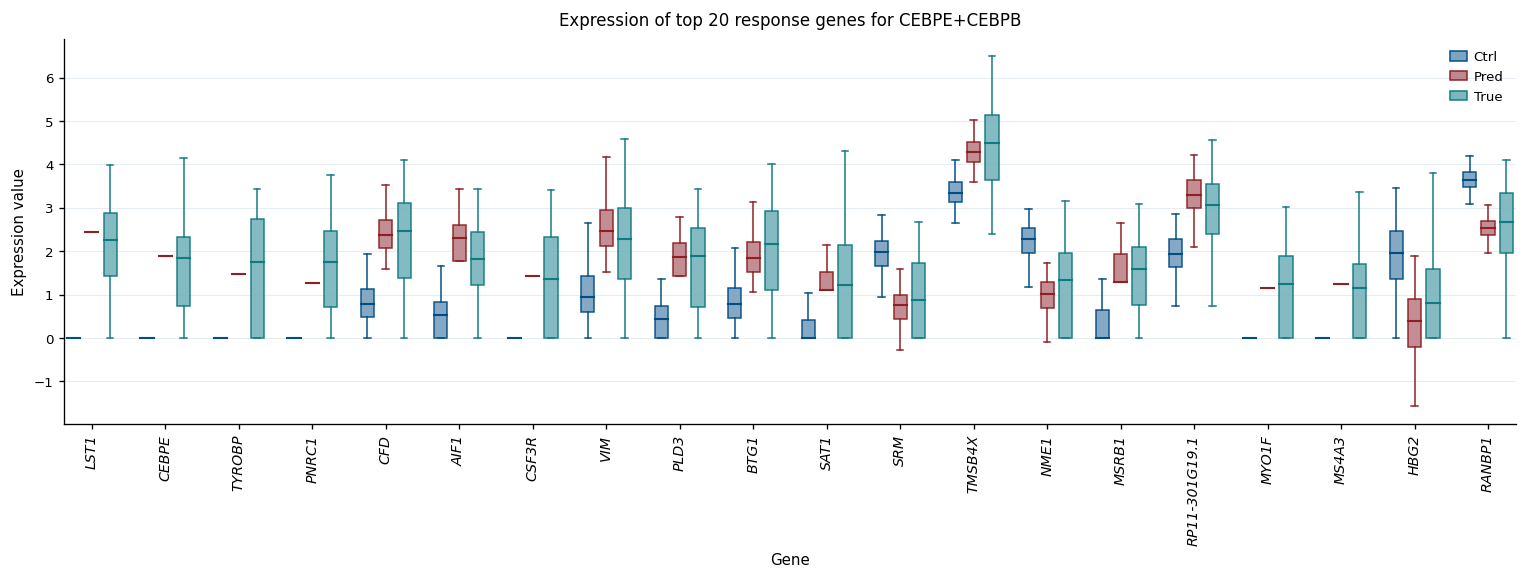

Saved:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/boxplots_per_perturbation_paper_palette/CEBPE_plus_CEBPB_top20_boxplot_paper_palette.svg
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/boxplots_per_perturbation_paper_palette/CEBPE_plus_CEBPB_top20_boxplot_paper_palette.png
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/boxplots_per_perturbation_paper_palette/CEBPE_plus_CEBPB_top20_boxplot_paper_palette.pdf


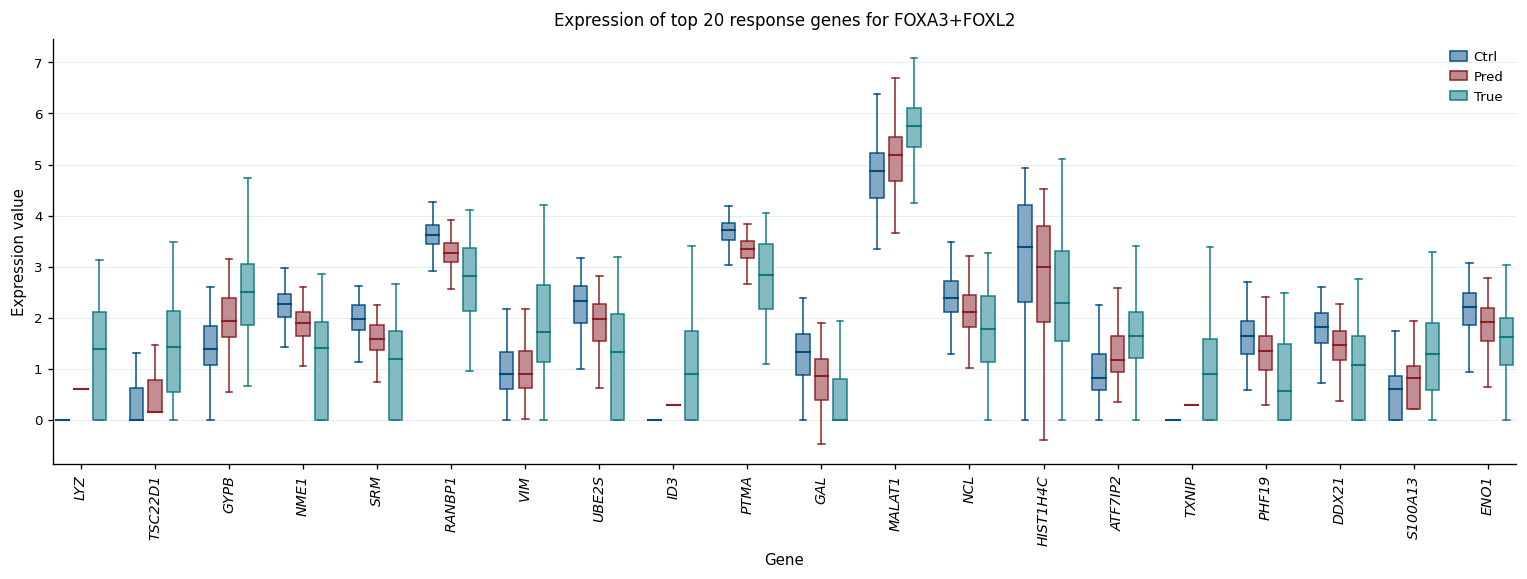

Saved:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/boxplots_per_perturbation_paper_palette/FOXA3_plus_FOXL2_top20_boxplot_paper_palette.svg
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/boxplots_per_perturbation_paper_palette/FOXA3_plus_FOXL2_top20_boxplot_paper_palette.png
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/boxplots_per_perturbation_paper_palette/FOXA3_plus_FOXL2_top20_boxplot_paper_palette.pdf
Saved summary:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/boxplots_per_perturbation_paper_palette/selected_boxplots_summary_paper_palette.csv


,perturbation,perturbation_in_npz,n_true_cells,top_genes_first10,svg_path,png_path,pdf_path
0,CEBPE+CEBPB,CEBPE+CEBPB,111,"LST1, CEBPE, TYROBP, PNRC1, CFD, AIF1, CSF3R, ...",/root/autodl-tmp/scERso/norman_combo_gears_sty...,/root/autodl-tmp/scERso/norman_combo_gears_sty...,/root/autodl-tmp/scERso/norman_combo_gears_sty...
1,FOXA3+FOXL2,FOXA3+FOXL2,113,"LYZ, TSC22D1, GYPB, NME1, SRM, RANBP1, VIM, UB...",/root/autodl-tmp/scERso/norman_combo_gears_sty...,/root/autodl-tmp/scERso/norman_combo_gears_sty...,/root/autodl-tmp/scERso/norman_combo_gears_sty...


Loading h5ad...
AnnData object with n_obs × n_vars = 91205 × 5045
    obs: 'condition', 'cell_type', 'dose_val', 'control', 'condition_name', 'perturbation_raw', 'perturbation_targets', 'n_perturb_genes', 'perturb_type', 'split', 'gears_split', 'gears_test_subgroup', 'gears_seen_type'
    var: 'gene_name'
    uns: 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'
    layers: 'counts'
Loading predictions...
condition column: condition
n control cells: 7353


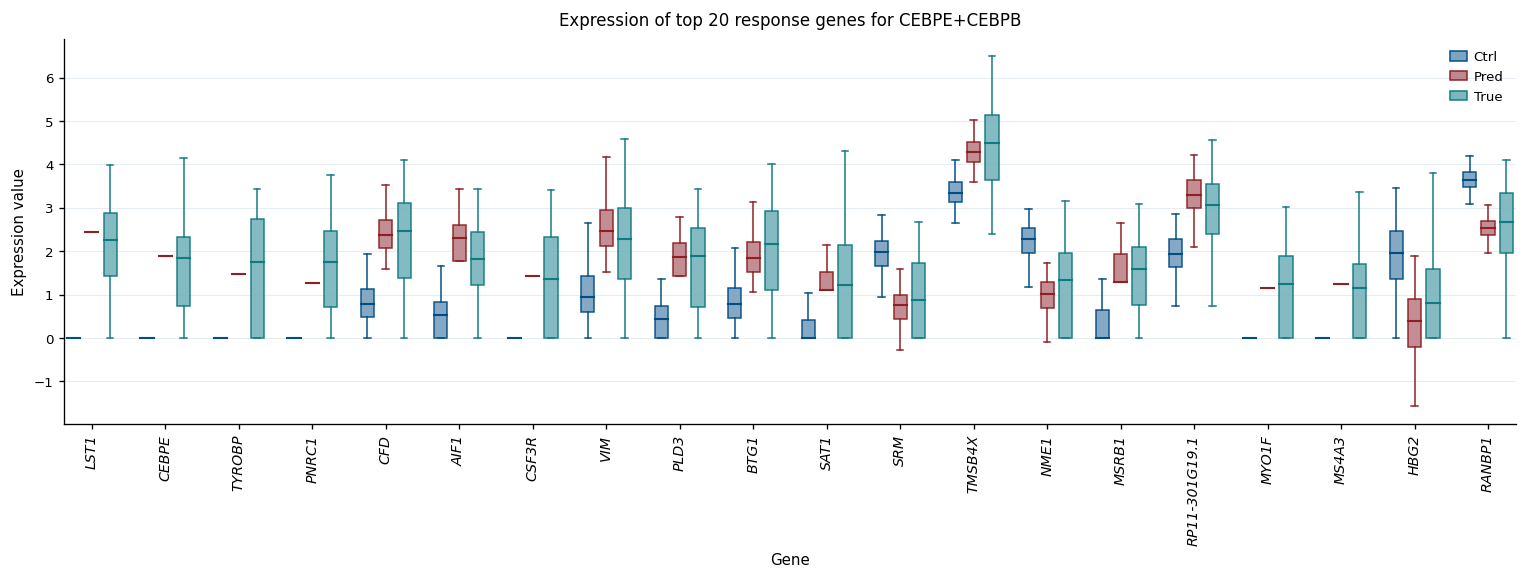

Saved:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/boxplots_per_perturbation_paper_palette/CEBPE_plus_CEBPB_top20_boxplot_paper_palette.svg
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/boxplots_per_perturbation_paper_palette/CEBPE_plus_CEBPB_top20_boxplot_paper_palette.png
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/boxplots_per_perturbation_paper_palette/CEBPE_plus_CEBPB_top20_boxplot_paper_palette.pdf


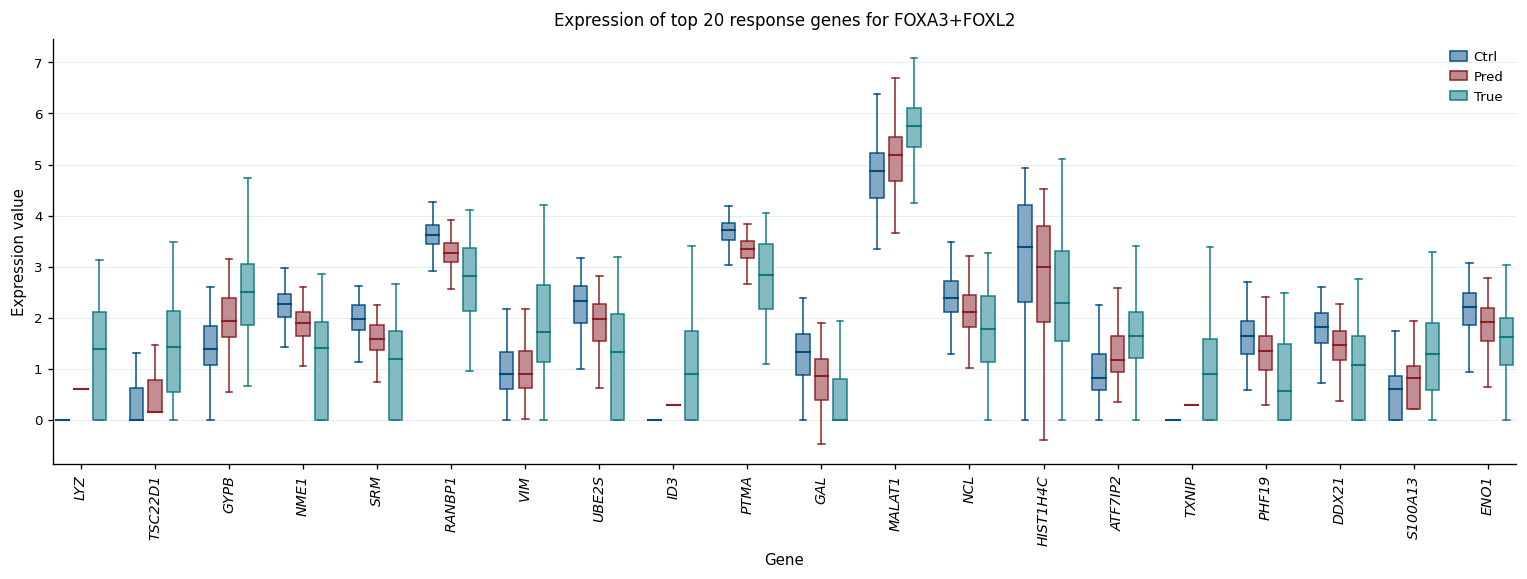

Saved:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/boxplots_per_perturbation_paper_palette/FOXA3_plus_FOXL2_top20_boxplot_paper_palette.svg
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/boxplots_per_perturbation_paper_palette/FOXA3_plus_FOXL2_top20_boxplot_paper_palette.png
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/boxplots_per_perturbation_paper_palette/FOXA3_plus_FOXL2_top20_boxplot_paper_palette.pdf
Saved summary:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/boxplots_per_perturbation_paper_palette/selected_boxplots_summary_paper_palette.csv


,perturbation,perturbation_in_npz,n_true_cells,top_genes_first10,svg_path,png_path,pdf_path
0,CEBPE+CEBPB,CEBPE+CEBPB,111,"LST1, CEBPE, TYROBP, PNRC1, CFD, AIF1, CSF3R, ...",/root/autodl-tmp/scERso/norman_combo_gears_sty...,/root/autodl-tmp/scERso/norman_combo_gears_sty...,/root/autodl-tmp/scERso/norman_combo_gears_sty...
1,FOXA3+FOXL2,FOXA3+FOXL2,113,"LYZ, TSC22D1, GYPB, NME1, SRM, RANBP1, VIM, UB...",/root/autodl-tmp/scERso/norman_combo_gears_sty...,/root/autodl-tmp/scERso/norman_combo_gears_sty...,/root/autodl-tmp/scERso/norman_combo_gears_sty...


In [3]:
# =========================================================
# Norman double-gene perturbation:
# separate boxplot figure for each representative perturbation
# Ctrl vs Pred vs True, with italic compressed gene labels
#
# Strict color palette:
# Ctrl: blue pair
# Pred: rose pair
# True: teal pair
# =========================================================

import os
import re
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from scipy import sparse
from matplotlib.patches import Patch

# -----------------------------
# paths
# -----------------------------
H5AD_PATH = "/root/autodl-tmp/scERso/norman_combo_gears_style/data/norman_gears_style_seed1_trainGeneFrac0.75.h5ad"

PRED_NPZ = "/root/autodl-tmp/scERso/norman_combo_gears_style/checkpoints/gears_style_residual_diffusion_seed1/test_predictions_gears_style_residual.npz"

OUT_DIR = "/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/boxplots_per_perturbation_paper_palette"
os.makedirs(OUT_DIR, exist_ok=True)

# -----------------------------
# choose perturbations
# -----------------------------
SELECTED_PERTS = [
    "CEBPE+CEBPB",   # seen2
    "FOXA3+FOXL2",   # seen1
]

# Modify this section to use different double-gene combinations
# SELECTED_PERTS = [
#     "CEBPE+CEBPB",
#     "CEBPE+PTPN12",
# ]

TOPK = 20
RANDOM_SEED = 42

# -----------------------------
# strict color pairs
# -----------------------------
COLOR_PAIRS = {
    "rose": {
        "dark": "#8F1F22",
        "light": "#BF888E",
    },
    "blue": {
        "dark": "#004E85",
        "light": "#7EA4C2",
    },
    "teal": {
        "dark": "#107A83",
        "light": "#7DB7BE",
    },
}

GROUP_COLORS = {
    "Ctrl": COLOR_PAIRS["blue"],
    "Pred": COLOR_PAIRS["rose"],
    "True": COLOR_PAIRS["teal"],
}

# -----------------------------
# helpers
# -----------------------------
def to_dense(x):
    if sparse.issparse(x):
        return x.toarray()
    return np.asarray(x)


def get_var_names(adata):
    if "gene_name" in adata.var.columns:
        return adata.var["gene_name"].astype(str).values
    return adata.var_names.astype(str).values


def choose_condition_col(adata):
    if "condition" in adata.obs.columns:
        return "condition"
    elif "condition_name" in adata.obs.columns:
        return "condition_name"
    else:
        raise ValueError("No condition-like column found in adata.obs")


def get_control_mask(adata, cond_col):
    if "control" in adata.obs.columns:
        ctrl_col = adata.obs["control"]

        if ctrl_col.dtype == bool:
            return ctrl_col.values

        try:
            return ctrl_col.astype(bool).values
        except Exception:
            pass

    return (adata.obs[cond_col].astype(str).values == "ctrl")


def make_pred_expr_from_ctrl(ctrl_expr, pred_delta, n_target, seed=42):
    rng = np.random.default_rng(seed)

    n_ctrl = ctrl_expr.shape[0]
    replace = n_ctrl < n_target

    idx = rng.choice(
        n_ctrl,
        size=n_target,
        replace=replace
    )

    sampled_ctrl = ctrl_expr[idx]
    pred_expr = sampled_ctrl + pred_delta[None, :]

    return sampled_ctrl, pred_expr


def safe_filename(name):
    name = str(name)
    name = name.replace("+", "_plus_")
    name = name.replace("/", "_")
    name = re.sub(r"[^A-Za-z0-9_.+-]+", "_", name)
    return name


def infer_fontsize(n_genes):
    if n_genes <= 12:
        return 10.5
    elif n_genes <= 16:
        return 9.5
    elif n_genes <= 20:
        return 8.5
    else:
        return 7.5


def style_boxplot(bp, color_pair, alpha=0.95):
    """
    Use strict color pair:
    light = box fill
    dark  = edge, median, whisker, cap
    """
    dark = color_pair["dark"]
    light = color_pair["light"]

    for box in bp["boxes"]:
        box.set_facecolor(light)
        box.set_edgecolor(dark)
        box.set_linewidth(0.9)
        box.set_alpha(alpha)

    for median in bp["medians"]:
        median.set_color(dark)
        median.set_linewidth(1.25)

    for whisker in bp["whiskers"]:
        whisker.set_color(dark)
        whisker.set_linewidth(0.9)

    for cap in bp["caps"]:
        cap.set_color(dark)
        cap.set_linewidth(0.9)


def draw_grouped_boxplots(
    ax,
    ctrl_mat,
    pred_mat,
    true_mat,
    gene_names,
    title
):
    n_genes = ctrl_mat.shape[1]

    gap = 4.0
    width = 0.72

    positions_ctrl = []
    positions_pred = []
    positions_true = []
    tick_positions = []

    for i in range(n_genes):
        base = i * gap

        positions_ctrl.append(base + 0.0)
        positions_pred.append(base + 1.0)
        positions_true.append(base + 2.0)

        tick_positions.append(base + 1.0)

    common_kwargs = dict(
        patch_artist=True,
        showfliers=False,
        widths=width,
    )

    bp_ctrl = ax.boxplot(
        [ctrl_mat[:, i] for i in range(n_genes)],
        positions=positions_ctrl,
        **common_kwargs
    )

    bp_pred = ax.boxplot(
        [pred_mat[:, i] for i in range(n_genes)],
        positions=positions_pred,
        **common_kwargs
    )

    bp_true = ax.boxplot(
        [true_mat[:, i] for i in range(n_genes)],
        positions=positions_true,
        **common_kwargs
    )

    style_boxplot(
        bp_ctrl,
        GROUP_COLORS["Ctrl"],
        alpha=0.95
    )

    style_boxplot(
        bp_pred,
        GROUP_COLORS["Pred"],
        alpha=0.95
    )

    style_boxplot(
        bp_true,
        GROUP_COLORS["True"],
        alpha=0.95
    )

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(
        gene_names,
        rotation=90,
        ha="center"
    )

    ax.set_xlabel("Gene")
    ax.set_ylabel("Expression value")

    ax.set_title(
        title,
        fontsize=10,
        fontweight="normal",
        pad=8
    )

    # Use a very light blue grid derived from the specified blue-light color
    ax.grid(
        axis="y",
        color=COLOR_PAIRS["blue"]["light"],
        alpha=0.22,
        linewidth=0.55
    )

    # Scale labels automatically and italicize gene names
    font_size = infer_fontsize(n_genes)

    for label in ax.get_xticklabels():
        label.set_fontstyle("italic")
        label.set_fontsize(font_size)

    # axis style
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        length=3,
        width=0.8
    )

    # legend
    handles = [
        Patch(
            facecolor=GROUP_COLORS["Ctrl"]["light"],
            edgecolor=GROUP_COLORS["Ctrl"]["dark"],
            linewidth=0.9,
            label="Ctrl"
        ),
        Patch(
            facecolor=GROUP_COLORS["Pred"]["light"],
            edgecolor=GROUP_COLORS["Pred"]["dark"],
            linewidth=0.9,
            label="Pred"
        ),
        Patch(
            facecolor=GROUP_COLORS["True"]["light"],
            edgecolor=GROUP_COLORS["True"]["dark"],
            linewidth=0.9,
            label="True"
        ),
    ]

    ax.legend(
        handles=handles,
        frameon=False,
        loc="upper right",
        fontsize=8,
        handlelength=1.3,
        handletextpad=0.5
    )


# -----------------------------
# load data
# -----------------------------
print("Loading h5ad...")
adata = ad.read_h5ad(H5AD_PATH)
print(adata)

print("Loading predictions...")
npz = np.load(PRED_NPZ, allow_pickle=True)

perturbation = npz["perturbation"].astype(str)
true_delta = npz["true_delta"]
corrected_delta = npz["corrected_delta"]

cond_col = choose_condition_col(adata)
var_names = get_var_names(adata)
ctrl_mask = get_control_mask(adata, cond_col)

if len(var_names) == adata.n_vars:
    adata.var_names = pd.Index(var_names)

ctrl_expr_all = to_dense(adata[ctrl_mask].X)

print("condition column:", cond_col)
print("n control cells:", int(ctrl_mask.sum()))

# -----------------------------
# plotting style
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,

    "font.size": 9,
    "axes.titlesize": 10,
    "axes.titleweight": "normal",
    "axes.labelsize": 9,

    "xtick.labelsize": 7,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -----------------------------
# generate one figure per perturbation
# -----------------------------
summary_rows = []

available_perts = set(perturbation)

for pert in SELECTED_PERTS:
    if pert not in available_perts:
        # Support condition labels that may contain suffixes
        matched = [
            p for p in perturbation
            if str(p).split("|")[0].strip() == pert
        ]

        if len(matched) == 0:
            raise ValueError(f"{pert} not found in prediction NPZ.")

        pert_in_npz = matched[0]
    else:
        pert_in_npz = pert

    pred_idx = np.where(perturbation == pert_in_npz)[0][0]

    pred_delta = corrected_delta[pred_idx]
    true_d = true_delta[pred_idx]

    # Select top genes by true-delta magnitude
    top_idx = np.argsort(np.abs(true_d))[-TOPK:]
    top_idx = top_idx[np.argsort(-np.abs(true_d[top_idx]))]

    top_gene_names = var_names[top_idx]

    # Observed perturbed cells
    cond_values = adata.obs[cond_col].astype(str).values

    pert_mask = (
        cond_values == pert
    )

    # Support suffixes in h5ad condition labels
    if int(pert_mask.sum()) == 0:
        pert_mask = np.array([
            str(x).split("|")[0].strip() == pert
            for x in cond_values
        ])

    n_true_cells = int(pert_mask.sum())

    if n_true_cells == 0:
        raise ValueError(f"No cells found in adata for perturbation {pert}")

    true_expr = to_dense(adata[pert_mask].X)

    # Pred = sampled control + predicted delta
    sampled_ctrl_expr, pred_expr = make_pred_expr_from_ctrl(
        ctrl_expr_all,
        pred_delta,
        n_target=n_true_cells,
        seed=RANDOM_SEED
    )

    ctrl_plot = sampled_ctrl_expr[:, top_idx]
    pred_plot = pred_expr[:, top_idx]
    true_plot = true_expr[:, top_idx]

    # Generate a separate figure
    fig, ax = plt.subplots(
        figsize=(12.8, 4.9)
    )

    draw_grouped_boxplots(
        ax=ax,
        ctrl_mat=ctrl_plot,
        pred_mat=pred_plot,
        true_mat=true_plot,
        gene_names=top_gene_names,
        title=f"Expression of top {TOPK} response genes for {pert}"
    )

    plt.tight_layout()

    file_stub = safe_filename(pert)

    svg_path = os.path.join(
        OUT_DIR,
        f"{file_stub}_top{TOPK}_boxplot_paper_palette.svg"
    )

    png_path = os.path.join(
        OUT_DIR,
        f"{file_stub}_top{TOPK}_boxplot_paper_palette.png"
    )

    pdf_path = os.path.join(
        OUT_DIR,
        f"{file_stub}_top{TOPK}_boxplot_paper_palette.pdf"
    )

    fig.savefig(svg_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()

    print("Saved:")
    print(svg_path)
    print(png_path)
    print(pdf_path)

    summary_rows.append({
        "perturbation": pert,
        "perturbation_in_npz": pert_in_npz,
        "n_true_cells": n_true_cells,
        "top_genes_first10": ", ".join(top_gene_names[:10]),
        "svg_path": svg_path,
        "png_path": png_path,
        "pdf_path": pdf_path,
    })

summary_df = pd.DataFrame(summary_rows)

summary_csv = os.path.join(
    OUT_DIR,
    "selected_boxplots_summary_paper_palette.csv"
)

summary_df.to_csv(summary_csv, index=False)

print("Saved summary:")
print(summary_csv)

try:
    display(summary_df)
except NameError:
    print(summary_df)

NPZ keys:
['true_delta', 'additive_delta', 'corrected_delta', 'pred_residual', 'perturbation', 'perturb_type', 'gears_test_subgroup', 'gears_seen_type', 'n_available_single', 'var_names']

Using keys:
perturbation: perturbation
true_delta: true_delta
corrected_delta: corrected_delta
seen_key: gears_seen_type

Normalized seen labels:
unknown    37
seen1      25
seen2      14
seen0       6
Name: count, dtype: int64
Saved combined SVG: /root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_latent_additive_only/ZBTB10_DLX2_seen1_CEBPE_CEBPB_seen2_latent_additive_only.svg
Saved combined PNG: /root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_latent_additive_only/ZBTB10_DLX2_seen1_CEBPE_CEBPB_seen2_latent_additive_only.png


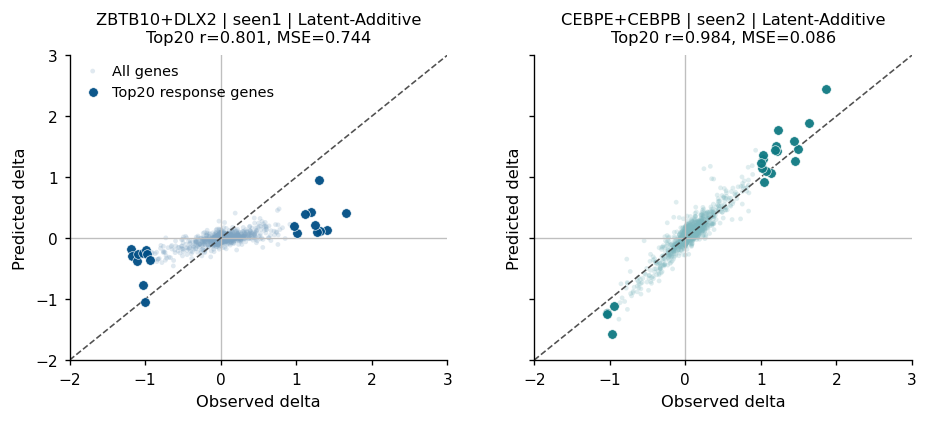

Saved single SVG: /root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_latent_additive_only/ZBTB10_plus_DLX2_seen1_latent_additive_only.svg
Saved single PNG: /root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_latent_additive_only/ZBTB10_plus_DLX2_seen1_latent_additive_only.png


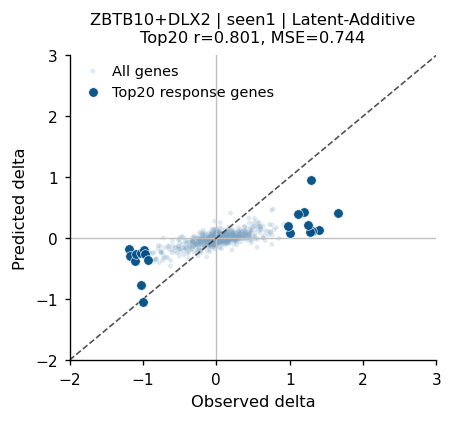

Saved single SVG: /root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_latent_additive_only/CEBPE_plus_CEBPB_seen2_latent_additive_only.svg
Saved single PNG: /root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_latent_additive_only/CEBPE_plus_CEBPB_seen2_latent_additive_only.png


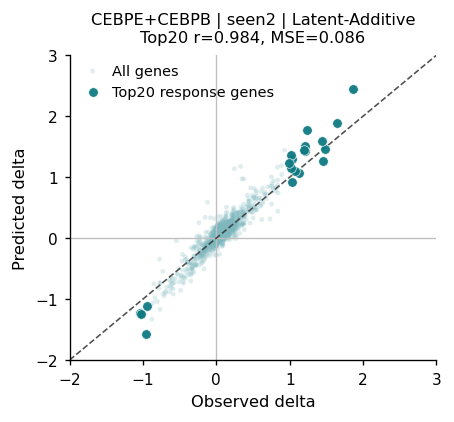


Saved summary:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_latent_additive_only/selected_latent_additive_only_summary.csv


,idx,perturbation,seen,model,color_dark,color_light,latent_additive_top20_r,latent_additive_top20_mse
0,78,ZBTB10+DLX2,seen1,Latent-Additive,#004E85,#7EA4C2,0.801446,0.743754
1,12,CEBPE+CEBPB,seen2,Latent-Additive,#107A83,#7DB7BE,0.984382,0.085927


In [1]:
# ============================================================
# Plot selected Latent-Additive cases only:
#   - ZBTB10+DLX2 | seen1
#   - CEBPE+CEBPB | seen2
#
# Output:
#   - one combined 2-panel figure
#   - two separate single-panel figures
#
# Colors unchanged:
#   seen1 -> blue
#   seen2 -> teal
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


# -----------------------------
# paths
# -----------------------------
PRED_NPZ = "/root/autodl-tmp/scERso/norman_combo_gears_style/checkpoints/gears_style_residual_diffusion_seed1/test_predictions_gears_style_residual.npz"

OUT_DIR = "/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/selected_latent_additive_only"
os.makedirs(OUT_DIR, exist_ok=True)


# -----------------------------
# parameters
# -----------------------------
TOPK = 20
MAX_BG_POINTS = 5000
RANDOM_SEED = 42

AXIS_MIN = -2
AXIS_MAX = 3


# -----------------------------
# strict color pairs
# -----------------------------
COLOR_PAIRS = {
    "seen0": {"dark": "#8F1F22", "light": "#BF888E"},  # rose
    "seen1": {"dark": "#004E85", "light": "#7EA4C2"},  # blue
    "seen2": {"dark": "#107A83", "light": "#7DB7BE"},  # teal
}


# -----------------------------
# target cases
# -----------------------------
TARGET_CASES = [
    {"perturbation": "ZBTB10+DLX2", "seen": "seen1"},
    {"perturbation": "CEBPE+CEBPB", "seen": "seen2"},
]


# -----------------------------
# helpers
# -----------------------------
def find_key(npz, candidates, name):
    keys = list(npz.files)
    for k in candidates:
        if k in keys:
            return k
    raise KeyError(
        f"Cannot find {name}. Tried {candidates}. Available keys are:\n{keys}"
    )


def find_optional_key(npz, candidates):
    keys = list(npz.files)
    for k in candidates:
        if k in keys:
            return k
    return None


def safe_pearson(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    if len(x) < 2:
        return np.nan

    if np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return 0.0

    return float(pearsonr(x, y)[0])


def mse(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    return float(np.mean((x - y) ** 2))


def safe_filename(name):
    return re.sub(r"[^A-Za-z0-9_.+-]+", "_", str(name)).replace("+", "_plus_")


def clean_pert_name(pert_name):
    return str(pert_name).split("|")[0].strip()


def normalize_seen_label(x):
    """
    Normalize labels such as:
    seen0, seen1, seen2
    combo_seen0, combo_seen1, combo_seen2
    seen_0, seen-1
    """
    x = str(x)
    m = re.search(r"seen[_-]?([0-2])", x)
    if m:
        return f"seen{m.group(1)}"
    return "unknown"


def get_top_idx(obs, topk=20):
    obs = np.asarray(obs).astype(float)
    top_idx = np.argsort(np.abs(obs))[-topk:]
    top_idx = top_idx[np.argsort(-np.abs(obs[top_idx]))]
    return top_idx


def plot_latent_additive_panel(
    ax,
    obs,
    pred,
    top_idx,
    pert,
    seen,
    colors,
    bg_idx=None,
    show_legend=False
):
    """
    colors = {"dark": ..., "light": ...}
    strict usage:
      - all genes -> light
      - top20 genes -> dark
    """
    if bg_idx is None:
        bg_idx = np.arange(len(obs))

    top_r = safe_pearson(obs[top_idx], pred[top_idx])
    top_mse = mse(obs[top_idx], pred[top_idx])

    # all genes
    ax.scatter(
        obs[bg_idx],
        pred[bg_idx],
        s=7,
        alpha=0.24,
        color=colors["light"],
        edgecolors="none",
        label="All genes",
        rasterized=True
    )

    # top20 response genes
    ax.scatter(
        obs[top_idx],
        pred[top_idx],
        s=28,
        alpha=0.95,
        color=colors["dark"],
        edgecolors="white",
        linewidths=0.35,
        label="Top20 response genes",
        zorder=5
    )

    # zero lines
    ax.axhline(0, color="0.75", linewidth=0.75, zorder=1)
    ax.axvline(0, color="0.75", linewidth=0.75, zorder=1)

    # diagonal
    ax.plot(
        [AXIS_MIN, AXIS_MAX],
        [AXIS_MIN, AXIS_MAX],
        linestyle="--",
        color="0.20",
        linewidth=0.9,
        alpha=0.85,
        zorder=2
    )

    ax.set_xlim(AXIS_MIN, AXIS_MAX)
    ax.set_ylim(AXIS_MIN, AXIS_MAX)
    ax.set_xticks(np.arange(AXIS_MIN, AXIS_MAX + 1, 1))
    ax.set_yticks(np.arange(AXIS_MIN, AXIS_MAX + 1, 1))

    ax.set_title(
        f"{pert} | {seen} | Latent-Additive\nTop20 r={top_r:.3f}, MSE={top_mse:.3f}",
        fontsize=9,
        fontweight="normal",
        pad=7
    )

    ax.set_xlabel("Observed delta", fontsize=9)
    ax.set_ylabel("Predicted delta", fontsize=9)

    ax.tick_params(axis="both", labelsize=8.5, length=3, width=0.75)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.75)
    ax.spines["bottom"].set_linewidth(0.75)

    if show_legend:
        ax.legend(
            frameon=False,
            loc="upper left",
            fontsize=8,
            handletextpad=0.35,
            borderaxespad=0.2
        )

    return {
        "top20_r": top_r,
        "top20_mse": top_mse
    }


# -----------------------------
# plotting style
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 600,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 8.5,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "axes.titleweight": "normal",
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 8,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

rng = np.random.default_rng(RANDOM_SEED)


# -----------------------------
# load npz
# -----------------------------
npz = np.load(PRED_NPZ, allow_pickle=True)

print("NPZ keys:")
print(npz.files)

pert_key = find_key(
    npz,
    ["perturbation", "perturbations", "condition", "conditions"],
    "perturbation names"
)

true_key = find_key(
    npz,
    ["true_delta", "obs_delta", "observed_delta", "y_delta", "delta_true"],
    "true delta"
)

corr_key = find_key(
    npz,
    [
        "corrected_delta",
        "residual_corrected_delta",
        "pred_delta_corrected",
        "non_additive_delta",
        "nonadditive_delta",
        "final_delta"
    ],
    "latent-additive / corrected delta"
)

seen_key = find_optional_key(
    npz,
    [
        "gears_seen_type",
        "gears_test_subgroup",
        "seen",
        "split",
        "group",
        "seen_group",
        "perturbation_group",
        "perturb_type"
    ]
)

if seen_key is None:
    raise ValueError(
        "Cannot find seen group key. "
        "Expected one of: gears_seen_type / gears_test_subgroup / seen ..."
    )

perturbations = np.asarray(npz[pert_key]).astype(str)
true_delta = np.asarray(npz[true_key])
corrected_delta = np.asarray(npz[corr_key])

raw_seen_labels = np.asarray(npz[seen_key]).astype(str)
seen_labels = np.array([normalize_seen_label(x) for x in raw_seen_labels])
pert_clean_names = np.array([clean_pert_name(x) for x in perturbations])

print("\nUsing keys:")
print("perturbation:", pert_key)
print("true_delta:", true_key)
print("corrected_delta:", corr_key)
print("seen_key:", seen_key)

print("\nNormalized seen labels:")
print(pd.Series(seen_labels).value_counts())


# -----------------------------
# collect selected cases
# -----------------------------
selected_cases = []

for case in TARGET_CASES:
    target_pert = case["perturbation"]
    target_seen = case["seen"]

    hit_idx = np.where(
        (pert_clean_names == target_pert) &
        (seen_labels == target_seen)
    )[0]

    if len(hit_idx) == 0:
        raise ValueError(
            f"Cannot find target case: {target_pert} | {target_seen}\n"
            f"Available matched perturbations include:\n"
            f"{pd.DataFrame({'perturbation': pert_clean_names, 'seen': seen_labels}).drop_duplicates().to_string(index=False)}"
        )

    if len(hit_idx) > 1:
        print(f"Warning: multiple matches found for {target_pert} | {target_seen}, using the first one.")

    idx = int(hit_idx[0])

    obs = true_delta[idx].astype(float)
    pred = corrected_delta[idx].astype(float)

    valid = np.isfinite(obs) & np.isfinite(pred)
    obs = obs[valid]
    pred = pred[valid]

    top_idx = get_top_idx(obs, topk=TOPK)

    all_idx = np.arange(len(obs))
    if len(all_idx) > MAX_BG_POINTS:
        bg_idx = rng.choice(all_idx, size=MAX_BG_POINTS, replace=False)
    else:
        bg_idx = all_idx

    selected_cases.append({
        "idx": idx,
        "perturbation": target_pert,
        "seen": target_seen,
        "obs": obs,
        "pred": pred,
        "top_idx": top_idx,
        "bg_idx": bg_idx,
        "colors": COLOR_PAIRS[target_seen]
    })


# -----------------------------
# plot combined 2-panel figure
# -----------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(7.2, 3.35),
    sharex=True,
    sharey=True
)

summary_rows = []

for i, case in enumerate(selected_cases):
    res = plot_latent_additive_panel(
        ax=axes[i],
        obs=case["obs"],
        pred=case["pred"],
        top_idx=case["top_idx"],
        pert=case["perturbation"],
        seen=case["seen"],
        colors=case["colors"],
        bg_idx=case["bg_idx"],
        show_legend=(i == 0)
    )

    summary_rows.append({
        "idx": case["idx"],
        "perturbation": case["perturbation"],
        "seen": case["seen"],
        "model": "Latent-Additive",
        "color_dark": case["colors"]["dark"],
        "color_light": case["colors"]["light"],
        "latent_additive_top20_r": res["top20_r"],
        "latent_additive_top20_mse": res["top20_mse"]
    })

fig.subplots_adjust(
    left=0.085,
    right=0.985,
    bottom=0.17,
    top=0.87,
    wspace=0.23
)

combined_svg = os.path.join(
    OUT_DIR,
    "ZBTB10_DLX2_seen1_CEBPE_CEBPB_seen2_latent_additive_only.svg"
)

combined_png = os.path.join(
    OUT_DIR,
    "ZBTB10_DLX2_seen1_CEBPE_CEBPB_seen2_latent_additive_only.png"
)

fig.savefig(combined_svg, bbox_inches="tight")
fig.savefig(combined_png, bbox_inches="tight")

print("Saved combined SVG:", combined_svg)
print("Saved combined PNG:", combined_png)

plt.show()


# -----------------------------
# plot two separate single-panel figures
# -----------------------------
for case in selected_cases:
    fig, ax = plt.subplots(
        1, 1,
        figsize=(3.55, 3.35)
    )

    res = plot_latent_additive_panel(
        ax=ax,
        obs=case["obs"],
        pred=case["pred"],
        top_idx=case["top_idx"],
        pert=case["perturbation"],
        seen=case["seen"],
        colors=case["colors"],
        bg_idx=case["bg_idx"],
        show_legend=True
    )

    fig.subplots_adjust(
        left=0.19,
        right=0.985,
        bottom=0.17,
        top=0.87
    )

    base_name = f"{safe_filename(case['perturbation'])}_{case['seen']}_latent_additive_only"

    out_svg = os.path.join(OUT_DIR, f"{base_name}.svg")
    out_png = os.path.join(OUT_DIR, f"{base_name}.png")

    fig.savefig(out_svg, bbox_inches="tight")
    fig.savefig(out_png, bbox_inches="tight")

    print("Saved single SVG:", out_svg)
    print("Saved single PNG:", out_png)

    plt.show()


# -----------------------------
# save summary
# -----------------------------
summary_df = pd.DataFrame(summary_rows)

summary_csv = os.path.join(
    OUT_DIR,
    "selected_latent_additive_only_summary.csv"
)

summary_df.to_csv(summary_csv, index=False)

print("\nSaved summary:")
print(summary_csv)

try:
    display(summary_df)
except NameError:
    print(summary_df)

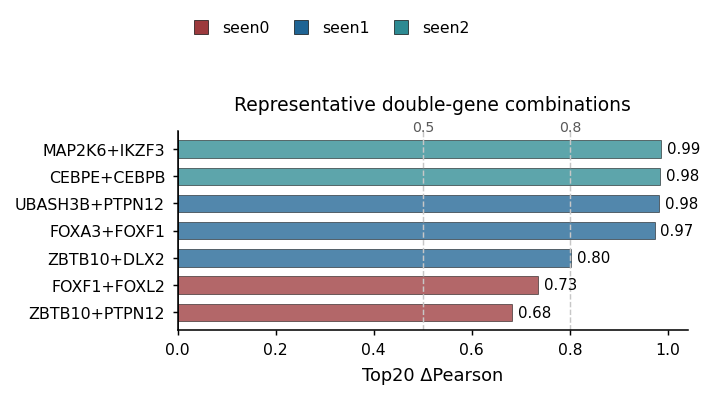

Saved:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figB_top20_delta_pearson_representative_combos_compact.svg
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figB_top20_delta_pearson_representative_combos_compact.png
Saved table:
/root/autodl-tmp/scERso/norman_combo_gears_style/figures/gears_style_residual_diffusion_seed1/figB_top20_delta_pearson_representative_combos_compact.csv


,perturbation,subgroup,corr_top20_delta_pearson,corr_top20_delta_mse,corr_opposite_direction,add_top20_delta_pearson,improve_top20_pearson,improve_top20_mse
6,MAP2K6+IKZF3,combo_seen2,0.985087,0.028488,0.00,0.985126,-0.000039,0.001877
5,CEBPE+CEBPB,combo_seen2,0.984382,0.085927,0.00,0.978896,0.005486,0.077529
4,UBASH3B+PTPN12,combo_seen1,0.981873,0.390925,0.00,0.970707,0.011166,0.022897
3,FOXA3+FOXF1,combo_seen1,0.972617,0.035677,0.00,0.969452,0.003165,0.013873
2,ZBTB10+DLX2,combo_seen1,0.801446,0.743754,0.00,0.751501,0.049945,0.069920
1,FOXF1+FOXL2,combo_seen0,0.734885,0.485793,0.15,0.000000,0.734885,0.034090
0,ZBTB10+PTPN12,combo_seen0,0.681105,0.463197,0.20,0.000000,0.681105,0.030251


In [5]:
# =========================================================
# Compact Figure B (revised again)
# Fix overlap between title and reference labels
# Reduce bar opacity slightly
# Overwrite existing output paths
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# paths
# -----------------------------
BASE = "/root/autodl-tmp/scERso/norman_combo_gears_style"
OUT_DIR = f"{BASE}/figures/gears_style_residual_diffusion_seed1"
os.makedirs(OUT_DIR, exist_ok=True)

COMBO_METRICS_CSV = f"{OUT_DIR}/figB_per_combo_improvement_metrics.csv"
combo_metrics = pd.read_csv(COMBO_METRICS_CSV)


# -----------------------------
# keep double-gene combinations only
# -----------------------------
combo_metrics = combo_metrics[
    combo_metrics["subgroup"].isin(["combo_seen0", "combo_seen1", "combo_seen2"])
].copy()


# -----------------------------
# strict color pairs
# -----------------------------
COLOR_PAIRS = {
    "rose": {
        "dark": "#8F1F22",
        "light": "#BF888E",
    },
    "blue": {
        "dark": "#004E85",
        "light": "#7EA4C2",
    },
    "teal": {
        "dark": "#107A83",
        "light": "#7DB7BE",
    },
}

GROUP_COLORS = {
    "combo_seen0": COLOR_PAIRS["rose"]["dark"],
    "combo_seen1": COLOR_PAIRS["blue"]["dark"],
    "combo_seen2": COLOR_PAIRS["teal"]["dark"],
}

GROUP_LABELS = {
    "combo_seen0": "seen0",
    "combo_seen1": "seen1",
    "combo_seen2": "seen2",
}

GROUP_ORDER = {
    "combo_seen0": 0,
    "combo_seen1": 1,
    "combo_seen2": 2,
}


# -----------------------------
# plot style
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 7.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})


# ---------------------------------------------------------
# choose representative combinations
# ---------------------------------------------------------
N_PER_GROUP = 2

top_by_group = (
    combo_metrics
    .sort_values("corr_top20_delta_pearson", ascending=False)
    .groupby("subgroup", group_keys=False)
    .head(N_PER_GROUP)
    .copy()
)

FORCE_INCLUDE = [
    "ZBTB10+DLX2",
    "CEBPE+CEBPB",
]

force_df = combo_metrics[
    combo_metrics["perturbation"].isin(FORCE_INCLUDE)
].copy()

plot_df = (
    pd.concat([top_by_group, force_df], axis=0)
    .drop_duplicates("perturbation")
    .copy()
)

plot_df["group_order"] = plot_df["subgroup"].map(GROUP_ORDER)

plot_df = (
    plot_df
    .sort_values(
        ["group_order", "corr_top20_delta_pearson"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)

plot_df["label"] = plot_df["perturbation"]


# ---------------------------------------------------------
# plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(5.0, 2.6))

y = np.arange(len(plot_df))
values = plot_df["corr_top20_delta_pearson"].values
colors = [GROUP_COLORS[g] for g in plot_df["subgroup"]]

# Use moderate transparency for the bars
ax.barh(
    y,
    values,
    color=colors,
    alpha=0.68,              # Apply moderate transparency
    edgecolor="black",
    linewidth=0.35,
    height=0.64,
)

# reference lines
ax.axvline(0, color="black", linewidth=0.75)
ax.axvline(0.5, color="0.78", linewidth=0.7, linestyle="--")
ax.axvline(0.8, color="0.78", linewidth=0.7, linestyle="--")

# Place the 0.5 and 0.8 reference labels inside the upper plotting area
ax.text(
    0.5, 0.985, "0.5",
    transform=ax.get_xaxis_transform(),   # Use data coordinates for x and axes coordinates for y
    ha="center",
    va="bottom",
    fontsize=6.8,
    color="0.35",
)

ax.text(
    0.8, 0.985, "0.8",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="bottom",
    fontsize=6.8,
    color="0.35",
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["label"], fontsize=7.6)

ax.set_xlim(0, 1.04)
ax.set_xlabel("Top20 ΔPearson", fontsize=8.5)

# Increase the title padding
ax.set_title("Representative double-gene combinations", fontsize=9, pad=10)

# Value labels
for i, value in enumerate(values):
    ax.text(
        value + 0.012,
        i,
        f"{value:.2f}",
        va="center",
        ha="left",
        fontsize=7.2,
        color="black",
    )

# axis style
ax.tick_params(axis="both", length=2.5, width=0.7)
ax.spines["left"].set_linewidth(0.75)
ax.spines["bottom"].set_linewidth(0.75)

# legend on top
handles = [
    plt.Line2D(
        [0], [0],
        marker="s",
        linestyle="",
        markerfacecolor=GROUP_COLORS[g],
        markeredgecolor="black",
        markeredgewidth=0.35,
        alpha=0.88,          # Match the legend transparency to the bars
        label=GROUP_LABELS[g],
        markersize=6.5,
    )
    for g in ["combo_seen0", "combo_seen1", "combo_seen2"]
]

fig.legend(
    handles=handles,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=3,
    handletextpad=0.35,
    columnspacing=1.0,
    borderaxespad=0.0,
)

plt.subplots_adjust(
    left=0.30,
    right=0.98,
    top=0.73,
    bottom=0.22,
)

# ---------------------------------------------------------
# save (overwrite existing paths)
# ---------------------------------------------------------
svg_path = os.path.join(
    OUT_DIR,
    "figB_top20_delta_pearson_representative_combos_compact.svg"
)

png_path = os.path.join(
    OUT_DIR,
    "figB_top20_delta_pearson_representative_combos_compact.png"
)

fig.savefig(svg_path, bbox_inches="tight")
fig.savefig(png_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(svg_path)
print(png_path)


# ---------------------------------------------------------
# save table
# ---------------------------------------------------------
table_path = os.path.join(
    OUT_DIR,
    "figB_top20_delta_pearson_representative_combos_compact.csv"
)

save_cols = [
    "perturbation",
    "subgroup",
    "corr_top20_delta_pearson",
    "corr_top20_delta_mse",
    "corr_opposite_direction",
    "add_top20_delta_pearson",
    "improve_top20_pearson",
    "improve_top20_mse",
]

existing_cols = [c for c in save_cols if c in plot_df.columns]

plot_df[existing_cols].sort_values(
    "corr_top20_delta_pearson",
    ascending=False
).to_csv(table_path, index=False)

print("Saved table:")
print(table_path)

try:
    display(
        plot_df[existing_cols].sort_values(
            "corr_top20_delta_pearson",
            ascending=False
        )
    )
except NameError:
    print(
        plot_df[existing_cols].sort_values(
            "corr_top20_delta_pearson",
            ascending=False
        )
    )